In [1]:
!pip install networkx

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import folium
from folium.plugins import HeatMap, MarkerCluster
import matplotlib.colors as mcolors
from matplotlib.cm import get_cmap
import contextily as ctx
from shapely.geometry import Point, LineString
import geopandas as gpd
from sklearn.cluster import DBSCAN
import networkx as nx

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

gdf = gpd.read_parquet("wynik_caly.parquet")

gdf['Czas wyjazdu ZRM'] = pd.to_datetime(gdf['Czas wyjazdu ZRM'])
gdf['Czas powrotu ZRM'] = pd.to_datetime(gdf['Czas powrotu ZRM'])

gdf['Czas trwania (min)'] = (gdf['Czas powrotu ZRM'] - gdf['Czas wyjazdu ZRM']).dt.total_seconds() / 60

gdf['Godzina wyjazdu'] = gdf['Czas wyjazdu ZRM'].dt.hour
gdf['Dzień tygodnia'] = gdf['Czas wyjazdu ZRM'].dt.dayofweek
gdf['Miesiąc'] = gdf['Czas wyjazdu ZRM'].dt.month
gdf['Dzień miesiąca'] = gdf['Czas wyjazdu ZRM'].dt.day

day_names = {0: 'Poniedziałek', 1: 'Wtorek', 2: 'Środa', 3: 'Czwartek', 
             4: 'Piątek', 5: 'Sobota', 6: 'Niedziela'}
gdf['Dzień tygodnia nazwa'] = gdf['Dzień tygodnia'].map(day_names)

month_names = {1: 'Styczeń', 2: 'Luty', 3: 'Marzec', 4: 'Kwiecień', 
               5: 'Maj', 6: 'Czerwiec', 7: 'Lipiec', 8: 'Sierpień',
               9: 'Wrzesień', 10: 'Październik', 11: 'Listopad', 12: 'Grudzień'}
gdf['Miesiąc nazwa'] = gdf['Miesiąc'].map(month_names)

gdf['Długość trasy (km)'] = gdf.geometry.length * 111

/tmp/ipykernel_123017/4083580825.py:25: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['Długość trasy (km)'] = gdf.geometry.length * 111


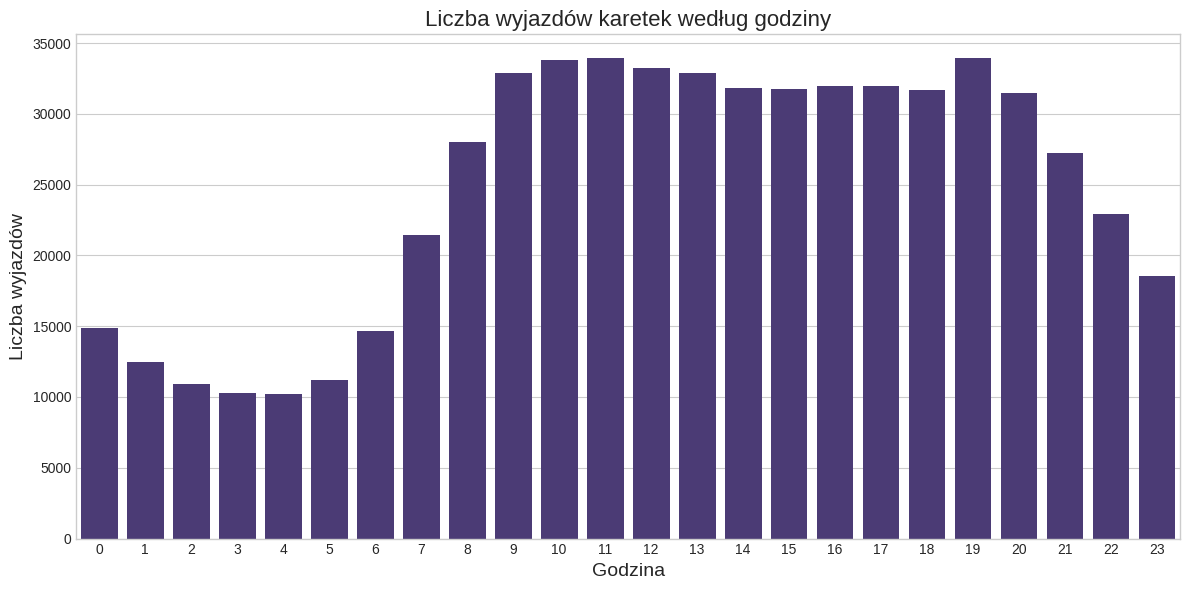

In [4]:
plt.figure(figsize=(12, 6))
hour_counts = gdf['Godzina wyjazdu'].value_counts().sort_index()
sns.barplot(x=hour_counts.index, y=hour_counts.values)
plt.title('Liczba wyjazdów karetek według godziny', fontsize=16)
plt.xlabel('Godzina', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.xticks(np.arange(0, 24))
plt.tight_layout()
plt.show()

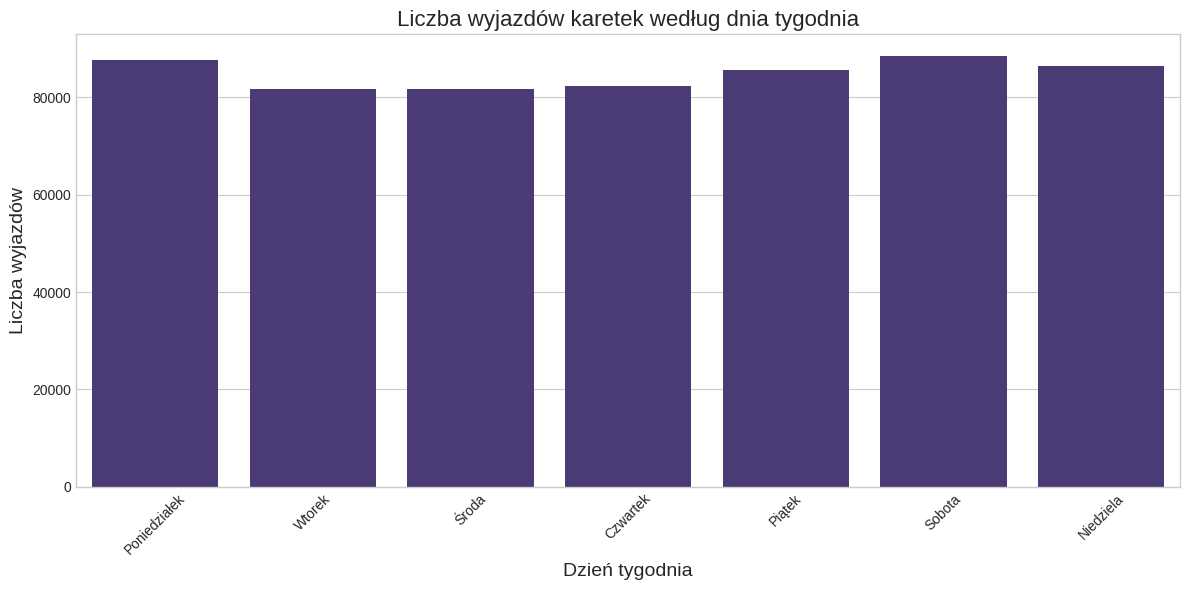

In [5]:
plt.figure(figsize=(12, 6))
day_counts = gdf['Dzień tygodnia nazwa'].value_counts().reindex(
    ['Poniedziałek', 'Wtorek', 'Środa', 'Czwartek', 'Piątek', 'Sobota', 'Niedziela'])
sns.barplot(x=day_counts.index, y=day_counts.values)
plt.title('Liczba wyjazdów karetek według dnia tygodnia', fontsize=16)
plt.xlabel('Dzień tygodnia', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

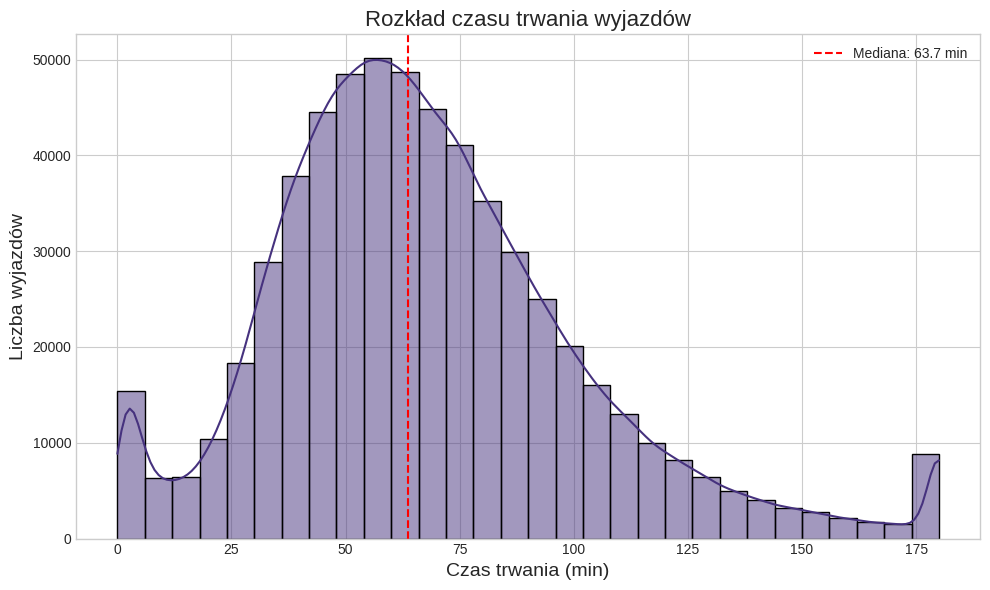

In [6]:
plt.figure(figsize=(10, 6))
sns.histplot(gdf['Czas trwania (min)'].clip(upper=180), bins=30, kde=True)
plt.axvline(gdf['Czas trwania (min)'].median(), color='red', linestyle='--', 
            label=f'Mediana: {gdf["Czas trwania (min)"].median():.1f} min')
plt.title('Rozkład czasu trwania wyjazdów', fontsize=16)
plt.xlabel('Czas trwania (min)', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

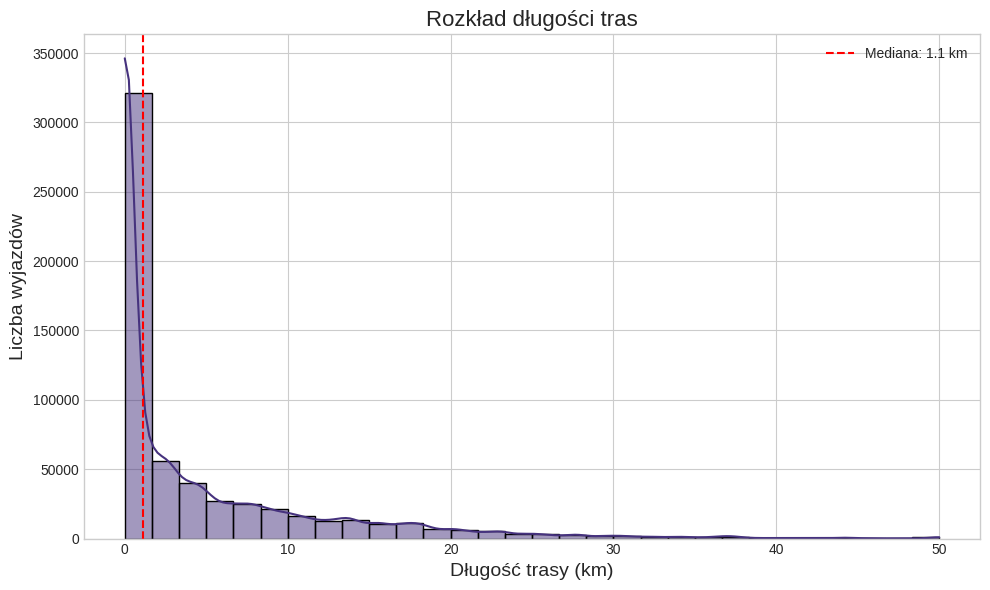

In [7]:
plt.figure(figsize=(10, 6))
sns.histplot(gdf['Długość trasy (km)'].clip(upper=50), bins=30, kde=True)
plt.axvline(gdf['Długość trasy (km)'].median(), color='red', linestyle='--', 
            label=f'Mediana: {gdf["Długość trasy (km)"].median():.1f} km')
plt.title('Rozkład długości tras', fontsize=16)
plt.xlabel('Długość trasy (km)', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

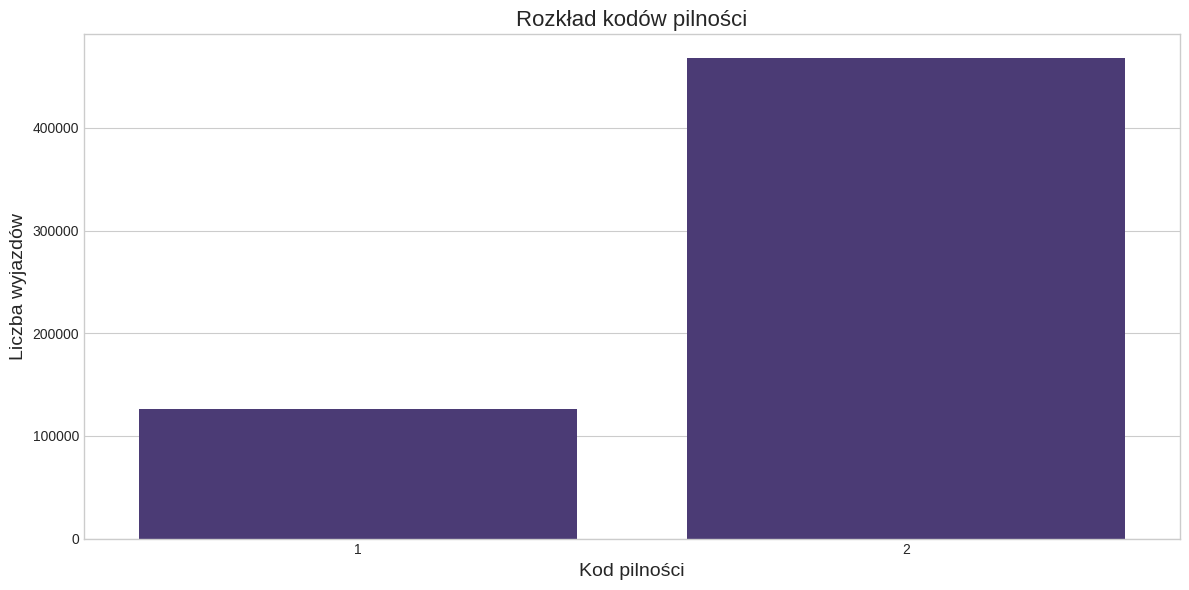

In [8]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Kod pilności', data=gdf)
plt.title('Rozkład kodów pilności', fontsize=16)
plt.xlabel('Kod pilności', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.tight_layout()
plt.show()

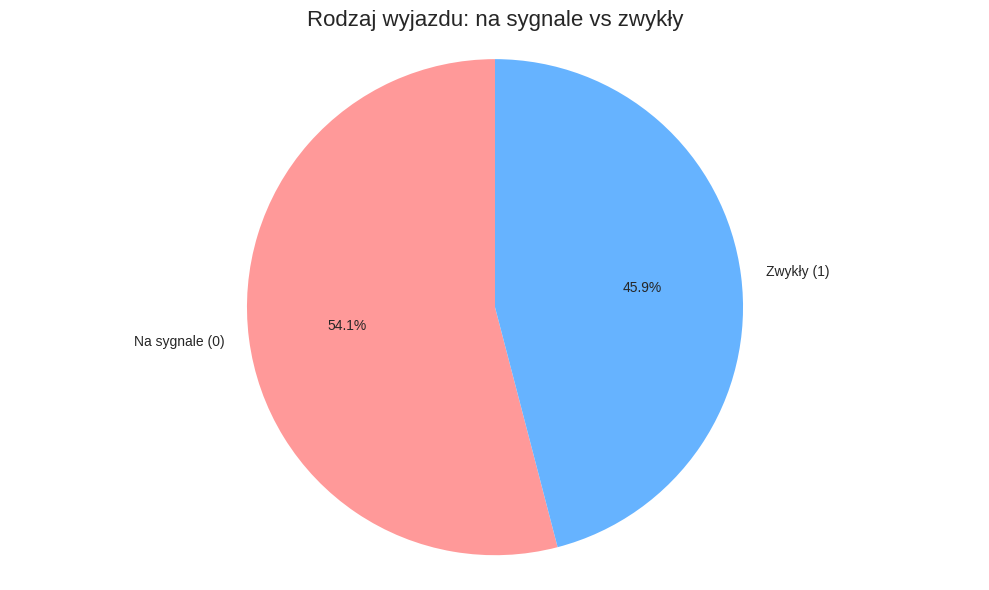

In [9]:
plt.figure(figsize=(10, 6))
trip_type_counts = gdf['Rodzaj wyjazdu'].value_counts()
labels = ['Na sygnale (0)', 'Zwykły (1)']
plt.pie(trip_type_counts, labels=labels, autopct='%1.1f%%', startangle=90, 
        colors=['#ff9999','#66b3ff'])
plt.axis('equal')
plt.title('Rodzaj wyjazdu: na sygnale vs zwykły', fontsize=16)
plt.tight_layout()
plt.show()

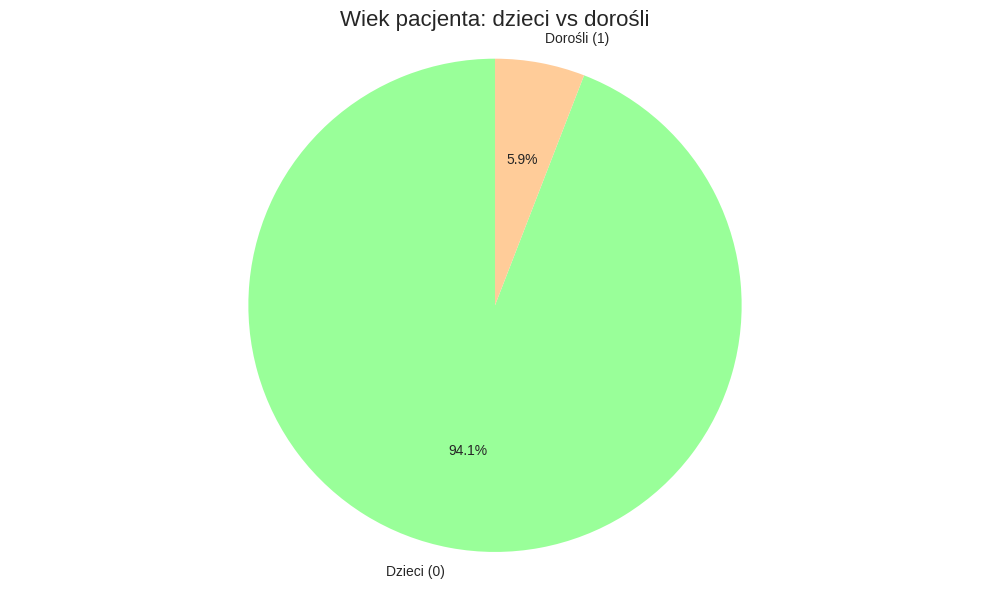

In [10]:
plt.figure(figsize=(10, 6))
age_counts = gdf['Określenie wieku pacjenta'].value_counts()
labels = ['Dzieci (0)', 'Dorośli (1)']
plt.pie(age_counts, labels=labels, autopct='%1.1f%%', startangle=90, 
        colors=['#99ff99','#ffcc99'])
plt.axis('equal')
plt.title('Wiek pacjenta: dzieci vs dorośli', fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
start_points = gdf.geometry.apply(lambda x: Point(x.coords[0]))
start_points_gdf = gpd.GeoDataFrame(gdf[['wyjazd_id', 'Powód wezwania', 'Kod pilności']], 
                                    geometry=start_points, crs=gdf.crs)

center_lat = start_points_gdf.geometry.y.mean()
center_lon = start_points_gdf.geometry.x.mean()

m = folium.Map(location=[center_lat, center_lon], zoom_start=12)

heat_data = [[point.y, point.x] for point in start_points_gdf.geometry]
HeatMap(heat_data).add_to(m)

m.save('heatmap_wyjazdy.html')
print("Zapisano mapę cieplną do pliku heatmap_wyjazdy.html")

Zapisano mapę cieplną do pliku heatmap_wyjazdy.html


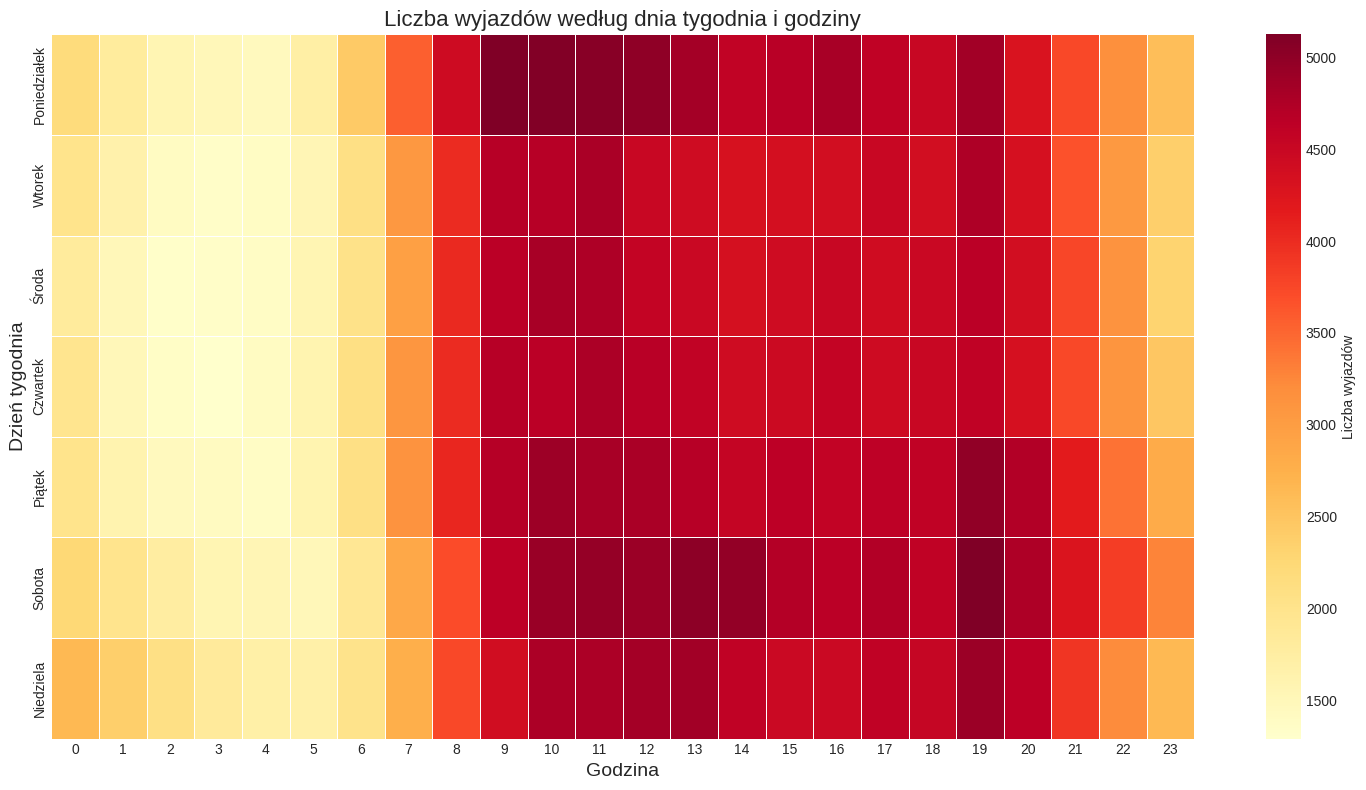

In [12]:
plt.figure(figsize=(15, 8))
hour_day_pivot = pd.crosstab(index=gdf['Dzień tygodnia nazwa'], 
                             columns=gdf['Godzina wyjazdu'])

hour_day_pivot = hour_day_pivot.reindex(['Poniedziałek', 'Wtorek', 'Środa', 'Czwartek', 
                                         'Piątek', 'Sobota', 'Niedziela'])

sns.heatmap(hour_day_pivot, cmap="YlOrRd", linewidths=.5, annot=False, fmt='d', cbar_kws={'label': 'Liczba wyjazdów'})
plt.title('Liczba wyjazdów według dnia tygodnia i godziny', fontsize=16)
plt.xlabel('Godzina', fontsize=14)
plt.ylabel('Dzień tygodnia', fontsize=14)
plt.tight_layout()
plt.show()

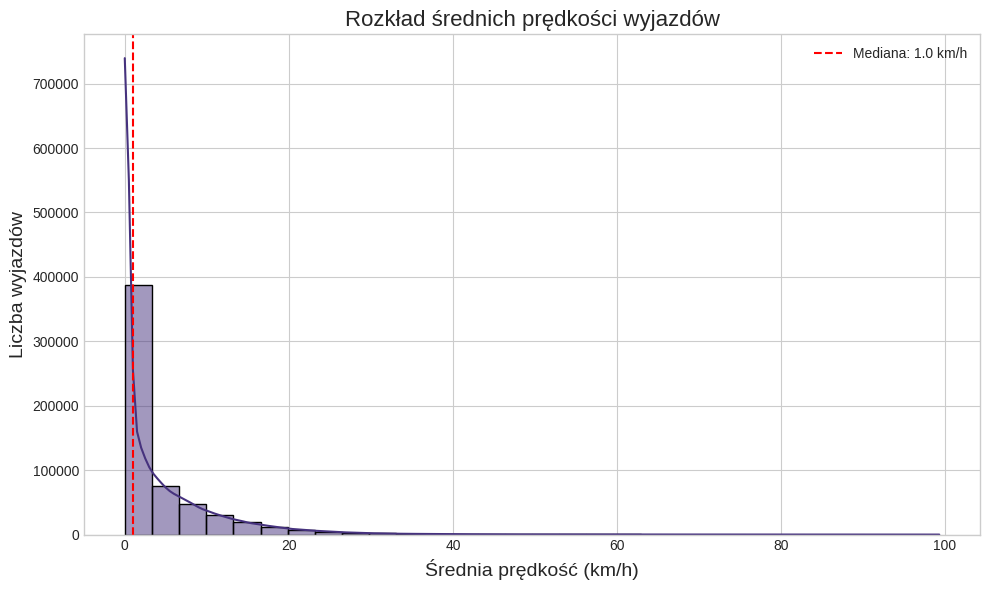

In [13]:
gdf['Średnia prędkość (km/h)'] = gdf['Długość trasy (km)'] / (gdf['Czas trwania (min)']/60)

gdf_speed = gdf[gdf['Średnia prędkość (km/h)'] < 100]

plt.figure(figsize=(10, 6))
sns.histplot(gdf_speed['Średnia prędkość (km/h)'], bins=30, kde=True)
plt.axvline(gdf_speed['Średnia prędkość (km/h)'].median(), color='red', linestyle='--', 
            label=f'Mediana: {gdf_speed["Średnia prędkość (km/h)"].median():.1f} km/h')
plt.title('Rozkład średnich prędkości wyjazdów', fontsize=16)
plt.xlabel('Średnia prędkość (km/h)', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

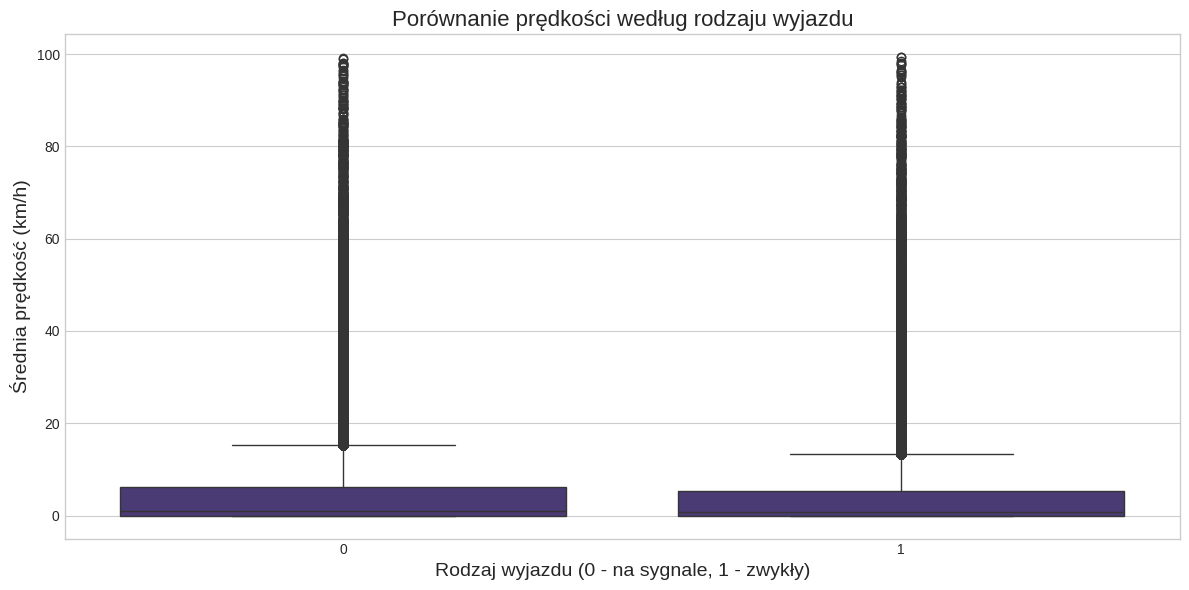

In [14]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Rodzaj wyjazdu', y='Średnia prędkość (km/h)', data=gdf_speed)
plt.title('Porównanie prędkości według rodzaju wyjazdu', fontsize=16)
plt.xlabel('Rodzaj wyjazdu (0 - na sygnale, 1 - zwykły)', fontsize=14)
plt.ylabel('Średnia prędkość (km/h)', fontsize=14)
plt.tight_layout()
plt.show()

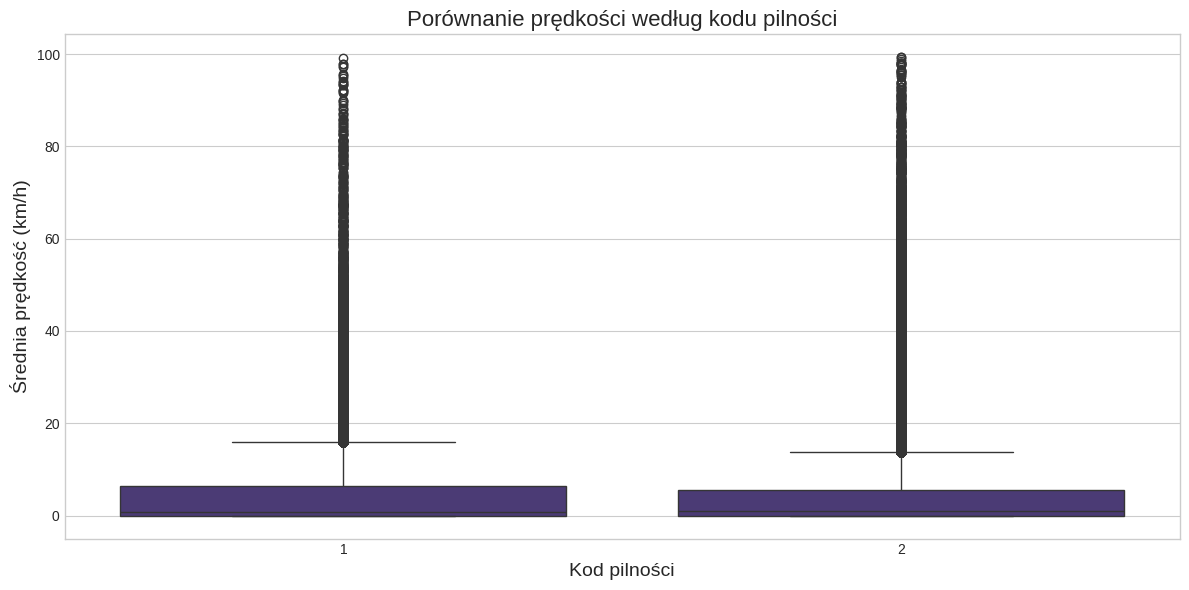

In [15]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Kod pilności', y='Średnia prędkość (km/h)', data=gdf_speed)
plt.title('Porównanie prędkości według kodu pilności', fontsize=16)
plt.xlabel('Kod pilności', fontsize=14)
plt.ylabel('Średnia prędkość (km/h)', fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Konfiguracja stylów
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 100

# Wczytanie danych
print("Wczytywanie danych...")
gdf = pd.read_parquet("wynik_caly.parquet")

# Przygotowanie danych
gdf['Czas wyjazdu ZRM'] = pd.to_datetime(gdf['Czas wyjazdu ZRM'])
gdf['Czas powrotu ZRM'] = pd.to_datetime(gdf['Czas powrotu ZRM'])
gdf['Czas trwania (min)'] = (gdf['Czas powrotu ZRM'] - gdf['Czas wyjazdu ZRM']).dt.total_seconds() / 60
gdf['Godzina wyjazdu'] = gdf['Czas wyjazdu ZRM'].dt.hour
gdf['Dzień tygodnia'] = gdf['Czas wyjazdu ZRM'].dt.dayofweek
gdf['Miesiąc'] = gdf['Czas wyjazdu ZRM'].dt.month
gdf['Dzień miesiąca'] = gdf['Czas wyjazdu ZRM'].dt.day
gdf['Tydzień roku'] = gdf['Czas wyjazdu ZRM'].dt.isocalendar().week
gdf['Data'] = gdf['Czas wyjazdu ZRM'].dt.date

# Mapowanie nazw
day_names = {0: 'Poniedziałek', 1: 'Wtorek', 2: 'Środa', 3: 'Czwartek', 
             4: 'Piątek', 5: 'Sobota', 6: 'Niedziela'}
gdf['Dzień tygodnia nazwa'] = gdf['Dzień tygodnia'].map(day_names)

month_names = {1: 'Styczeń', 2: 'Luty', 3: 'Marzec', 4: 'Kwiecień',
               5: 'Maj', 6: 'Czerwiec', 7: 'Lipiec', 8: 'Sierpień',
               9: 'Wrzesień', 10: 'Październik', 11: 'Listopad', 12: 'Grudzień'}
gdf['Miesiąc nazwa'] = gdf['Miesiąc'].map(month_names)

# Kategorie czasowe
def categorize_time(hour):
    if 6 <= hour < 12:
        return 'Rano'
    elif 12 <= hour < 18:
        return 'Popołudnie'
    elif 18 <= hour < 22:
        return 'Wieczór'
    else:
        return 'Noc'

gdf['Pora dnia'] = gdf['Godzina wyjazdu'].apply(categorize_time)

print(f"Załadowano {len(gdf)} rekordów")
print(f"Zakres dat: {gdf['Czas wyjazdu ZRM'].min()} - {gdf['Czas wyjazdu ZRM'].max()}")

Wczytywanie danych...
Załadowano 594255 rekordów
Zakres dat: 2021-01-01 00:03:41 - 2023-12-31 22:58:50



=== SEKCJA 1: ANALIZA CZASOWA ===


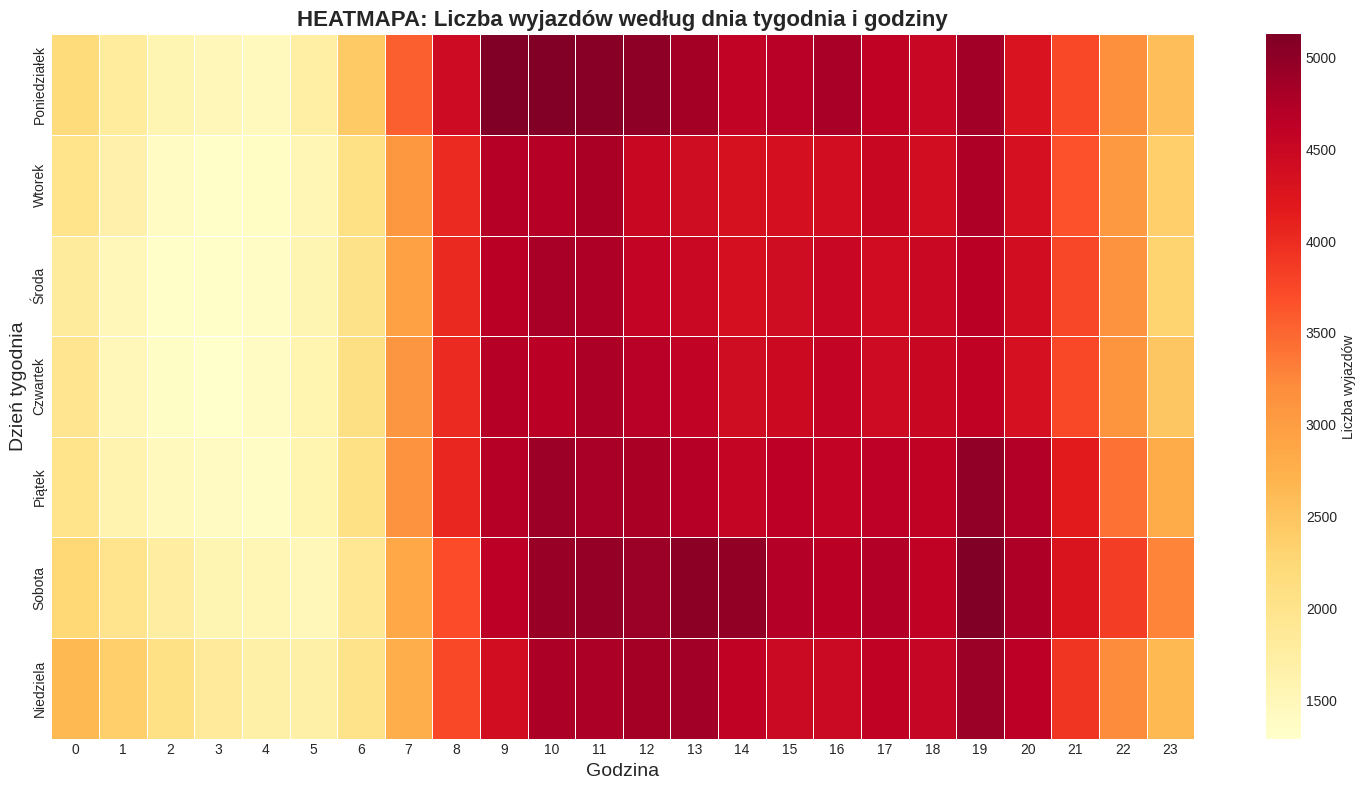

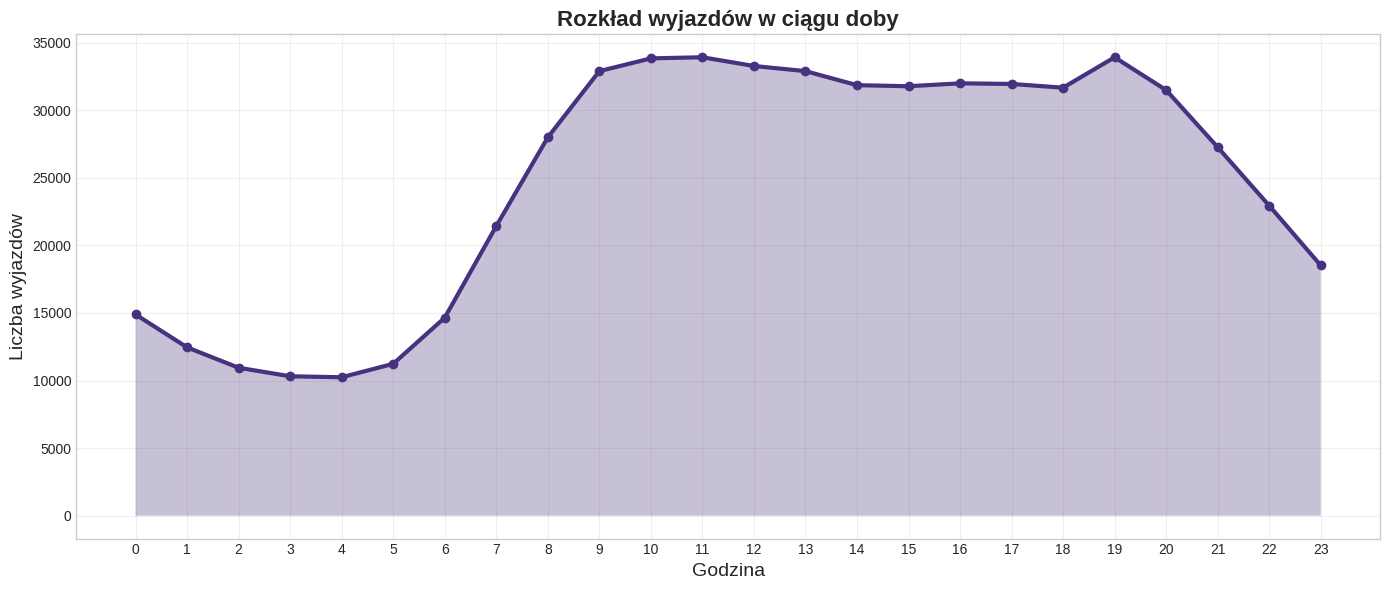

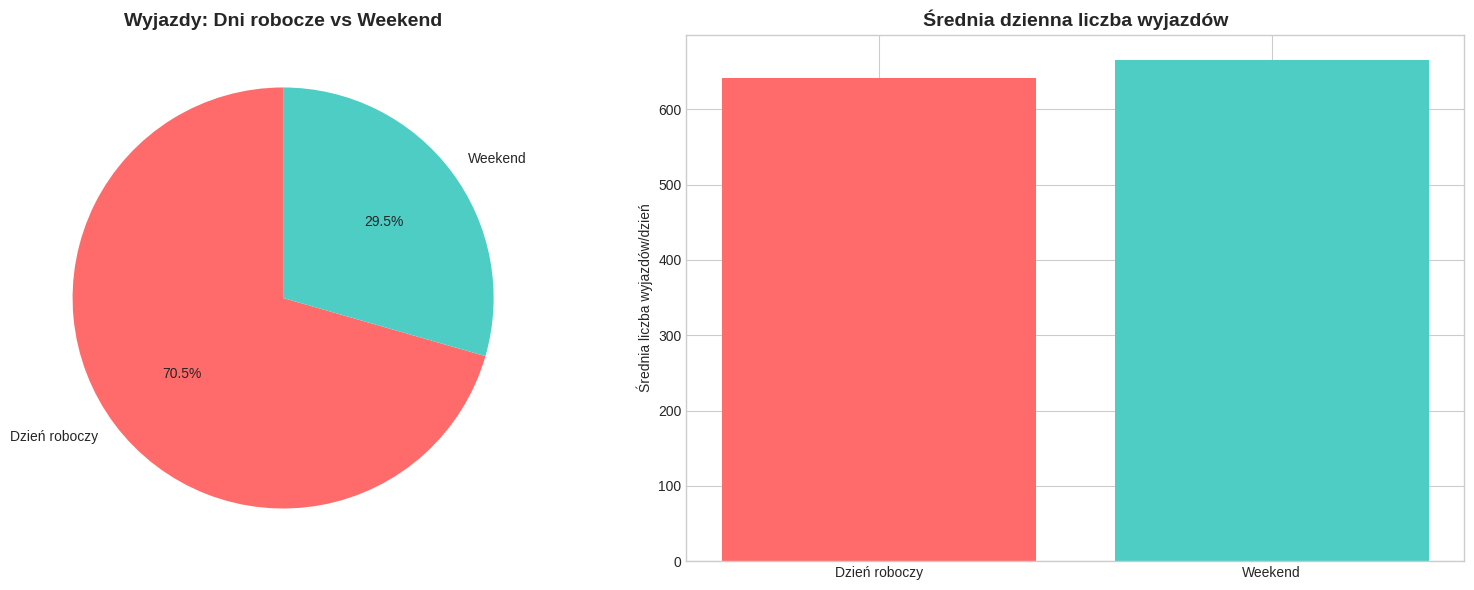

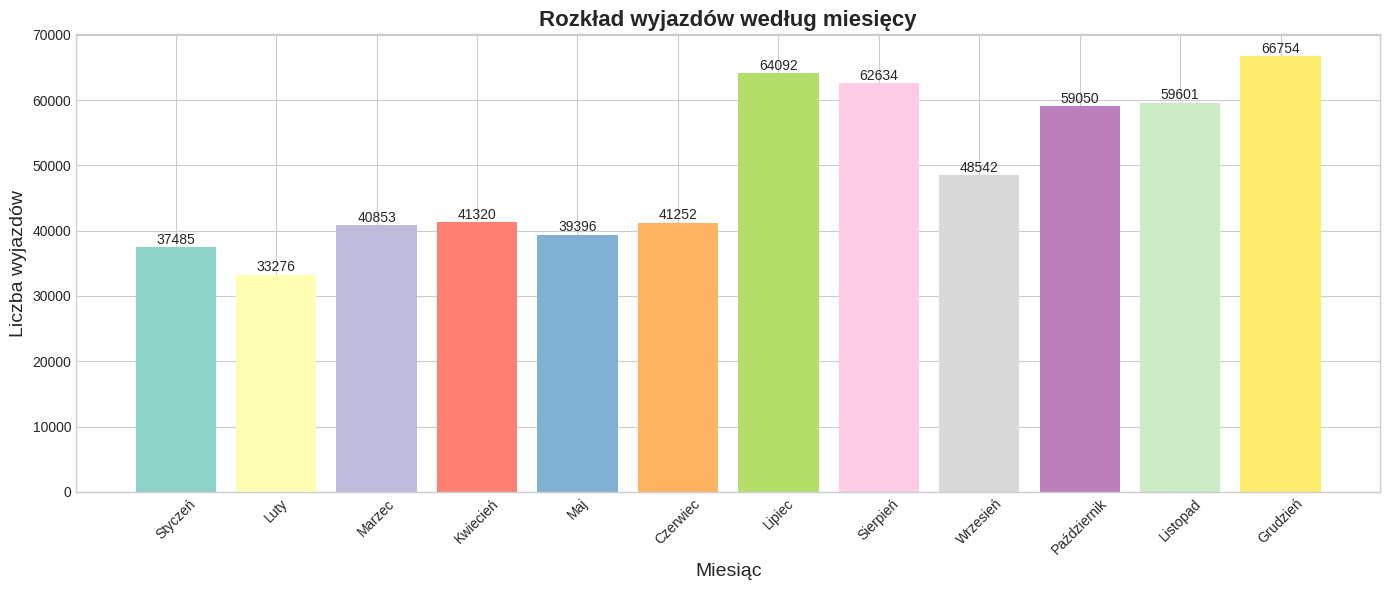

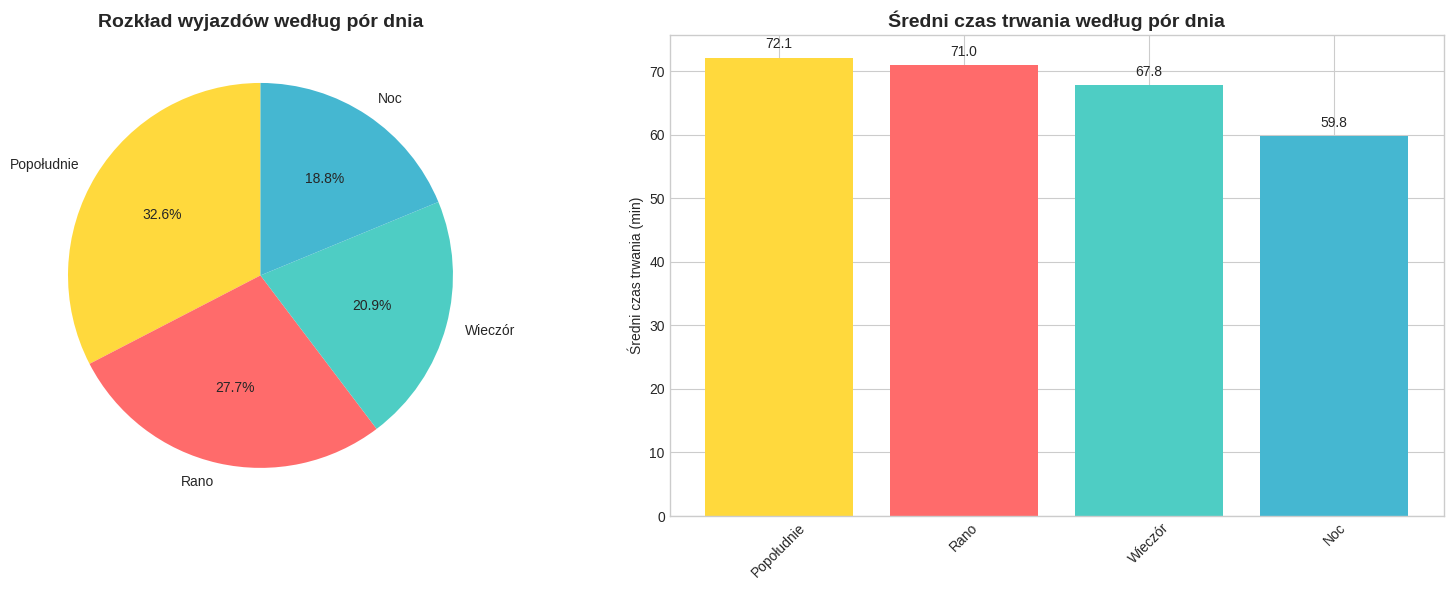

In [17]:
# =============================================================================
# SEKCJA 1: ANALIZA CZASOWA - WZORCE TEMPORALNE
# =============================================================================

print("\n=== SEKCJA 1: ANALIZA CZASOWA ===")

# 1. Heatmapa godzina vs dzień tygodnia
fig, ax = plt.subplots(figsize=(15, 8))
hour_day_pivot = pd.crosstab(index=gdf['Dzień tygodnia nazwa'], columns=gdf['Godzina wyjazdu'])
hour_day_pivot = hour_day_pivot.reindex(['Poniedziałek', 'Wtorek', 'Środa', 'Czwartek', 
                                        'Piątek', 'Sobota', 'Niedziela'])
sns.heatmap(hour_day_pivot, cmap="YlOrRd", linewidths=.5, annot=False, 
            cbar_kws={'label': 'Liczba wyjazdów'})
plt.title('HEATMAPA: Liczba wyjazdów według dnia tygodnia i godziny', fontsize=16, fontweight='bold')
plt.xlabel('Godzina', fontsize=14)
plt.ylabel('Dzień tygodnia', fontsize=14)
plt.tight_layout()
plt.show()

# 2. Wykres liniowy - trend godzinowy
fig, ax = plt.subplots(figsize=(14, 6))
hourly_calls = gdf.groupby('Godzina wyjazdu').size()
ax.plot(hourly_calls.index, hourly_calls.values, marker='o', linewidth=3, markersize=6)
ax.fill_between(hourly_calls.index, hourly_calls.values, alpha=0.3)
plt.title('Rozkład wyjazdów w ciągu doby', fontsize=16, fontweight='bold')
plt.xlabel('Godzina', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

# 3. Porównanie dni tygodnia vs weekendy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Dni robocze vs weekend
gdf['Typ dnia'] = gdf['Dzień tygodnia'].apply(lambda x: 'Weekend' if x >= 5 else 'Dzień roboczy')
day_type_counts = gdf['Typ dnia'].value_counts()
colors = ['#FF6B6B', '#4ECDC4']
ax1.pie(day_type_counts.values, labels=day_type_counts.index, autopct='%1.1f%%', 
        colors=colors, startangle=90)
ax1.set_title('Wyjazdy: Dni robocze vs Weekend', fontsize=14, fontweight='bold')

# Średnia dzienna według typu dnia
daily_avg = gdf.groupby(['Data', 'Typ dnia']).size().reset_index(name='count')
daily_avg_summary = daily_avg.groupby('Typ dnia')['count'].mean()
ax2.bar(daily_avg_summary.index, daily_avg_summary.values, color=colors)
ax2.set_title('Średnia dzienna liczba wyjazdów', fontsize=14, fontweight='bold')
ax2.set_ylabel('Średnia liczba wyjazdów/dzień')
plt.tight_layout()
plt.show()

# 4. Analiza sezonowa - miesięczna
fig, ax = plt.subplots(figsize=(14, 6))
monthly_calls = gdf['Miesiąc nazwa'].value_counts().reindex(month_names.values())
bars = ax.bar(monthly_calls.index, monthly_calls.values, color=plt.cm.Set3(np.arange(12)))
plt.title('Rozkład wyjazdów według miesięcy', fontsize=16, fontweight='bold')
plt.xlabel('Miesiąc', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.xticks(rotation=45)

# Dodanie wartości na słupkach
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 50,
            f'{int(height)}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# 5. Analiza pór dnia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Rozkład według pór dnia
time_period_counts = gdf['Pora dnia'].value_counts()
colors = ['#FFD93D', '#FF6B6B', '#4ECDC4', '#45B7D1']
wedges, texts, autotexts = ax1.pie(time_period_counts.values, labels=time_period_counts.index, 
                                   autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Rozkład wyjazdów według pór dnia', fontsize=14, fontweight='bold')

# Średni czas trwania według pór dnia
time_duration = gdf.groupby('Pora dnia')['Czas trwania (min)'].mean().sort_values(ascending=False)
bars = ax2.bar(time_duration.index, time_duration.values, color=colors)
ax2.set_title('Średni czas trwania według pór dnia', fontsize=14, fontweight='bold')
ax2.set_ylabel('Średni czas trwania (min)')
ax2.set_xticklabels(time_duration.index, rotation=45)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()


=== SEKCJA 2: ANALIZA KODÓW PILNOŚCI I POWODÓW ===


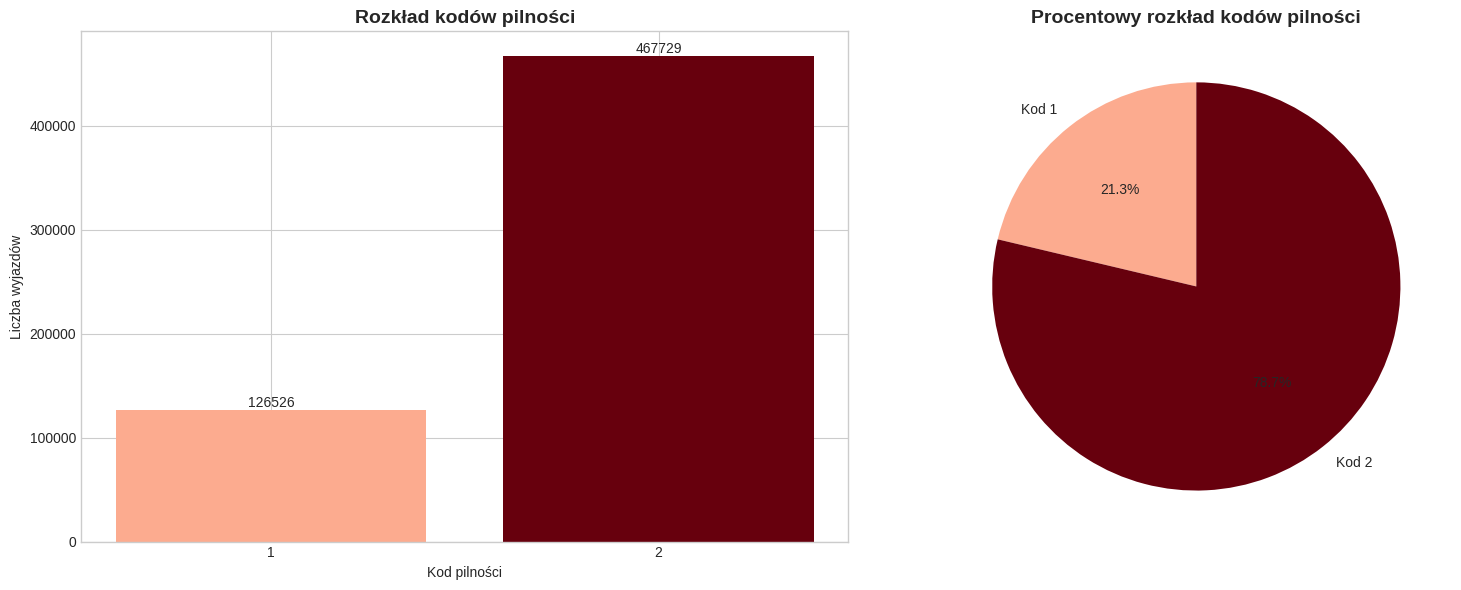

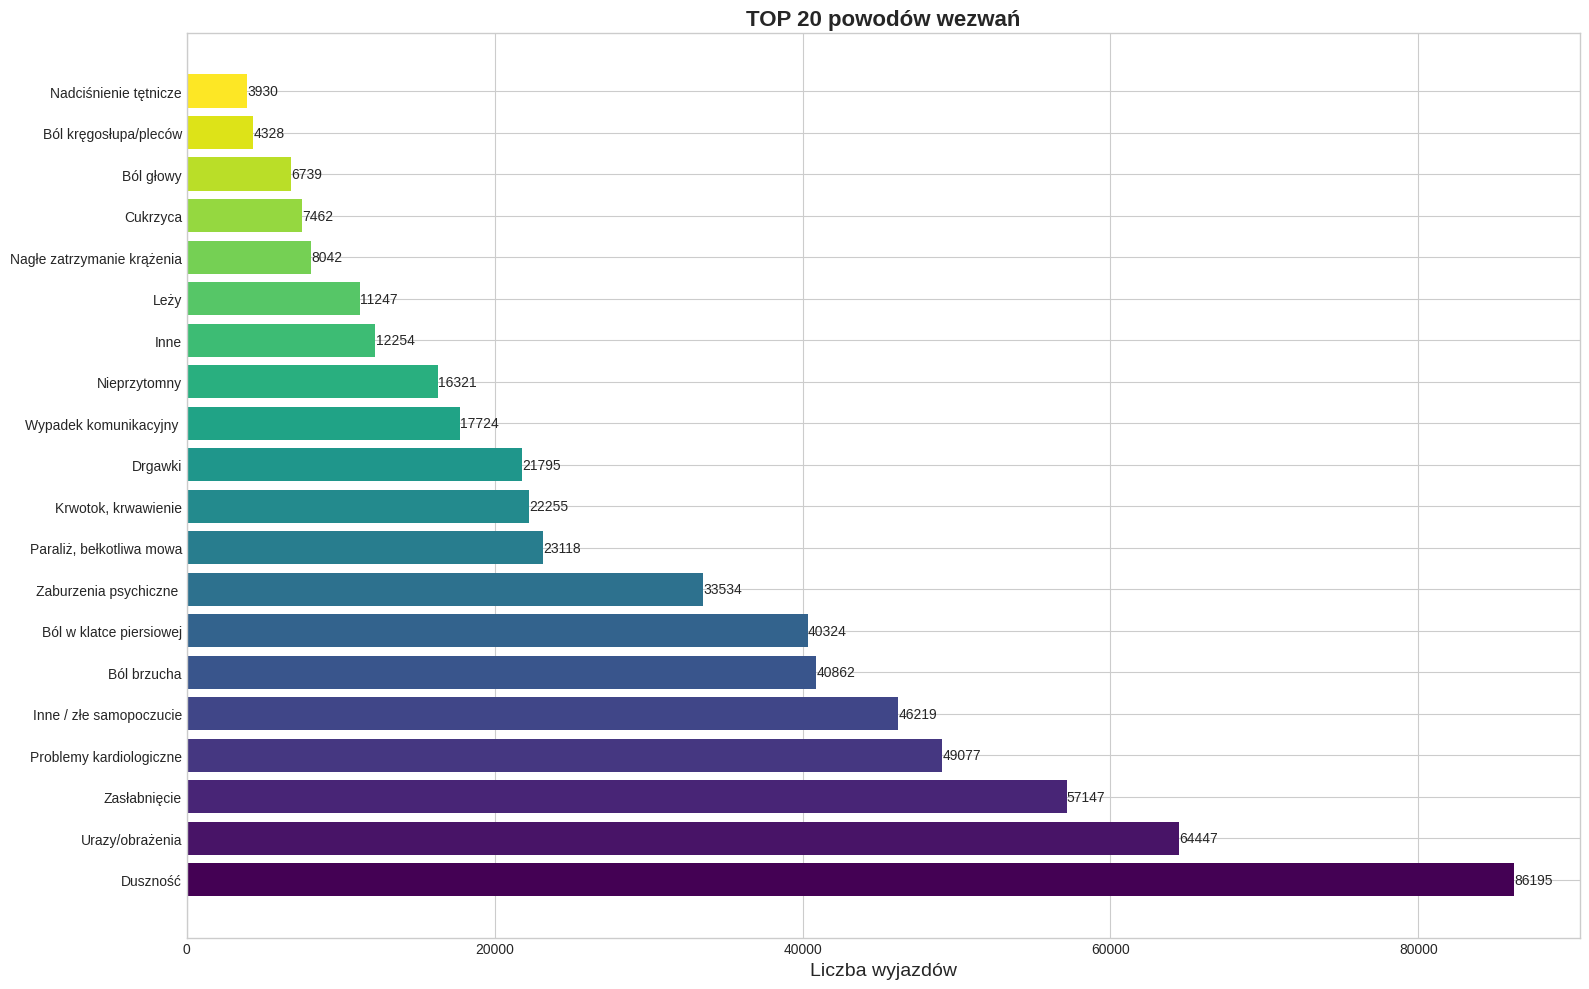

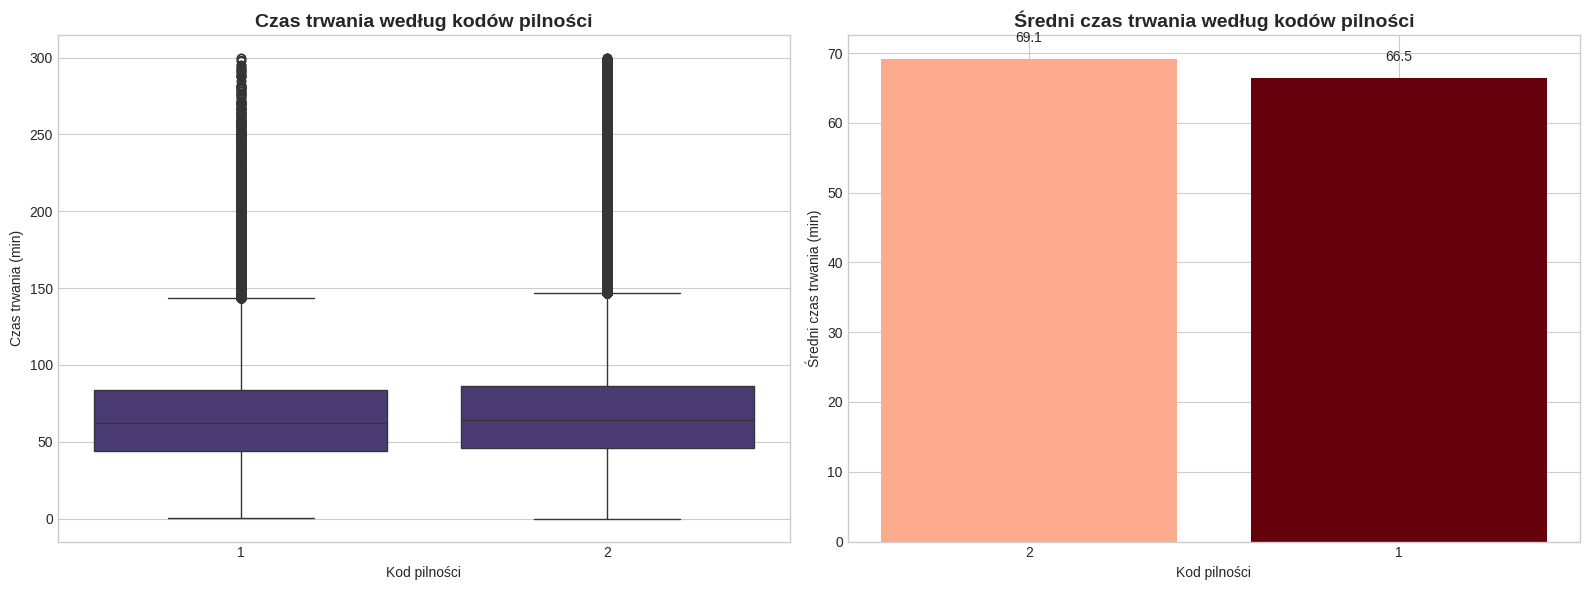

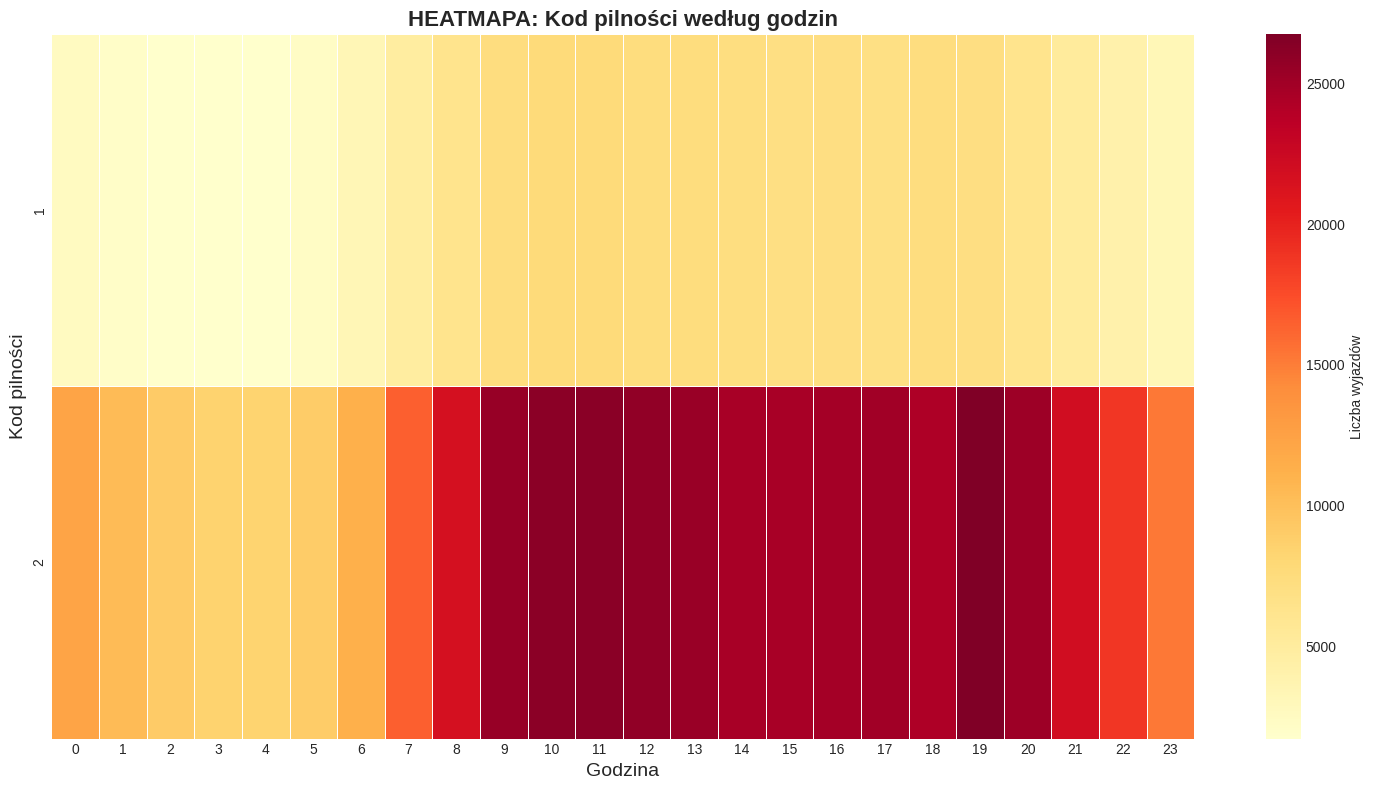

In [18]:
# =============================================================================
# SEKCJA 2: ANALIZA KODÓW PILNOŚCI I POWODÓW WEZWAŃ
# =============================================================================

print("\n=== SEKCJA 2: ANALIZA KODÓW PILNOŚCI I POWODÓW ===")

# 6. Rozkład kodów pilności
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

urgency_counts = gdf['Kod pilności'].value_counts().sort_index()
bars1 = ax1.bar(urgency_counts.index.astype(str), urgency_counts.values, 
                color=plt.cm.Reds(np.linspace(0.3, 1, len(urgency_counts))))
ax1.set_title('Rozkład kodów pilności', fontsize=14, fontweight='bold')
ax1.set_xlabel('Kod pilności')
ax1.set_ylabel('Liczba wyjazdów')

# Dodanie wartości na słupkach
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 100,
             f'{int(height)}', ha='center', va='bottom')

# Procentowy rozkład kodów pilności
urgency_pct = (urgency_counts / urgency_counts.sum() * 100)
ax2.pie(urgency_pct.values, labels=[f'Kod {i}' for i in urgency_pct.index], 
        autopct='%1.1f%%', startangle=90, colors=plt.cm.Reds(np.linspace(0.3, 1, len(urgency_pct))))
ax2.set_title('Procentowy rozkład kodów pilności', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 7. Top powody wezwań
fig, ax = plt.subplots(figsize=(16, 10))
top_reasons = gdf['Powód wezwania'].value_counts().head(20)
bars = ax.barh(range(len(top_reasons)), top_reasons.values, 
               color=plt.cm.viridis(np.linspace(0, 1, len(top_reasons))))
ax.set_yticks(range(len(top_reasons)))
ax.set_yticklabels(top_reasons.index, fontsize=10)
ax.set_xlabel('Liczba wyjazdów', fontsize=14)
ax.set_title('TOP 20 powodów wezwań', fontsize=16, fontweight='bold')

# Dodanie wartości na słupkach
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 20, bar.get_y() + bar.get_height()/2,
            f'{int(width)}', ha='left', va='center')
plt.tight_layout()
plt.show()

# 8. Czas trwania według kodów pilności
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot czasu trwania według kodów pilności
gdf_filtered = gdf[gdf['Czas trwania (min)'] <= 300]  # Filtruj ekstremalne wartości
sns.boxplot(x='Kod pilności', y='Czas trwania (min)', data=gdf_filtered, ax=ax1)
ax1.set_title('Czas trwania według kodów pilności', fontsize=14, fontweight='bold')
ax1.set_xlabel('Kod pilności')
ax1.set_ylabel('Czas trwania (min)')

# Średni czas według kodów pilności
avg_duration = gdf.groupby('Kod pilności')['Czas trwania (min)'].mean().sort_values(ascending=False)
bars = ax2.bar(avg_duration.index.astype(str), avg_duration.values, 
               color=plt.cm.Reds(np.linspace(0.3, 1, len(avg_duration))))
ax2.set_title('Średni czas trwania według kodów pilności', fontsize=14, fontweight='bold')
ax2.set_xlabel('Kod pilności')
ax2.set_ylabel('Średni czas trwania (min)')

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{height:.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# 9. Heatmapa: Kod pilności vs Godzina
fig, ax = plt.subplots(figsize=(15, 8))
urgency_hour_pivot = pd.crosstab(index=gdf['Kod pilności'], columns=gdf['Godzina wyjazdu'])
sns.heatmap(urgency_hour_pivot, cmap="YlOrRd", linewidths=.5, annot=False, 
            cbar_kws={'label': 'Liczba wyjazdów'})
plt.title('HEATMAPA: Kod pilności według godzin', fontsize=16, fontweight='bold')
plt.xlabel('Godzina', fontsize=14)
plt.ylabel('Kod pilności', fontsize=14)
plt.tight_layout()
plt.show()


=== SEKCJA 4: ANALIZA CZASÓW I WYDAJNOŚCI ===


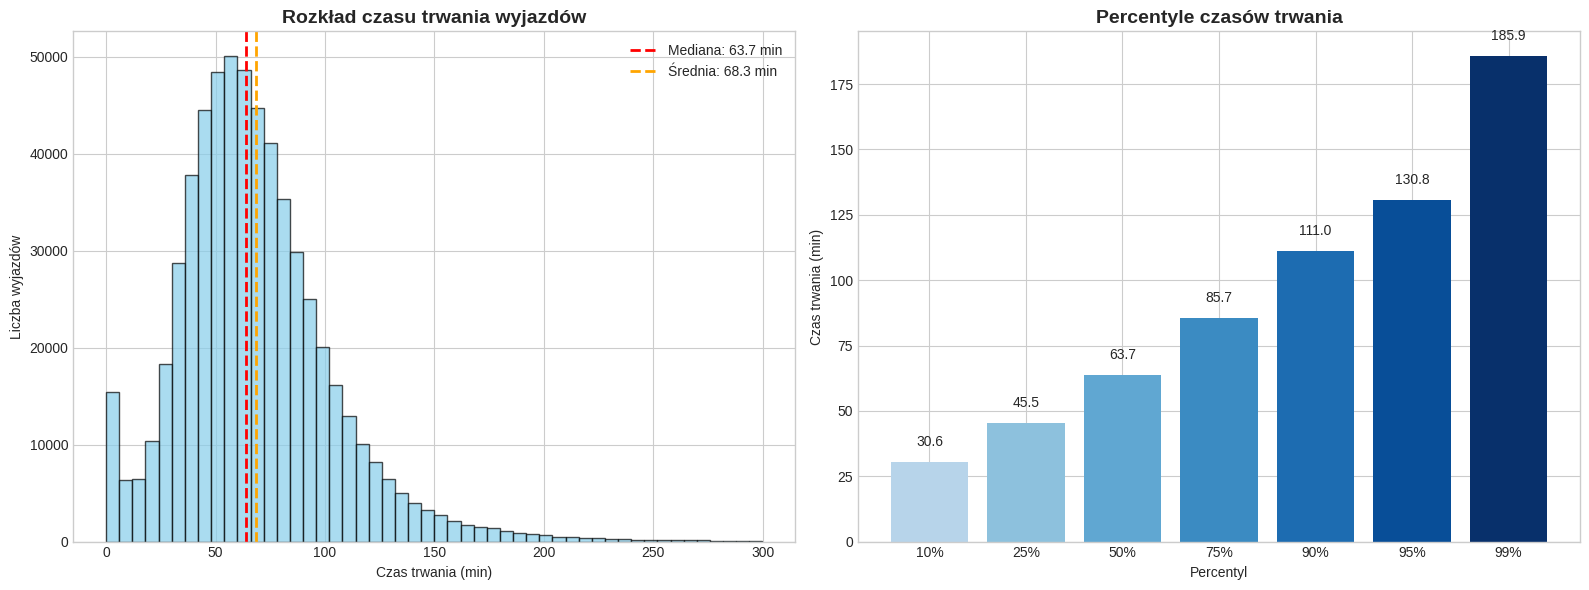

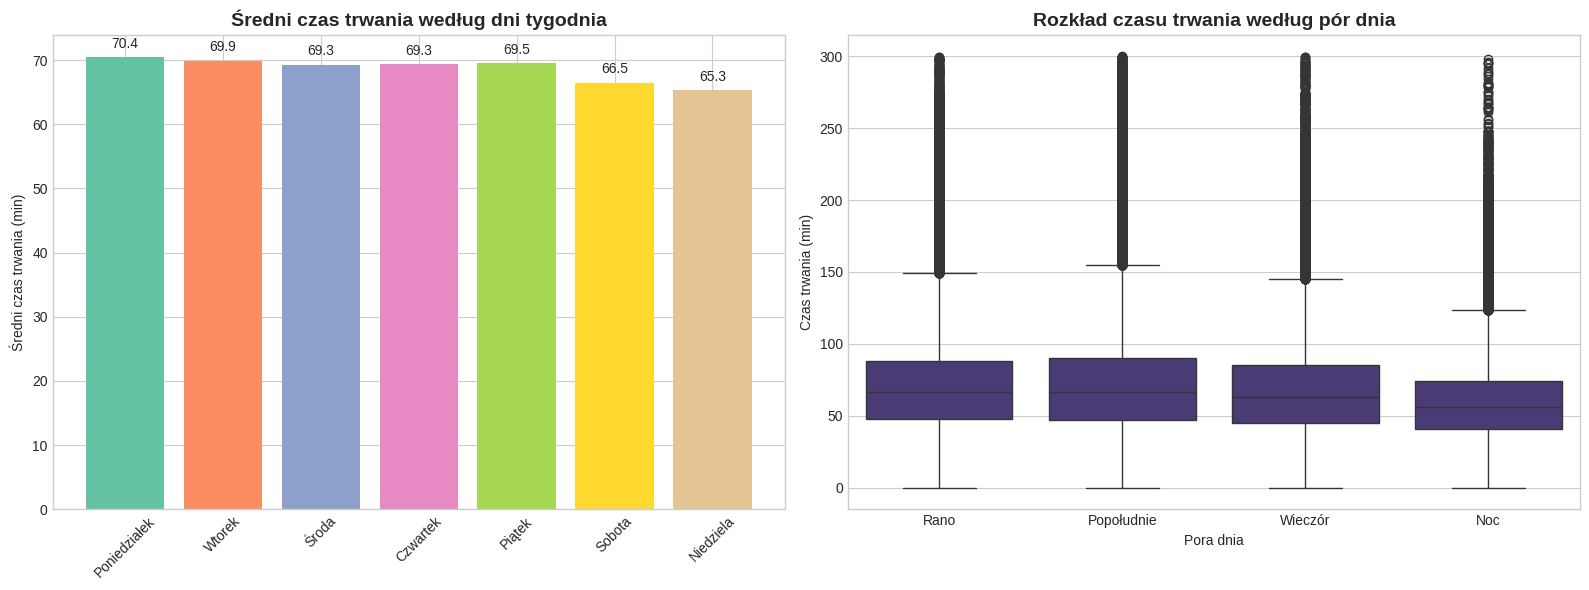

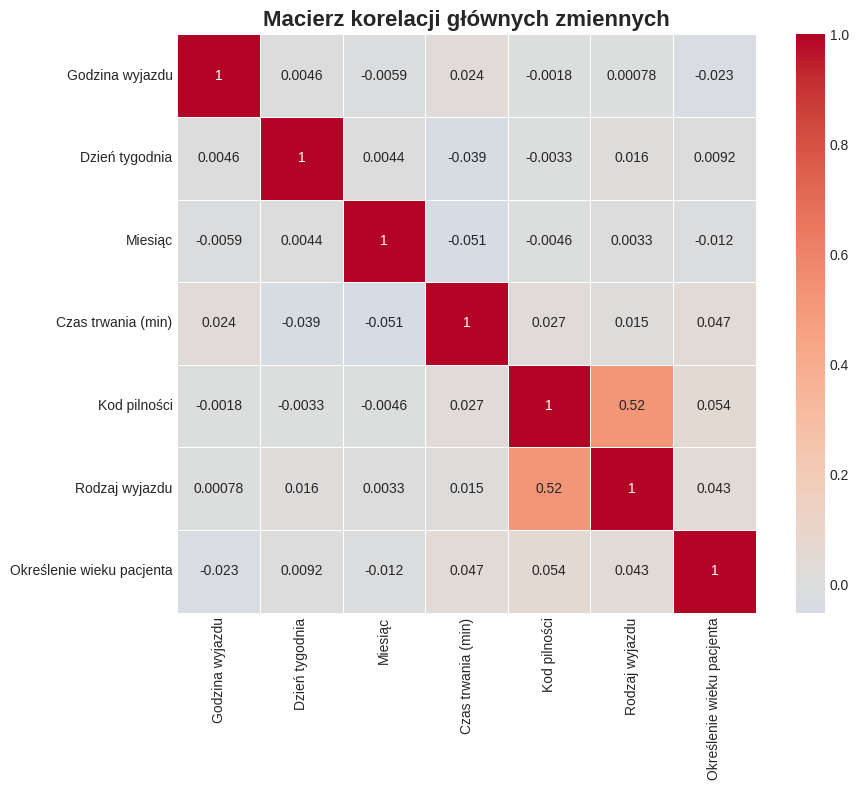

In [19]:
# =============================================================================
# SEKCJA 4: ANALIZA CZASU TRWANIA I WYDAJNOŚCI
# =============================================================================

print("\n=== SEKCJA 4: ANALIZA CZASÓW I WYDAJNOŚCI ===")

# 13. Rozkład czasów trwania
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram czasów trwania (ograniczony do 300 min)
duration_filtered = gdf[gdf['Czas trwania (min)'] <= 300]['Czas trwania (min)']
ax1.hist(duration_filtered, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(duration_filtered.median(), color='red', linestyle='--', linewidth=2,
            label=f'Mediana: {duration_filtered.median():.1f} min')
ax1.axvline(duration_filtered.mean(), color='orange', linestyle='--', linewidth=2,
            label=f'Średnia: {duration_filtered.mean():.1f} min')
ax1.set_title('Rozkład czasu trwania wyjazdów', fontsize=14, fontweight='bold')
ax1.set_xlabel('Czas trwania (min)')
ax1.set_ylabel('Liczba wyjazdów')
ax1.legend()

# Percentyle czasów trwania
percentiles = [10, 25, 50, 75, 90, 95, 99]
perc_values = [np.percentile(duration_filtered, p) for p in percentiles]
ax2.bar([f'{p}%' for p in percentiles], perc_values, color=plt.cm.Blues(np.linspace(0.3, 1, len(percentiles))))
ax2.set_title('Percentyle czasów trwania', fontsize=14, fontweight='bold')
ax2.set_ylabel('Czas trwania (min)')
ax2.set_xlabel('Percentyl')

for i, v in enumerate(perc_values):
    ax2.text(i, v + 5, f'{v:.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# 14. Czas trwania według dni tygodnia i pór dnia
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Według dni tygodnia
daily_duration = gdf.groupby('Dzień tygodnia nazwa')['Czas trwania (min)'].mean()
daily_duration = daily_duration.reindex(['Poniedziałek', 'Wtorek', 'Środa', 'Czwartek', 
                                        'Piątek', 'Sobota', 'Niedziela'])
bars1 = ax1.bar(daily_duration.index, daily_duration.values, 
                color=plt.cm.Set2(np.arange(len(daily_duration))))
ax1.set_title('Średni czas trwania według dni tygodnia', fontsize=14, fontweight='bold')
ax1.set_ylabel('Średni czas trwania (min)')
ax1.set_xticklabels(daily_duration.index, rotation=45)

for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}', ha='center', va='bottom')

# Według pór dnia - boxplot
time_period_order = ['Rano', 'Popołudnie', 'Wieczór', 'Noc']
gdf_time_filtered = gdf[gdf['Czas trwania (min)'] <= 300]
sns.boxplot(x='Pora dnia', y='Czas trwania (min)', data=gdf_time_filtered, 
            order=time_period_order, ax=ax2)
ax2.set_title('Rozkład czasu trwania według pór dnia', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 15. Korelacja między różnymi zmiennymi czasowymi
fig, ax = plt.subplots(figsize=(10, 8))
correlation_vars = ['Godzina wyjazdu', 'Dzień tygodnia', 'Miesiąc', 'Czas trwania (min)', 
                   'Kod pilności', 'Rodzaj wyjazdu', 'Określenie wieku pacjenta']
corr_matrix = gdf[correlation_vars].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Macierz korelacji głównych zmiennych', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()



=== SEKCJA 5: ANALIZA TRENDÓW CZASOWYCH ===


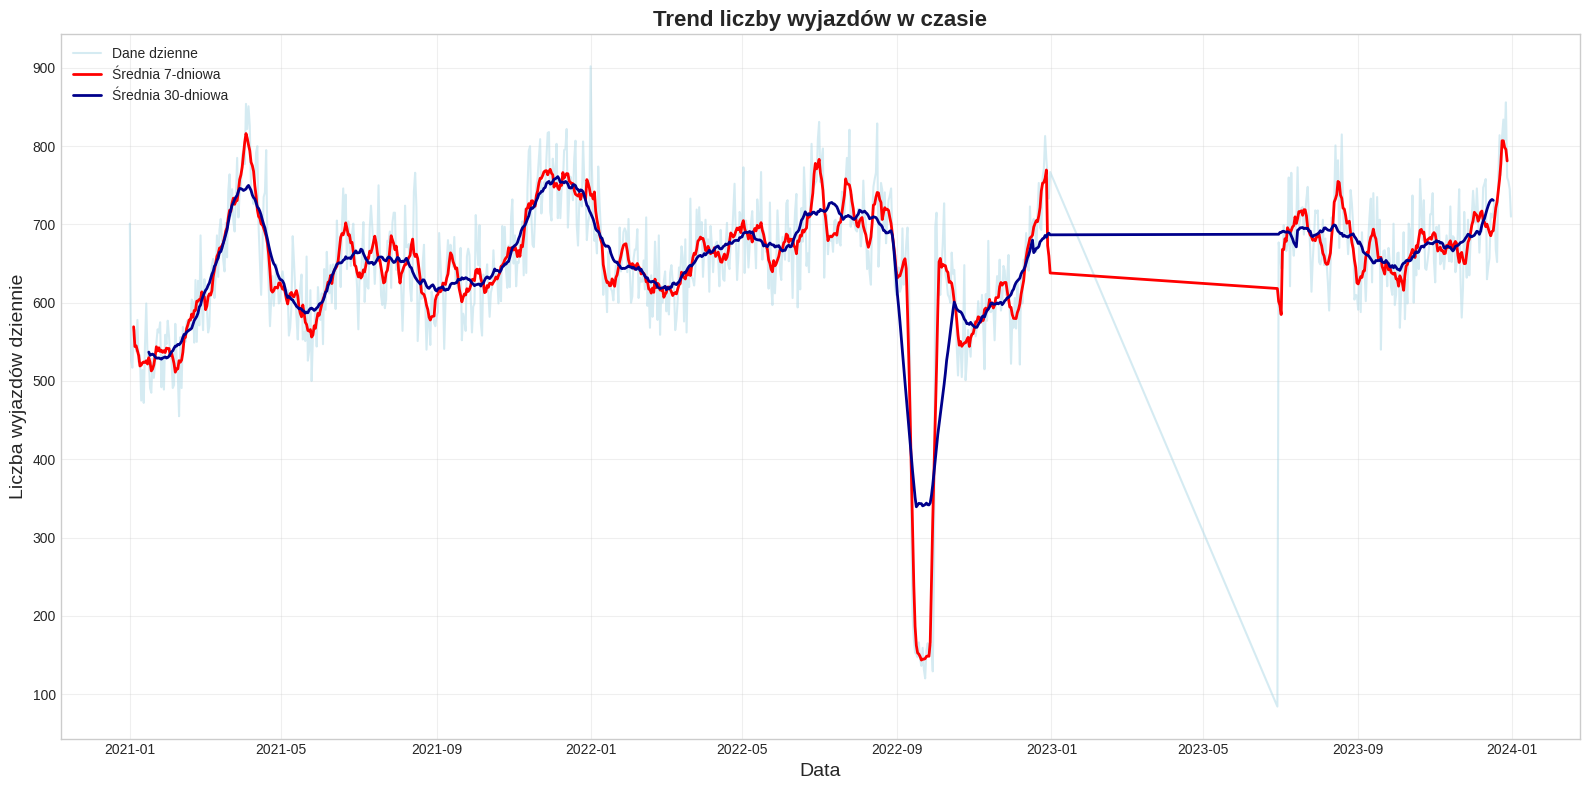

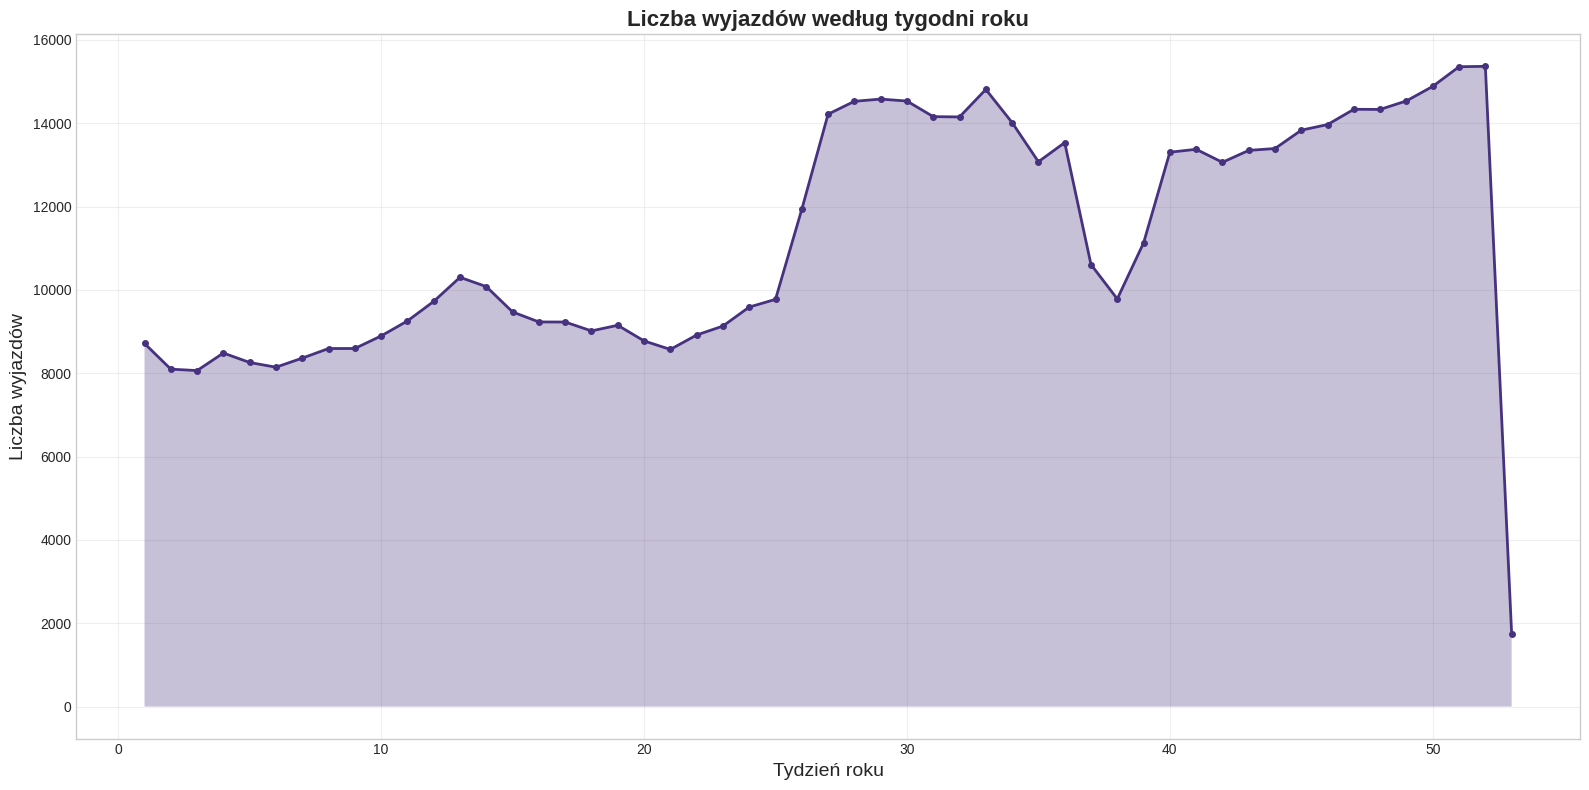

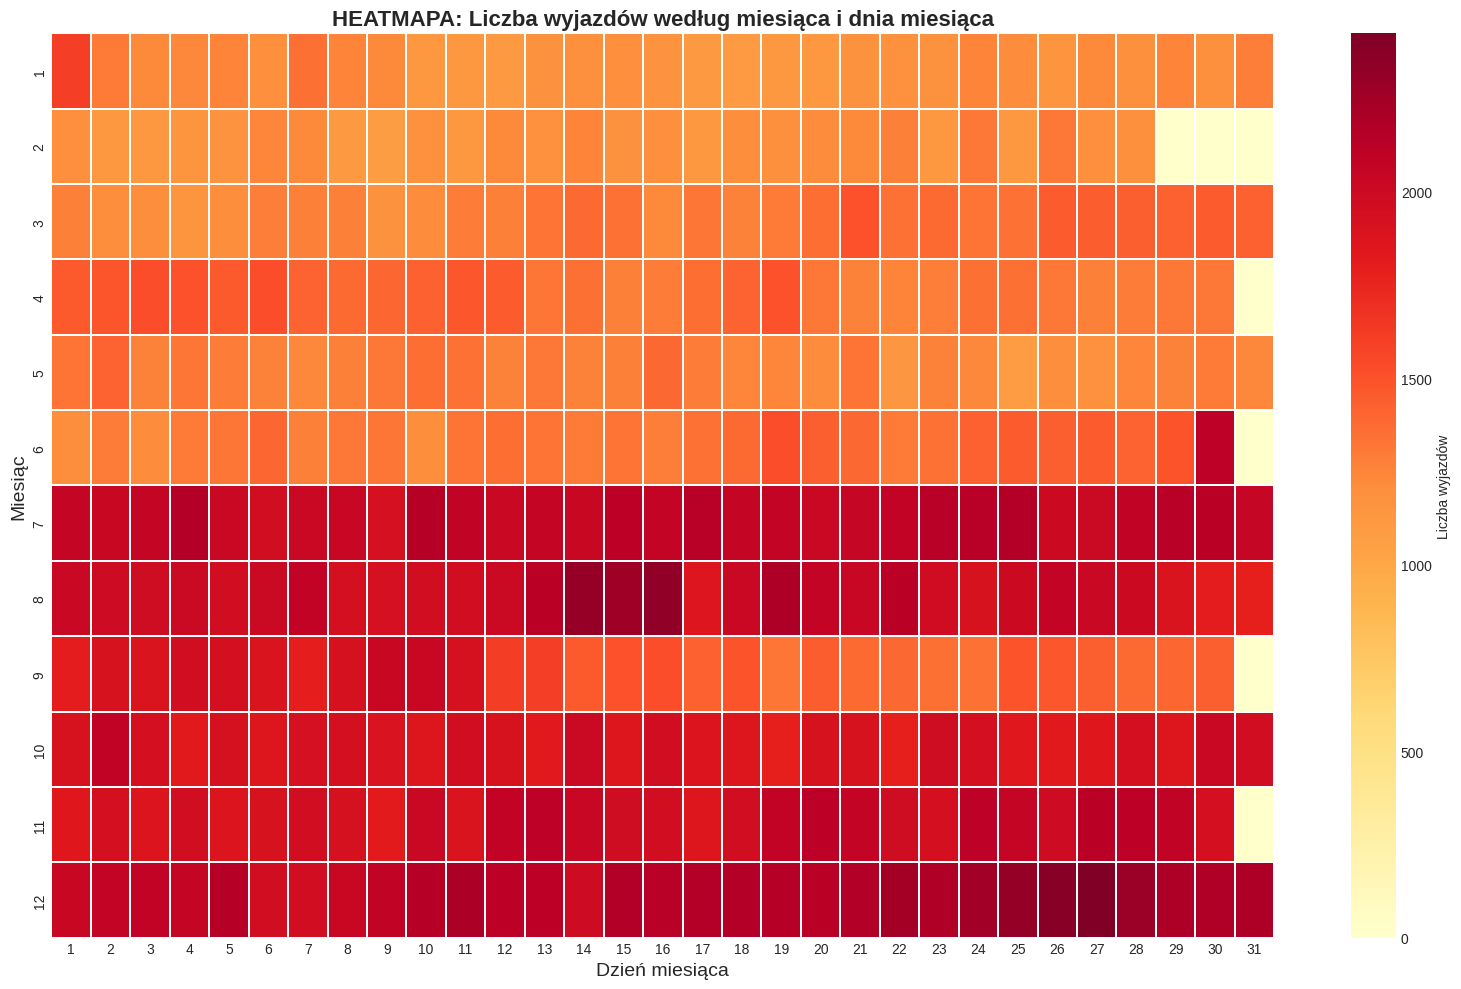

In [20]:
# =============================================================================
# SEKCJA 5: ANALIZA TYGODNIOWA I TREND CZASOWY
# =============================================================================

print("\n=== SEKCJA 5: ANALIZA TRENDÓW CZASOWYCH ===")

# 16. Trend dzienny
fig, ax = plt.subplots(figsize=(16, 8))
daily_calls = gdf.groupby('Data').size().reset_index(name='count')
daily_calls['Data'] = pd.to_datetime(daily_calls['Data'])
daily_calls = daily_calls.sort_values('Data')

ax.plot(daily_calls['Data'], daily_calls['count'], alpha=0.5, color='lightblue', label='Dane dzienne')
# Średnia krocząca 7-dniowa
rolling_mean = daily_calls['count'].rolling(window=7, center=True).mean()
ax.plot(daily_calls['Data'], rolling_mean, color='red', linewidth=2, label='Średnia 7-dniowa')
# Średnia krocząca 30-dniowa
rolling_mean_30 = daily_calls['count'].rolling(window=30, center=True).mean()
ax.plot(daily_calls['Data'], rolling_mean_30, color='darkblue', linewidth=2, label='Średnia 30-dniowa')

plt.title('Trend liczby wyjazdów w czasie', fontsize=16, fontweight='bold')
plt.xlabel('Data', fontsize=14)
plt.ylabel('Liczba wyjazdów dziennie', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 17. Analiza tygodniowa - porównanie tygodni
fig, ax = plt.subplots(figsize=(16, 8))
weekly_calls = gdf.groupby('Tydzień roku').size()
ax.plot(weekly_calls.index, weekly_calls.values, marker='o', linewidth=2, markersize=4)
ax.fill_between(weekly_calls.index, weekly_calls.values, alpha=0.3)
plt.title('Liczba wyjazdów według tygodni roku', fontsize=16, fontweight='bold')
plt.xlabel('Tydzień roku', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 18. Heatmapa: Miesiąc vs Dzień miesiąca
fig, ax = plt.subplots(figsize=(16, 10))
month_day_pivot = pd.crosstab(index=gdf['Miesiąc'], columns=gdf['Dzień miesiąca'])
sns.heatmap(month_day_pivot, cmap="YlOrRd", linewidths=0.1, 
            cbar_kws={'label': 'Liczba wyjazdów'}, ax=ax)
plt.title('HEATMAPA: Liczba wyjazdów według miesiąca i dnia miesiąca', fontsize=16, fontweight='bold')
plt.xlabel('Dzień miesiąca', fontsize=14)
plt.ylabel('Miesiąc', fontsize=14)
plt.tight_layout()
plt.show()


=== SEKCJA 6: SZCZEGÓŁOWA ANALIZA POWODÓW ===


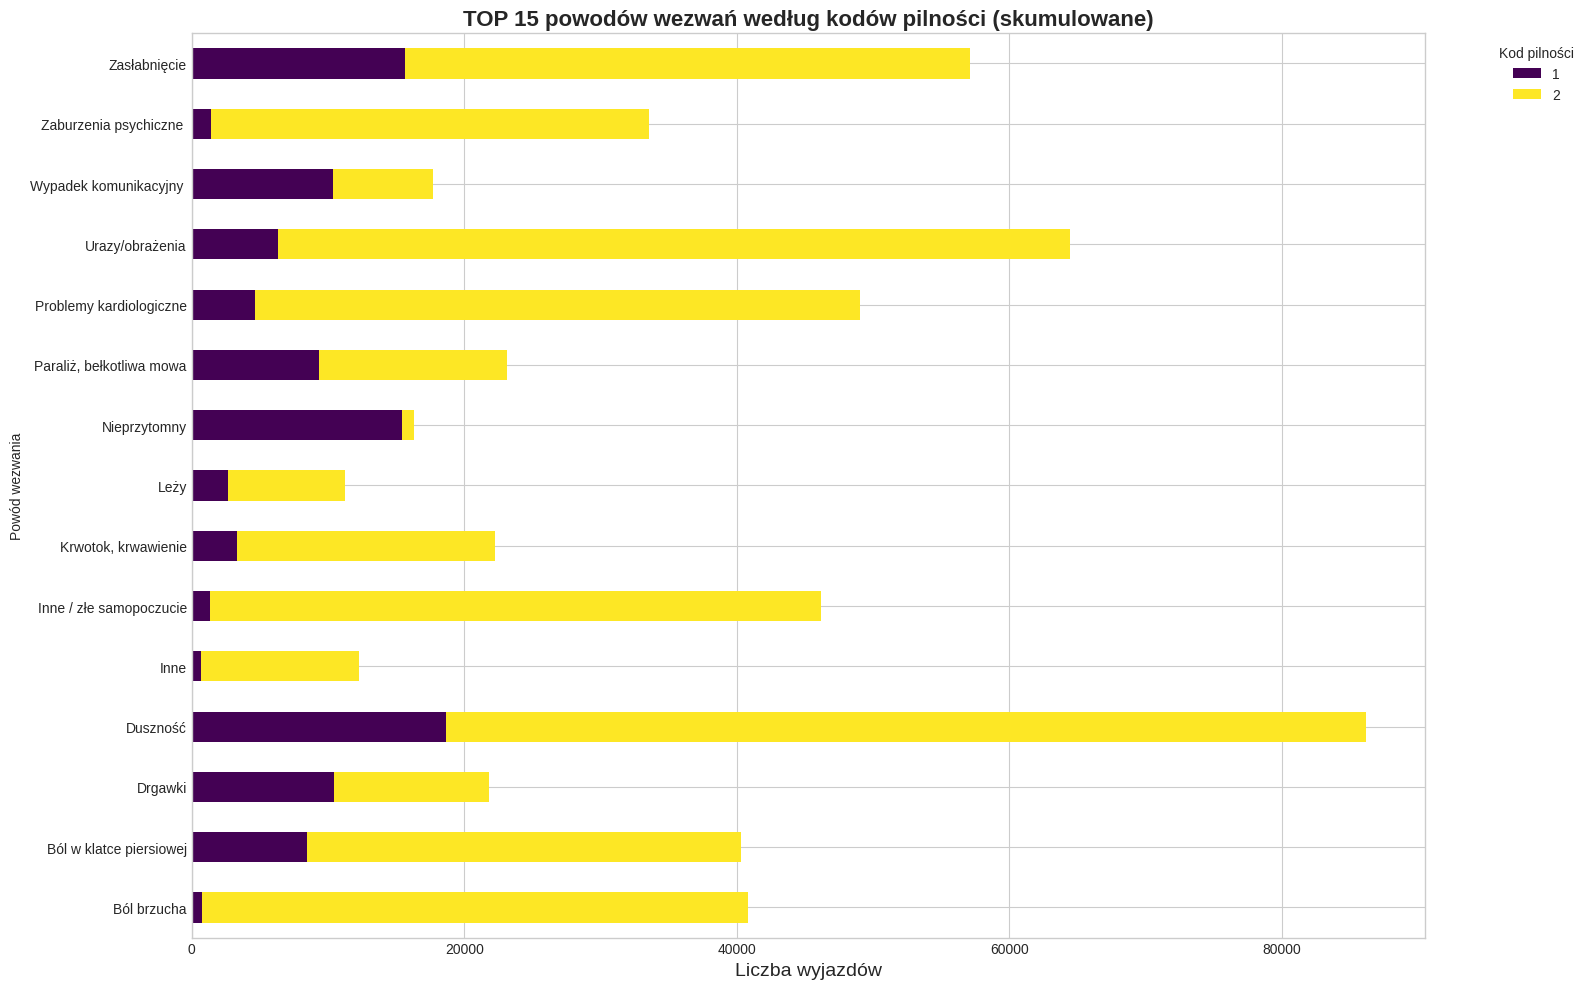

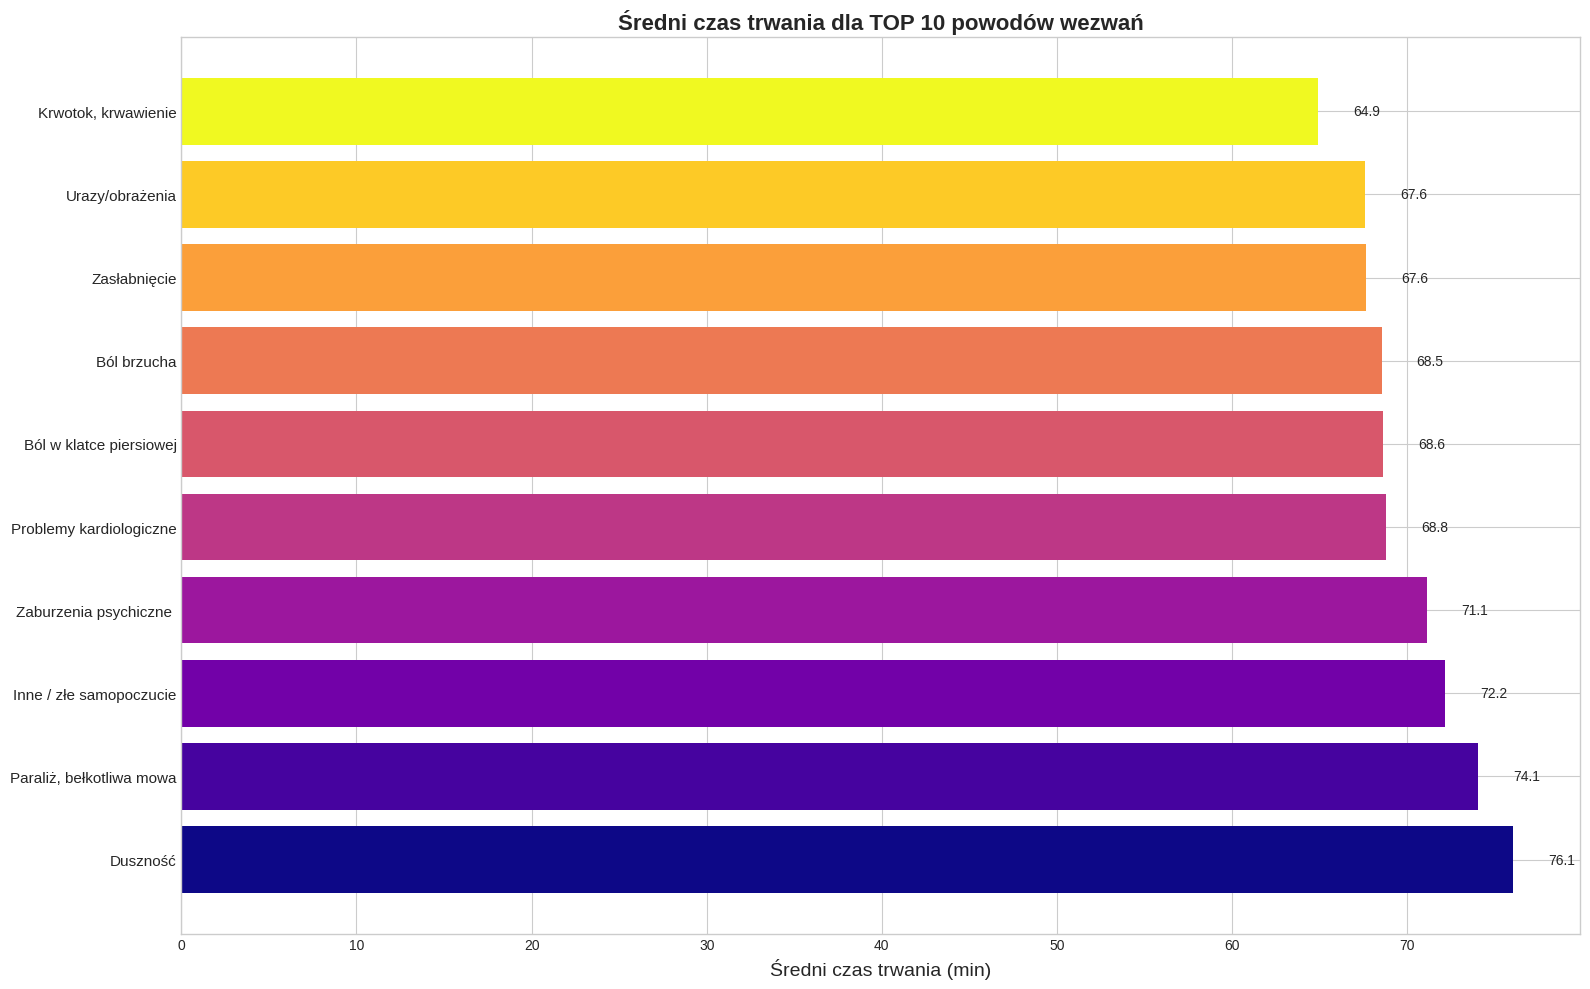

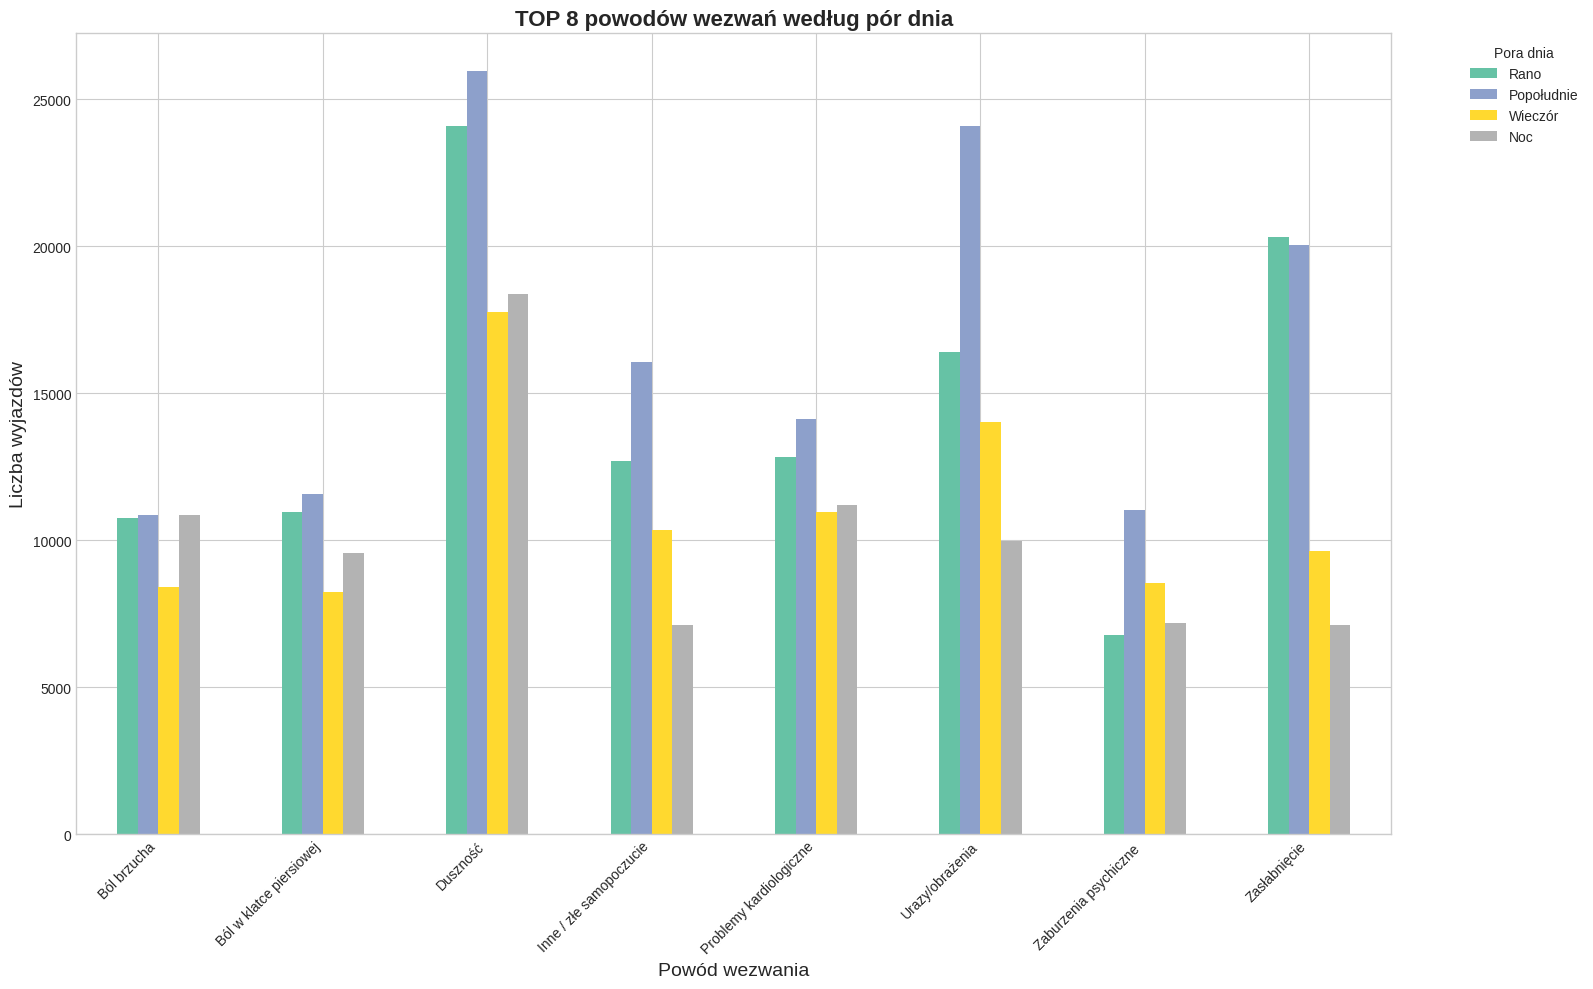

In [21]:
# =============================================================================
# SEKCJA 6: ANALIZA SZCZEGÓŁOWA POWODÓW WEZWAŃ
# =============================================================================

print("\n=== SEKCJA 6: SZCZEGÓŁOWA ANALIZA POWODÓW ===")

# 19. Analiza powodów według kodów pilności
fig, ax = plt.subplots(figsize=(16, 10))
# Top 15 powodów według kodów pilności
top_reasons_15 = gdf['Powód wezwania'].value_counts().head(15).index
reason_urgency_cross = pd.crosstab(gdf[gdf['Powód wezwania'].isin(top_reasons_15)]['Powód wezwania'], 
                                  gdf[gdf['Powód wezwania'].isin(top_reasons_15)]['Kod pilności'])
reason_urgency_cross.plot(kind='barh', ax=ax, colormap='viridis', stacked=True)
plt.title('TOP 15 powodów wezwań według kodów pilności (skumulowane)', fontsize=16, fontweight='bold')
plt.xlabel('Liczba wyjazdów', fontsize=14)
plt.legend(title='Kod pilności', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 20. Czas trwania według top powodów wezwań
fig, ax = plt.subplots(figsize=(16, 10))
top_10_reasons = gdf['Powód wezwania'].value_counts().head(10).index
reason_duration = gdf[gdf['Powód wezwania'].isin(top_10_reasons)].groupby('Powód wezwania')['Czas trwania (min)'].mean().sort_values(ascending=False)

bars = ax.barh(range(len(reason_duration)), reason_duration.values,
               color=plt.cm.plasma(np.linspace(0, 1, len(reason_duration))))
ax.set_yticks(range(len(reason_duration)))
ax.set_yticklabels(reason_duration.index, fontsize=11)
ax.set_xlabel('Średni czas trwania (min)', fontsize=14)
ax.set_title('Średni czas trwania dla TOP 10 powodów wezwań', fontsize=16, fontweight='bold')

for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 2, bar.get_y() + bar.get_height()/2,
            f'{width:.1f}', ha='left', va='center')
plt.tight_layout()
plt.show()

# 21. Powody wezwań według pór dnia
fig, ax = plt.subplots(figsize=(16, 10))
top_8_reasons = gdf['Powód wezwania'].value_counts().head(8).index
reason_time_cross = pd.crosstab(gdf[gdf['Powód wezwania'].isin(top_8_reasons)]['Powód wezwania'], 
                               gdf[gdf['Powód wezwania'].isin(top_8_reasons)]['Pora dnia'])
reason_time_cross = reason_time_cross[['Rano', 'Popołudnie', 'Wieczór', 'Noc']]
reason_time_cross.plot(kind='bar', ax=ax, colormap='Set2')
plt.title('TOP 8 powodów wezwań według pór dnia', fontsize=16, fontweight='bold')
plt.xlabel('Powód wezwania', fontsize=14)
plt.ylabel('Liczba wyjazdów', fontsize=14)
plt.legend(title='Pora dnia', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


=== SEKCJA 10: KLUCZOWE STATYSTYKI ===


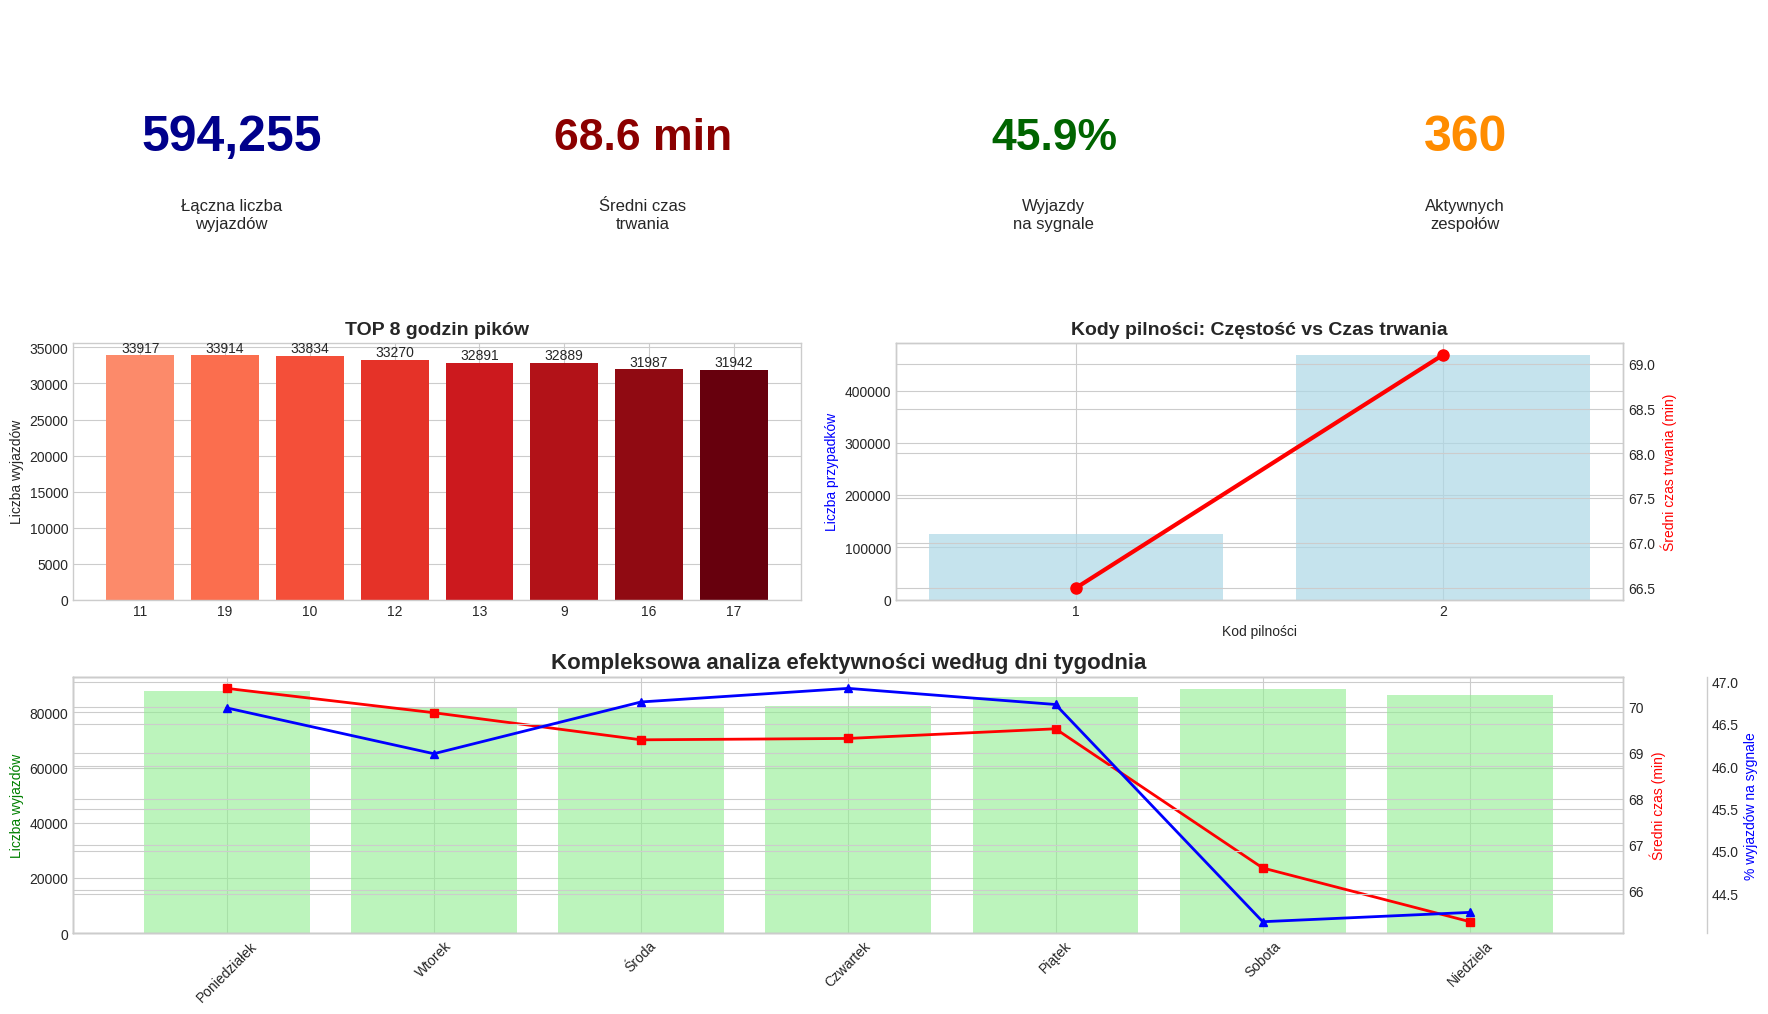


PODSUMOWANIE ANALIZY DANYCH AMBULANSOWYCH
📊 Okres analizy: 2021-01-01 - 2023-12-31
🚑 Łączna liczba wyjazdów: 594,255
👥 Liczba aktywnych zespołów: 360
⏱️  Średni czas trwania: 68.6 min
🔴 Odsetek wyjazdów na sygnale: 45.9%
👶 Odsetek wyjazdów do dzieci: 5.6%
📈 Najczęstszy kod pilności: 2


In [22]:
# =============================================================================
# SEKCJA 10: PODSUMOWANIE I INSIGHTS
# =============================================================================

print("\n=== SEKCJA 10: KLUCZOWE STATYSTYKI ===")

# 30. Dashboard z kluczowymi statystykami
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# KPI 1: Łączna liczba wyjazdów
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.5, f'{len(gdf):,}', fontsize=36, ha='center', va='center', fontweight='bold', color='darkblue')
ax1.text(0.5, 0.2, 'Łączna liczba\nwyjazdów', fontsize=12, ha='center', va='center')
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis('off')

# KPI 2: Średni czas trwania
ax2 = fig.add_subplot(gs[0, 1])
avg_duration = gdf['Czas trwania (min)'].mean()
ax2.text(0.5, 0.5, f'{avg_duration:.1f} min', fontsize=32, ha='center', va='center', fontweight='bold', color='darkred')
ax2.text(0.5, 0.2, 'Średni czas\ntrwania', fontsize=12, ha='center', va='center')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.axis('off')

# KPI 3: Odsetek wyjazdów na sygnale
ax3 = fig.add_subplot(gs[0, 2])
pct_emergency = (gdf['Rodzaj wyjazdu'] == 0).mean() * 100
ax3.text(0.5, 0.5, f'{pct_emergency:.1f}%', fontsize=32, ha='center', va='center', fontweight='bold', color='darkgreen')
ax3.text(0.5, 0.2, 'Wyjazdy\nna sygnale', fontsize=12, ha='center', va='center')
ax3.set_xlim(0, 1)
ax3.set_ylim(0, 1)
ax3.axis('off')

# KPI 4: Liczba unikalnych zespołów
ax4 = fig.add_subplot(gs[0, 3])
unique_teams = gdf['ID_GPS'].nunique()
ax4.text(0.5, 0.5, f'{unique_teams}', fontsize=36, ha='center', va='center', fontweight='bold', color='darkorange')
ax4.text(0.5, 0.2, 'Aktywnych\nzespołów', fontsize=12, ha='center', va='center')
ax4.set_xlim(0, 1)
ax4.set_ylim(0, 1)
ax4.axis('off')

# Wykres 1: Top godziny pików
ax5 = fig.add_subplot(gs[1, :2])
peak_hours = gdf.groupby('Godzina wyjazdu').size().nlargest(8)
bars = ax5.bar(peak_hours.index.astype(str), peak_hours.values, color=plt.cm.Reds(np.linspace(0.4, 1, len(peak_hours))))
ax5.set_title('TOP 8 godzin pików', fontsize=14, fontweight='bold')
ax5.set_ylabel('Liczba wyjazdów')
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height + 20, f'{int(height)}', ha='center', va='bottom')

# Wykres 2: Porównanie kodów pilności
ax6 = fig.add_subplot(gs[1, 2:])
urgency_stats = gdf.groupby('Kod pilności').agg({
    'Czas trwania (min)': 'mean',
    'wyjazd_id': 'count'
}).round(1)
urgency_stats.columns = ['Średni czas (min)', 'Liczba przypadków']

ax6_twin = ax6.twinx()
bars1 = ax6.bar(urgency_stats.index.astype(str), urgency_stats['Liczba przypadków'], 
                alpha=0.7, color='lightblue', label='Liczba przypadków')
line1 = ax6_twin.plot(urgency_stats.index.astype(str), urgency_stats['Średni czas (min)'], 
                      color='red', marker='o', linewidth=3, markersize=8, label='Średni czas')

ax6.set_xlabel('Kod pilności')
ax6.set_ylabel('Liczba przypadków', color='blue')
ax6_twin.set_ylabel('Średni czas trwania (min)', color='red')
ax6.set_title('Kody pilności: Częstość vs Czas trwania', fontsize=14, fontweight='bold')

# Wykres 3: Efektywność dni tygodnia
ax7 = fig.add_subplot(gs[2, :])
daily_efficiency = gdf.groupby('Dzień tygodnia nazwa').agg({
    'Czas trwania (min)': ['mean', 'count'],
    'Rodzaj wyjazdu': lambda x: (x == 0).mean() * 100
}).round(2)

daily_efficiency.columns = ['Średni czas', 'Liczba wyjazdów', '% na sygnale']
daily_efficiency = daily_efficiency.reindex(['Poniedziałek', 'Wtorek', 'Środa', 'Czwartek', 
                                           'Piątek', 'Sobota', 'Niedziela'])

ax7_twin1 = ax7.twinx()
ax7_twin2 = ax7.twinx()
ax7_twin2.spines['right'].set_position(('outward', 60))

p1 = ax7.bar(daily_efficiency.index, daily_efficiency['Liczba wyjazdów'], 
             alpha=0.6, color='lightgreen', label='Liczba wyjazdów')
p2 = ax7_twin1.plot(daily_efficiency.index, daily_efficiency['Średni czas'], 
                    color='red', marker='s', linewidth=2, label='Średni czas (min)')
p3 = ax7_twin2.plot(daily_efficiency.index, daily_efficiency['% na sygnale'], 
                    color='blue', marker='^', linewidth=2, label='% na sygnale')

ax7.set_ylabel('Liczba wyjazdów', color='green')
ax7_twin1.set_ylabel('Średni czas (min)', color='red')
ax7_twin2.set_ylabel('% wyjazdów na sygnale', color='blue')
ax7.set_title('Kompleksowa analiza efektywności według dni tygodnia', fontsize=16, fontweight='bold')
ax7.set_xticklabels(daily_efficiency.index, rotation=45)

plt.tight_layout()
plt.show()

# Wydruk statystyk końcowych
print("\n" + "="*60)
print("PODSUMOWANIE ANALIZY DANYCH AMBULANSOWYCH")
print("="*60)
print(f"📊 Okres analizy: {gdf['Czas wyjazdu ZRM'].min().strftime('%Y-%m-%d')} - {gdf['Czas wyjazdu ZRM'].max().strftime('%Y-%m-%d')}")
print(f"🚑 Łączna liczba wyjazdów: {len(gdf):,}")
print(f"👥 Liczba aktywnych zespołów: {gdf['ID_GPS'].nunique()}")
print(f"⏱️  Średni czas trwania: {gdf['Czas trwania (min)'].mean():.1f} min")
print(f"🔴 Odsetek wyjazdów na sygnale: {(gdf['Rodzaj wyjazdu'] == 0).mean()*100:.1f}%")
print(f"👶 Odsetek wyjazdów do dzieci: {(gdf['Określenie wieku pacjenta'] == 0).mean()*100:.1f}%")
print(f"📈 Najczęstszy kod pilności: {gdf['Kod pilności'].mode().iloc[0]}")


=== SEKCJA 15: EFEKTY WEEKENDOWE I ŚWIĄTECZNE ===


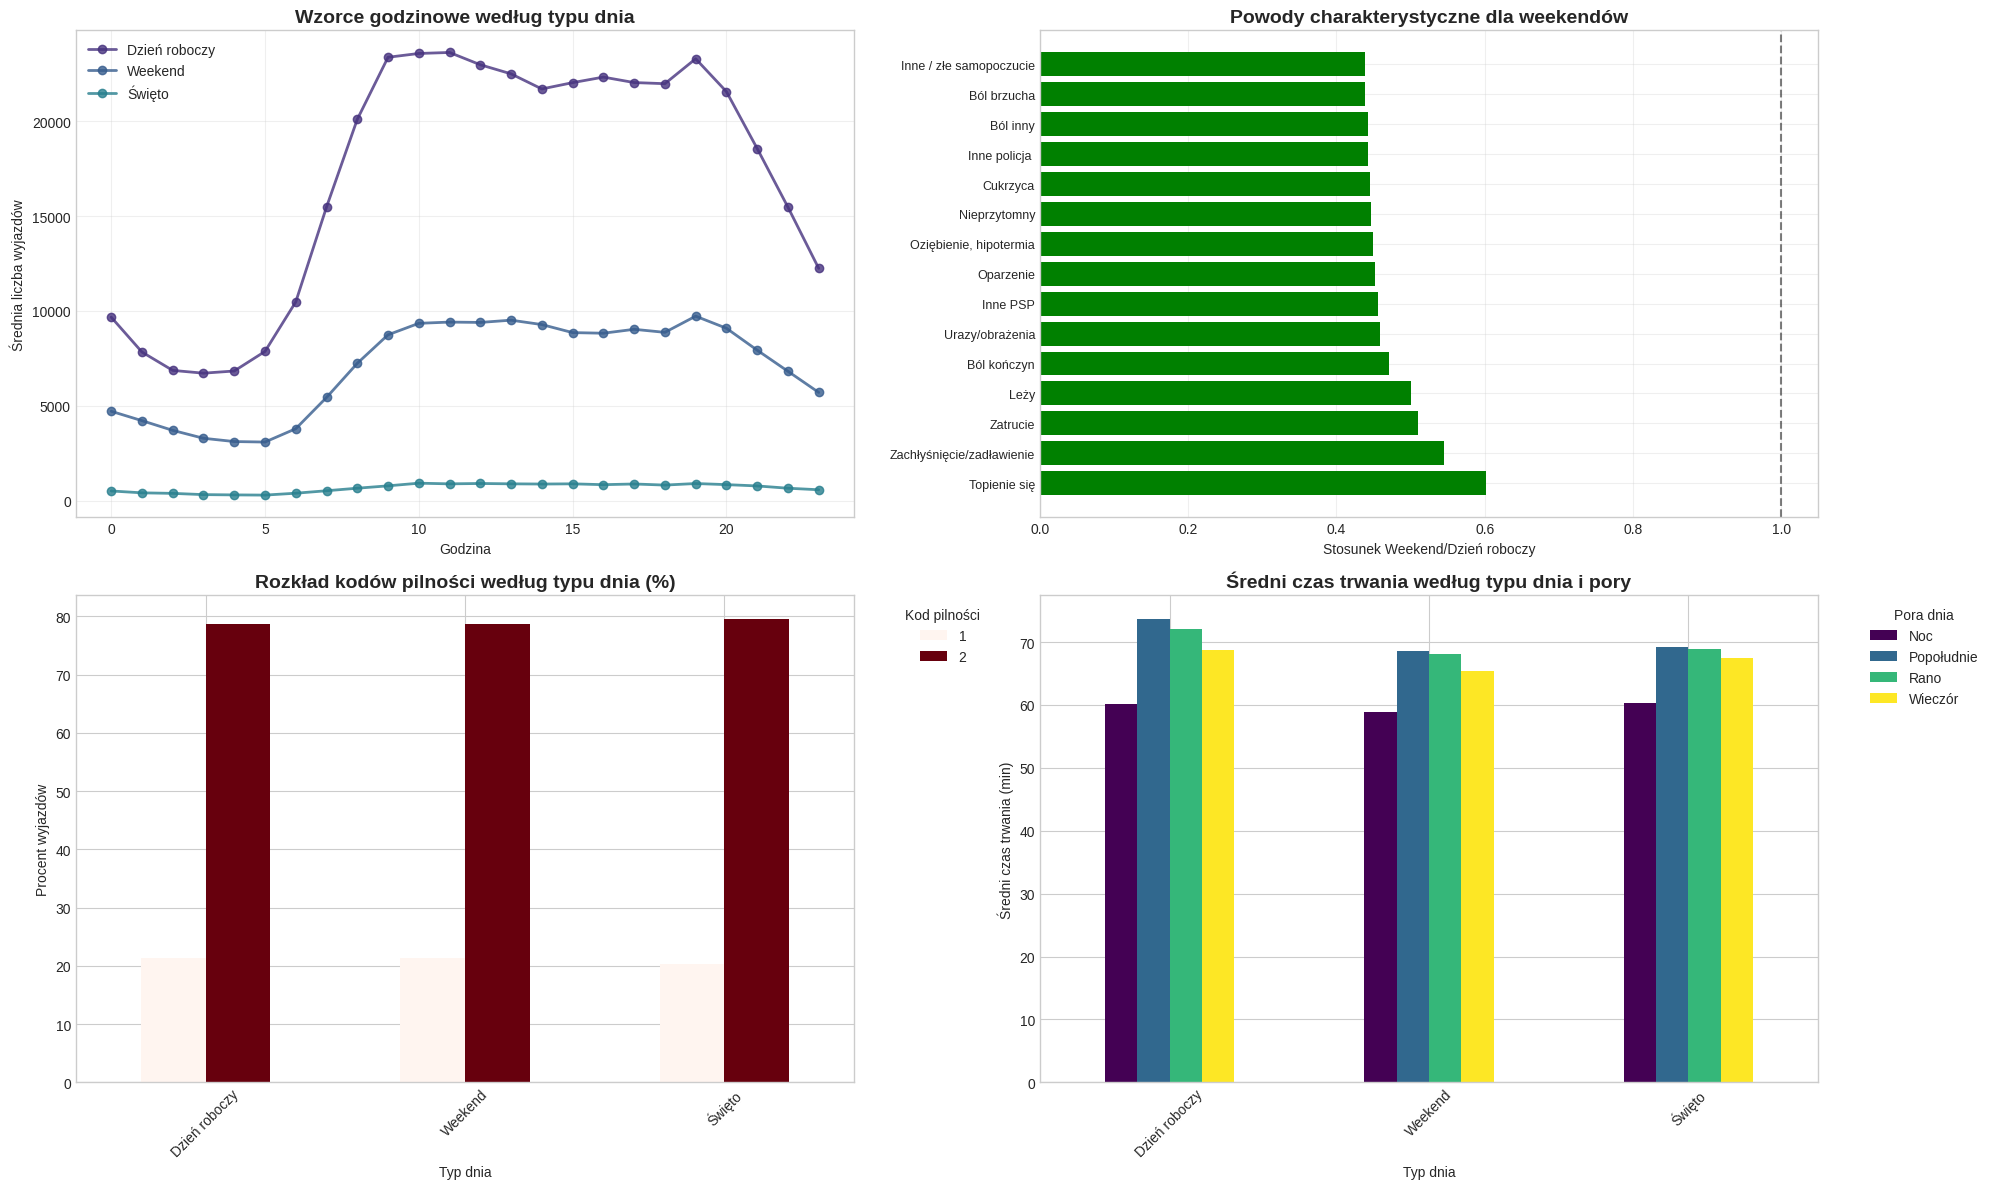

PORÓWNANIE TYPÓW DNI:
               wyjazd_id  Czas trwania (min)  Kod pilności  Rodzaj wyjazdu
day_category                                                              
Dzień roboczy     409079              69.783           1.0           0.467
Weekend           169066              65.809           1.0           0.442
Święto             16110              66.858           1.0           0.431


In [23]:
# =============================================================================
# SEKCJA 15: ANALIZA EFEKTÓW WEEKENDOWYCH I ŚWIĄTECZNYCH
# =============================================================================
print("\n=== SEKCJA 15: EFEKTY WEEKENDOWE I ŚWIĄTECZNE ===")

# 34. Głęboka analiza różnic między dniami roboczymi, weekendami i świętami
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

# Kategoryzacja dni
gdf['is_holiday'] = gdf['Data'].isin(pd.to_datetime(['2021-01-01', '2021-01-06', '2021-05-01', 
                                                    '2021-05-03', '2021-08-15', '2021-11-01', 
                                                    '2021-11-11', '2021-12-25', '2021-12-26',
                                                    '2022-01-01', '2022-01-06', '2022-05-01', 
                                                    '2022-05-03', '2022-08-15', '2022-11-01', 
                                                    '2022-11-11', '2022-12-25', '2022-12-26',
                                                    '2023-01-01', '2023-01-06', '2023-05-01', 
                                                    '2023-05-03', '2023-08-15', '2023-11-01', 
                                                    '2023-11-11', '2023-12-25', '2023-12-26']).date)

gdf['day_category'] = 'Dzień roboczy'
gdf.loc[gdf['Dzień tygodnia'].isin([5, 6]), 'day_category'] = 'Weekend'
gdf.loc[gdf['is_holiday'], 'day_category'] = 'Święto'

# 1. Porównanie rozkładów godzinowych
for day_type in ['Dzień roboczy', 'Weekend', 'Święto']:
    if day_type in gdf['day_category'].values:
        hourly_data = gdf[gdf['day_category'] == day_type].groupby('Godzina wyjazdu').size()
        ax1.plot(hourly_data.index, hourly_data.values, marker='o', linewidth=2, 
                label=day_type, alpha=0.8)

ax1.set_title('Wzorce godzinowe według typu dnia', fontsize=14, fontweight='bold')
ax1.set_xlabel('Godzina')
ax1.set_ylabel('Średnia liczba wyjazdów')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Analiza powodów wezwań według typu dnia
day_reason_cross = pd.crosstab(gdf['day_category'], gdf['Powód wezwania'])
top_reasons_weekend = day_reason_cross.loc['Weekend'].nlargest(10)
top_reasons_workday = day_reason_cross.loc['Dzień roboczy'].nlargest(10)

# Znajdź powody charakterystyczne dla weekendu
weekend_ratio = (day_reason_cross.loc['Weekend'] / day_reason_cross.loc['Dzień roboczy']).fillna(0)
weekend_specific = weekend_ratio.nlargest(15)

y_pos = np.arange(len(weekend_specific))
bars2 = ax2.barh(y_pos, weekend_specific.values, 
                color=['red' if x > 2 else 'orange' if x > 1.5 else 'green' for x in weekend_specific.values])
ax2.set_yticks(y_pos)
ax2.set_yticklabels([reason[:40] + '...' if len(reason) > 40 else reason 
                    for reason in weekend_specific.index], fontsize=9)
ax2.set_xlabel('Stosunek Weekend/Dzień roboczy')
ax2.set_title('Powody charakterystyczne dla weekendów', fontsize=14, fontweight='bold')
ax2.axvline(x=1, color='black', linestyle='--', alpha=0.5)
ax2.grid(True, alpha=0.3)

# 3. Analiza kodów pilności według typu dnia
urgency_day_pivot = pd.crosstab(gdf['day_category'], gdf['Kod pilności'], normalize='index') * 100
urgency_day_pivot.plot(kind='bar', ax=ax3, colormap='Reds')
ax3.set_title('Rozkład kodów pilności według typu dnia (%)', fontsize=14, fontweight='bold')
ax3.set_xlabel('Typ dnia')
ax3.set_ylabel('Procent wyjazdów')
ax3.legend(title='Kod pilności', bbox_to_anchor=(1.05, 1), loc='upper left')
ax3.tick_params(axis='x', rotation=45)

# 4. Czas trwania według typu dnia i pory
time_duration_complex = gdf.groupby(['day_category', 'Pora dnia'])['Czas trwania (min)'].mean().unstack()
time_duration_complex.plot(kind='bar', ax=ax4, colormap='viridis')
ax4.set_title('Średni czas trwania według typu dnia i pory', fontsize=14, fontweight='bold')
ax4.set_xlabel('Typ dnia')
ax4.set_ylabel('Średni czas trwania (min)')
ax4.legend(title='Pora dnia', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Statystyki porównawcze
stats_by_day_type = gdf.groupby('day_category').agg({
    'wyjazd_id': 'count',
    'Czas trwania (min)': 'mean',
    'Kod pilności': lambda x: (x <= 2).mean(),
    'Rodzaj wyjazdu': lambda x: (x == 0).mean()
}).round(3)

print("PORÓWNANIE TYPÓW DNI:")
print(stats_by_day_type)


=== SEKCJA 13: WEEKENDY VS DNI ROBOCZE ===


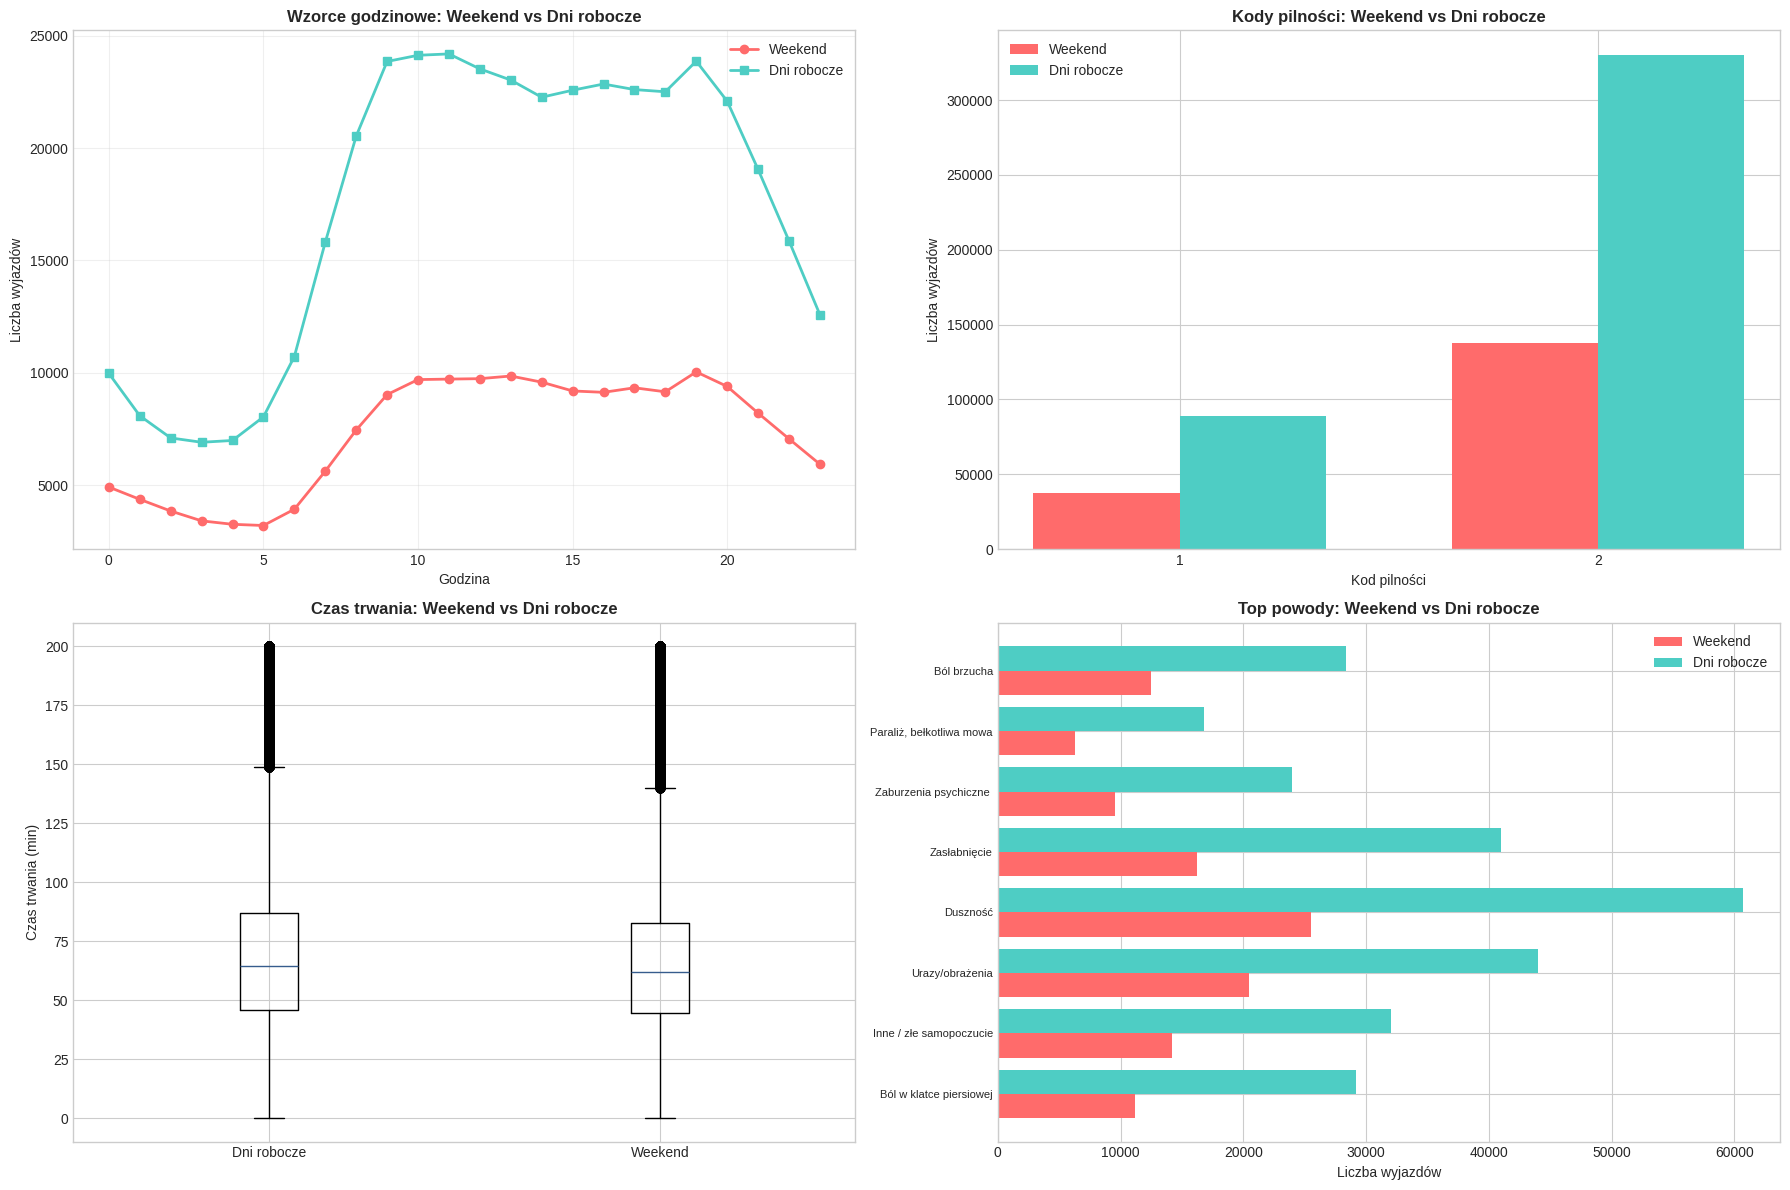

In [24]:
# =============================================================================
# SEKCJA 13: ANALIZA WZORCÓW WEEKENDOWYCH VS ROBOCZYCH
# =============================================================================
print("\n=== SEKCJA 13: WEEKENDY VS DNI ROBOCZE ===")

# Szczegółowa analiza różnic między dniami roboczymi a weekendami
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Porównanie wzorców godzinowych
weekend_data = gdf[gdf['Dzień tygodnia'] >= 5]
weekday_data = gdf[gdf['Dzień tygodnia'] < 5]

weekend_hourly = weekend_data['Godzina wyjazdu'].value_counts().sort_index()
weekday_hourly = weekday_data['Godzina wyjazdu'].value_counts().sort_index()

axes[0,0].plot(weekend_hourly.index, weekend_hourly.values, marker='o', 
               label='Weekend', linewidth=2, color='#FF6B6B')
axes[0,0].plot(weekday_hourly.index, weekday_hourly.values, marker='s', 
               label='Dni robocze', linewidth=2, color='#4ECDC4')
axes[0,0].set_title('Wzorce godzinowe: Weekend vs Dni robocze', fontweight='bold')
axes[0,0].set_xlabel('Godzina')
axes[0,0].set_ylabel('Liczba wyjazdów')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Porównanie kodów pilności
weekend_urgency = weekend_data['Kod pilności'].value_counts().sort_index()
weekday_urgency = weekday_data['Kod pilności'].value_counts().sort_index()

x = np.arange(len(weekend_urgency))
width = 0.35
axes[0,1].bar(x - width/2, weekend_urgency.values, width, label='Weekend', color='#FF6B6B')
axes[0,1].bar(x + width/2, weekday_urgency.values, width, label='Dni robocze', color='#4ECDC4')
axes[0,1].set_title('Kody pilności: Weekend vs Dni robocze', fontweight='bold')
axes[0,1].set_xlabel('Kod pilności')
axes[0,1].set_ylabel('Liczba wyjazdów')
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(weekend_urgency.index)
axes[0,1].legend()

# Porównanie czasów trwania
axes[1,0].boxplot([weekday_data['Czas trwania (min)'].clip(upper=200), 
                   weekend_data['Czas trwania (min)'].clip(upper=200)],
                  labels=['Dni robocze', 'Weekend'])
axes[1,0].set_title('Czas trwania: Weekend vs Dni robocze', fontweight='bold')
axes[1,0].set_ylabel('Czas trwania (min)')

# Top powody w weekendy vs dni robocze
weekend_reasons = weekend_data['Powód wezwania'].value_counts().head(10)
weekday_reasons = weekday_data['Powód wezwania'].value_counts().head(10)

# Znajdź wspólne powody
common_reasons = set(weekend_reasons.index) & set(weekday_reasons.index)
common_reasons = list(common_reasons)[:8]

weekend_common = [weekend_reasons.get(reason, 0) for reason in common_reasons]
weekday_common = [weekday_reasons.get(reason, 0) for reason in common_reasons]

y_pos = np.arange(len(common_reasons))
axes[1,1].barh(y_pos - 0.2, weekend_common, 0.4, label='Weekend', color='#FF6B6B')
axes[1,1].barh(y_pos + 0.2, weekday_common, 0.4, label='Dni robocze', color='#4ECDC4')
axes[1,1].set_yticks(y_pos)
axes[1,1].set_yticklabels([reason[:30] + '...' if len(reason) > 30 else reason 
                          for reason in common_reasons], fontsize=8)
axes[1,1].set_title('Top powody: Weekend vs Dni robocze', fontweight='bold')
axes[1,1].set_xlabel('Liczba wyjazdów')
axes[1,1].legend()

plt.tight_layout()
plt.show()


=== SEKCJA 14: ANALIZA SEZONOWA ===


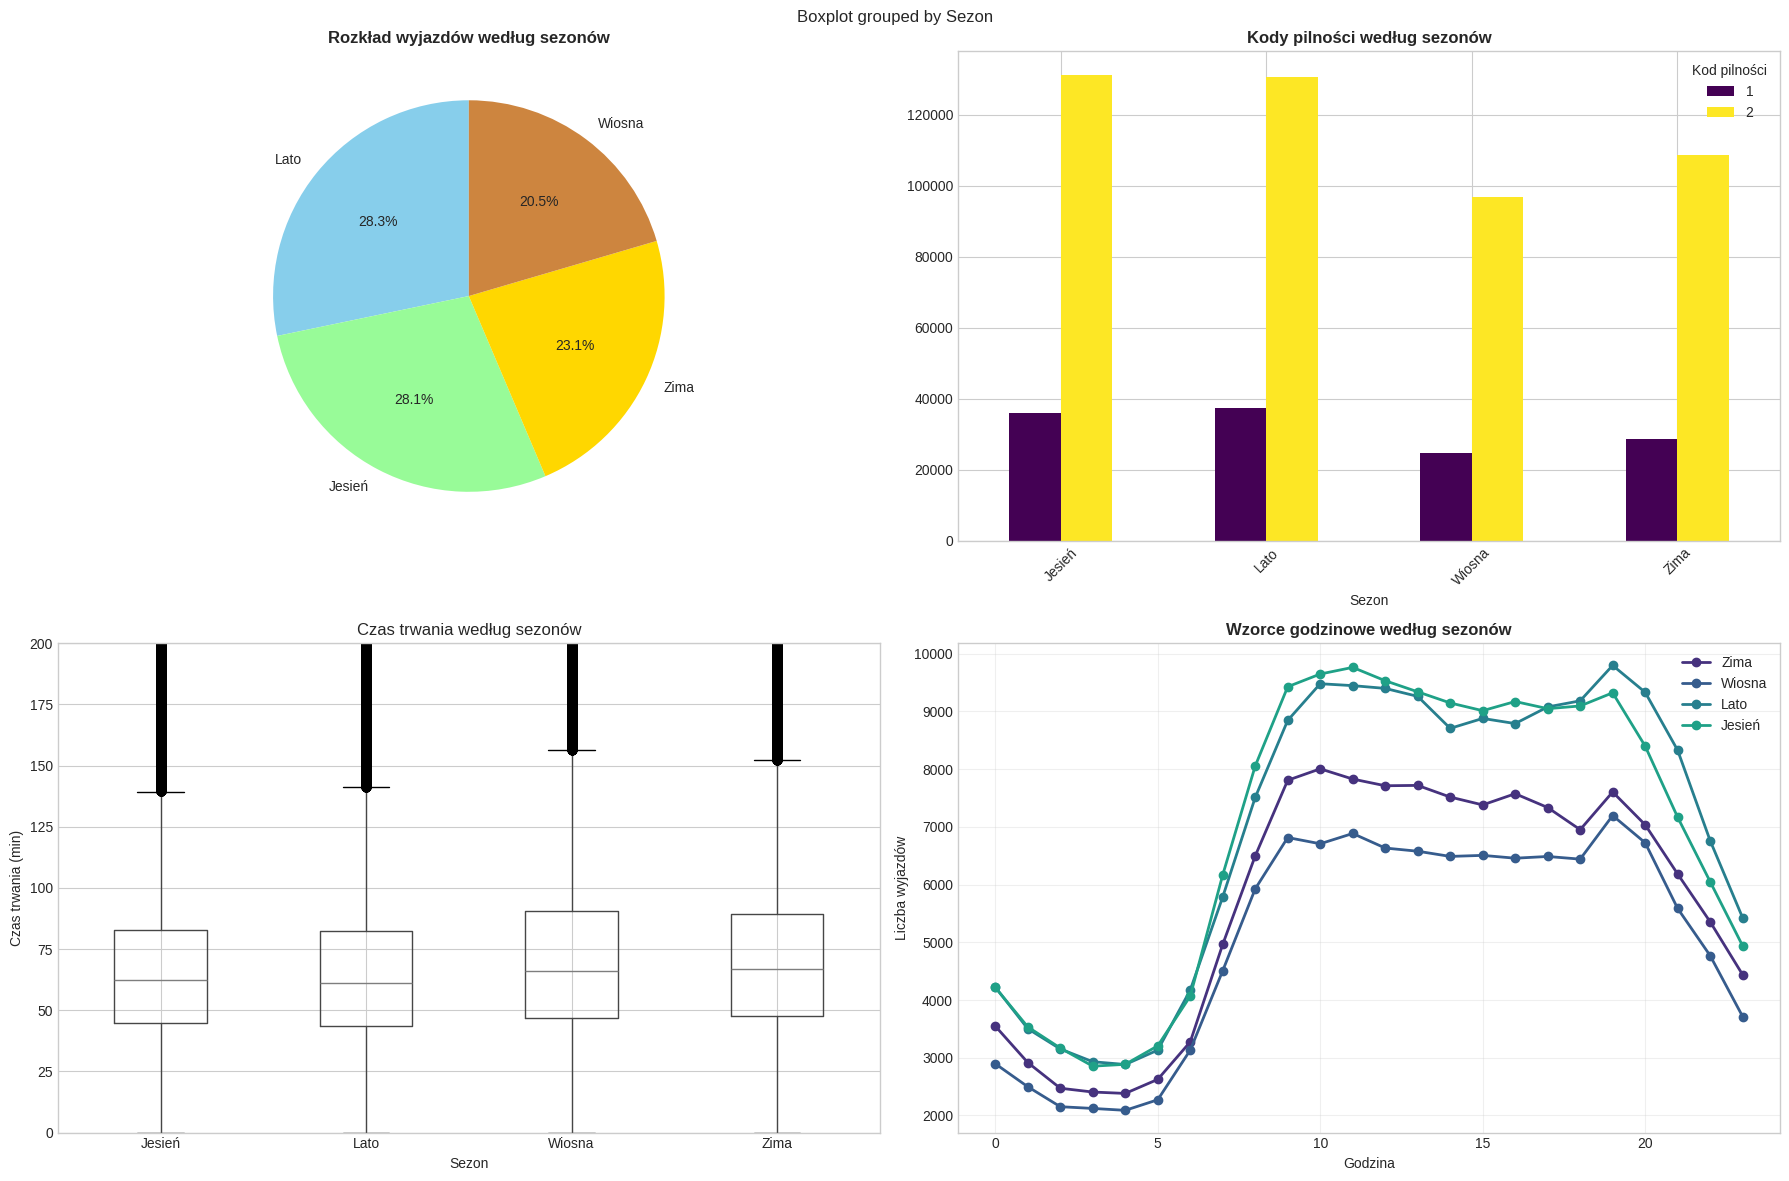

In [25]:
# =============================================================================
# SEKCJA 14: ANALIZA SEZONOWA I MIESIĘCZNA
# =============================================================================
print("\n=== SEKCJA 14: ANALIZA SEZONOWA ===")

# Definicja sezonów
def get_season(month):
    if month in [12, 1, 2]:
        return 'Zima'
    elif month in [3, 4, 5]:
        return 'Wiosna'
    elif month in [6, 7, 8]:
        return 'Lato'
    else:
        return 'Jesień'

gdf['Sezon'] = gdf['Miesiąc'].apply(get_season)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Rozkład sezonowy
season_counts = gdf['Sezon'].value_counts()
colors = ['#87CEEB', '#98FB98', '#FFD700', '#CD853F']
wedges, texts, autotexts = axes[0,0].pie(season_counts.values, labels=season_counts.index, 
                                        autopct='%1.1f%%', colors=colors, startangle=90)
axes[0,0].set_title('Rozkład wyjazdów według sezonów', fontweight='bold')

# Kody pilności według sezonów
season_urgency = pd.crosstab(gdf['Sezon'], gdf['Kod pilności'])
season_urgency.plot(kind='bar', ax=axes[0,1], colormap='viridis')
axes[0,1].set_title('Kody pilności według sezonów', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].legend(title='Kod pilności')

# Czas trwania według sezonów
gdf.boxplot(column='Czas trwania (min)', by='Sezon', ax=axes[1,0])
axes[1,0].set_title('Czas trwania według sezonów')
axes[1,0].set_xlabel('Sezon')
axes[1,0].set_ylabel('Czas trwania (min)')
axes[1,0].set_ylim(0, 200)

# Wzorce godzinowe według sezonów
for season in ['Zima', 'Wiosna', 'Lato', 'Jesień']:
    season_data = gdf[gdf['Sezon'] == season]
    hourly_pattern = season_data['Godzina wyjazdu'].value_counts().sort_index()
    axes[1,1].plot(hourly_pattern.index, hourly_pattern.values, 
                   marker='o', label=season, linewidth=2)

axes[1,1].set_title('Wzorce godzinowe według sezonów', fontweight='bold')
axes[1,1].set_xlabel('Godzina')
axes[1,1].set_ylabel('Liczba wyjazdów')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


=== SEKCJA 15: ANALIZA WIEKU PACJENTÓW ===


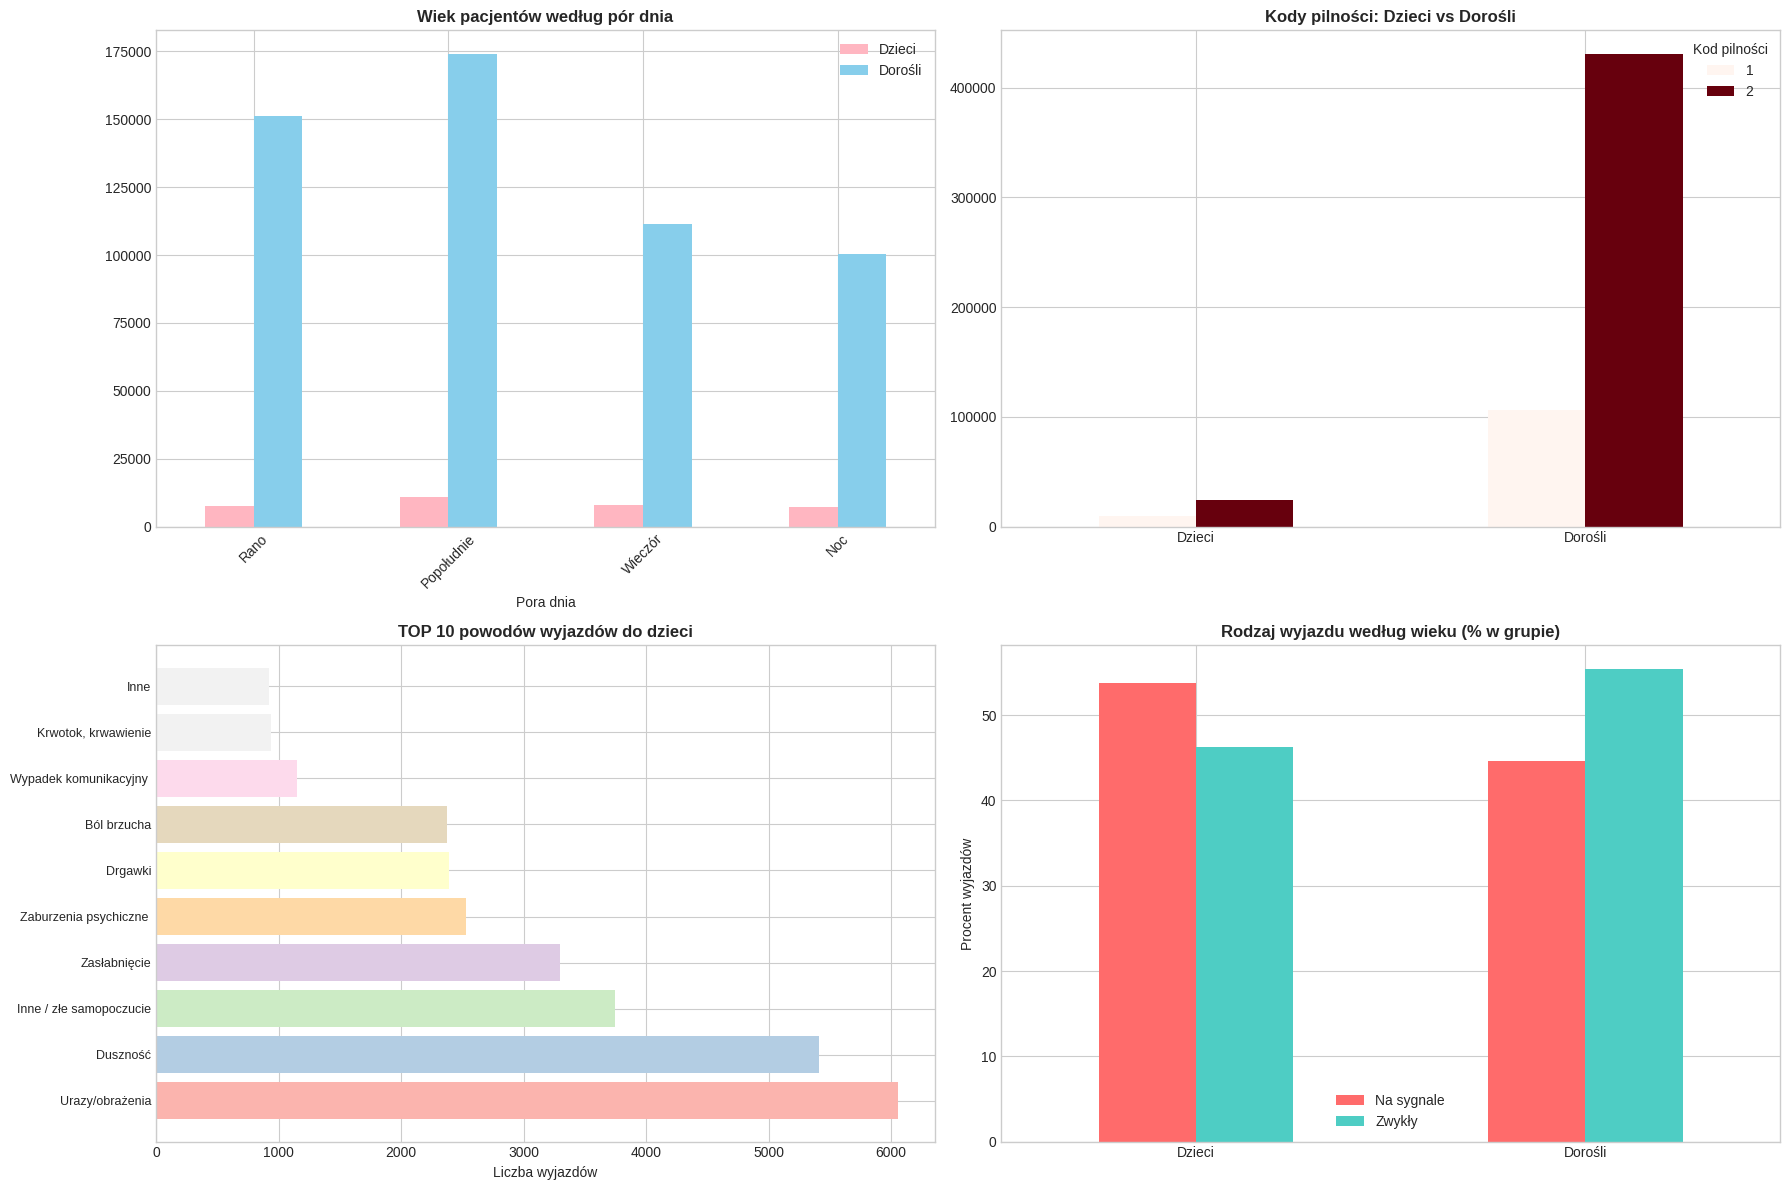

In [26]:
# =============================================================================
# SEKCJA 15: ANALIZA WIEKU PACJENTÓW I SPECYFIKI WYJAZDÓW
# =============================================================================
print("\n=== SEKCJA 15: ANALIZA WIEKU PACJENTÓW ===")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Rozkład wieku pacjentów według pór dnia
age_time_cross = pd.crosstab(gdf['Pora dnia'], gdf['Określenie wieku pacjenta'])
age_time_cross.columns = ['Dzieci', 'Dorośli']
age_time_cross = age_time_cross.reindex(['Rano', 'Popołudnie', 'Wieczór', 'Noc'])
age_time_cross.plot(kind='bar', ax=axes[0,0], color=['#FFB6C1', '#87CEEB'])
axes[0,0].set_title('Wiek pacjentów według pór dnia', fontweight='bold')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].legend()

# Kody pilności dla dzieci vs dorośli
age_urgency = pd.crosstab(gdf['Określenie wieku pacjenta'], gdf['Kod pilności'])
age_urgency.index = ['Dzieci', 'Dorośli']
age_urgency.plot(kind='bar', ax=axes[0,1], colormap='Reds')
axes[0,1].set_title('Kody pilności: Dzieci vs Dorośli', fontweight='bold')
axes[0,1].tick_params(axis='x', rotation=0)
axes[0,1].legend(title='Kod pilności')

# Top powody dla dzieci
children_data = gdf[gdf['Określenie wieku pacjenta'] == 0]
children_reasons = children_data['Powód wezwania'].value_counts().head(10)
bars = axes[1,0].barh(range(len(children_reasons)), children_reasons.values,
                      color=plt.cm.Pastel1(np.arange(len(children_reasons))))
axes[1,0].set_yticks(range(len(children_reasons)))
axes[1,0].set_yticklabels([reason[:40] + '...' if len(reason) > 40 else reason 
                          for reason in children_reasons.index], fontsize=9)
axes[1,0].set_title('TOP 10 powodów wyjazdów do dzieci', fontweight='bold')
axes[1,0].set_xlabel('Liczba wyjazdów')

# Rodzaj wyjazdu vs wiek pacjenta
age_trip_type = pd.crosstab(gdf['Określenie wieku pacjenta'], gdf['Rodzaj wyjazdu'])
age_trip_type.index = ['Dzieci', 'Dorośli']
age_trip_type.columns = ['Na sygnale', 'Zwykły']
age_trip_type_pct = age_trip_type.div(age_trip_type.sum(axis=1), axis=0) * 100

age_trip_type_pct.plot(kind='bar', ax=axes[1,1], color=['#FF6B6B', '#4ECDC4'])
axes[1,1].set_title('Rodzaj wyjazdu według wieku (% w grupie)', fontweight='bold')
axes[1,1].set_ylabel('Procent wyjazdów')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend()

plt.tight_layout()
plt.show()


=== SEKCJA 18: WZORCE MIESIĘCZNE I ŚWIĘTA ===


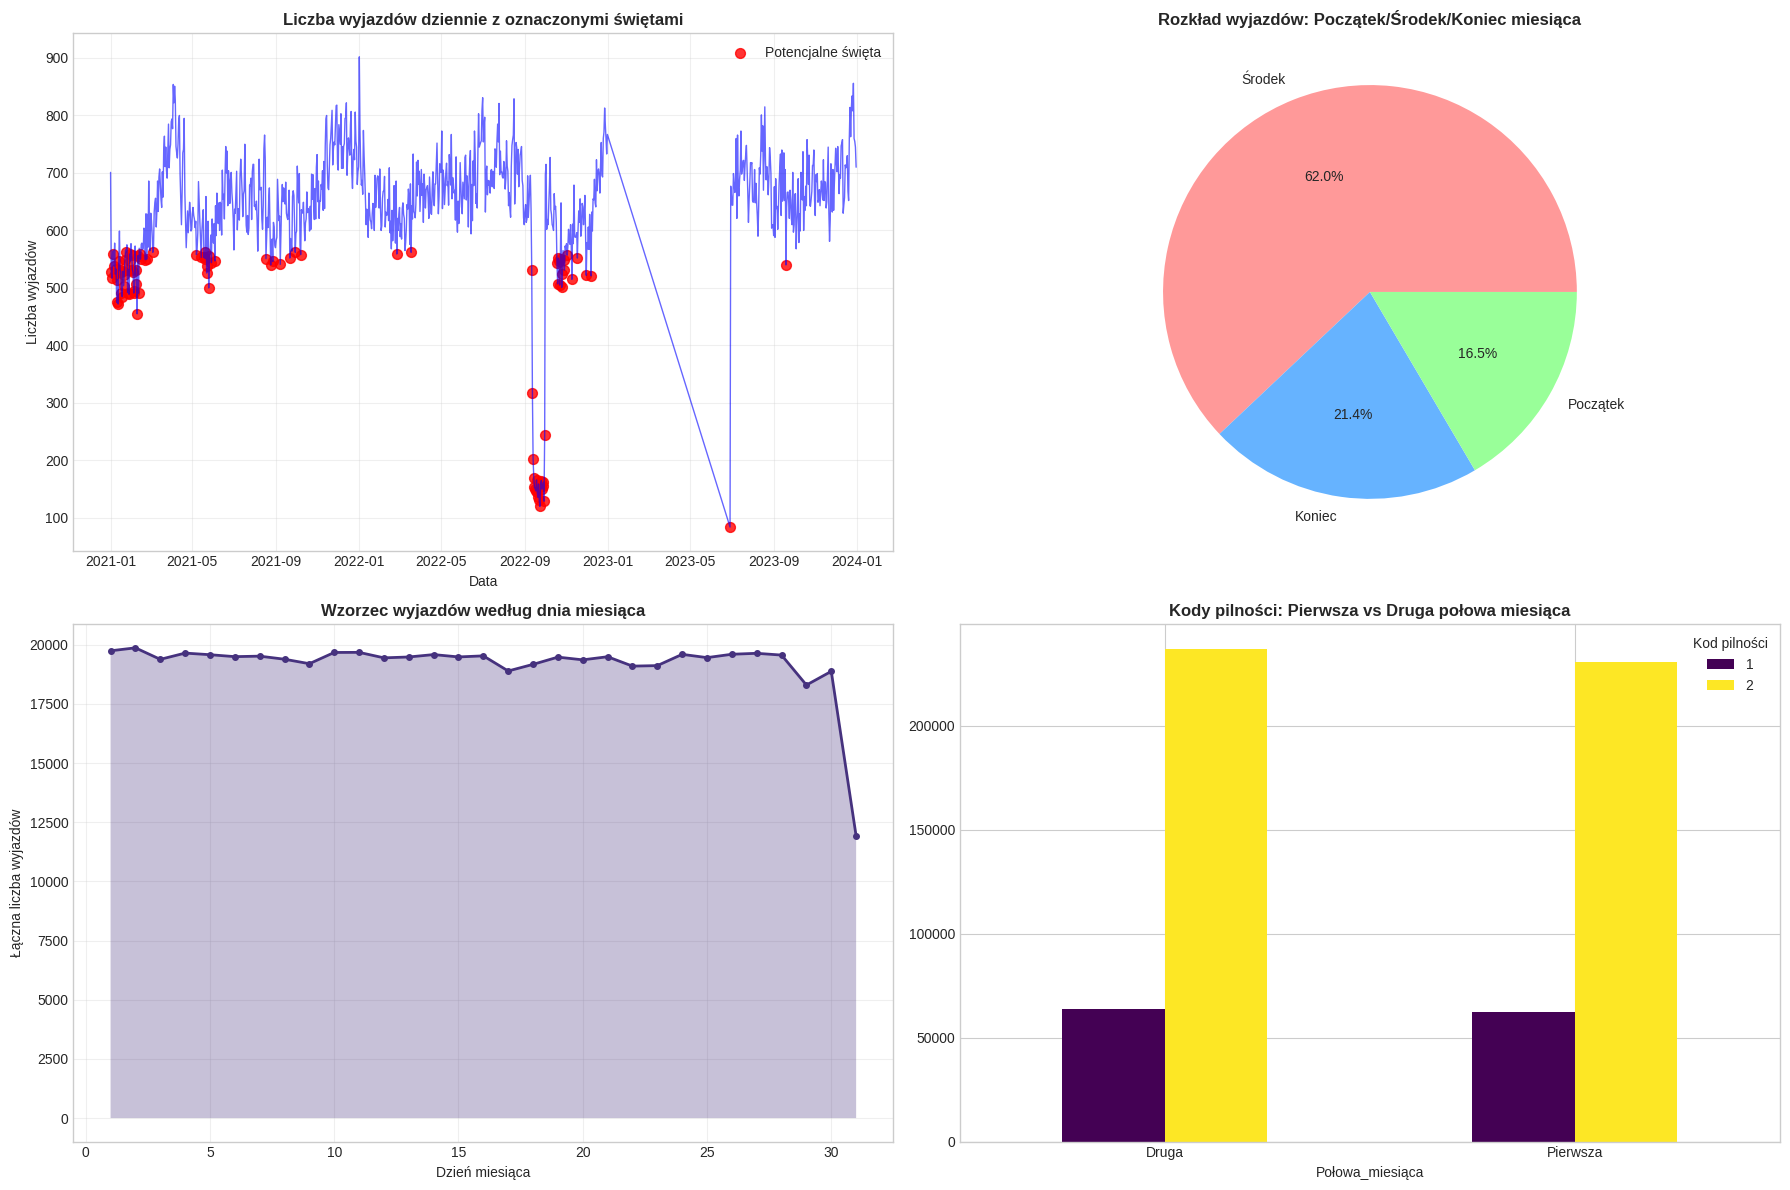

In [27]:
# =============================================================================
# SEKCJA 18: ANALIZA WZORCÓW MIESIĘCZNYCH I ŚWIĄTECZNYCH
# =============================================================================
print("\n=== SEKCJA 18: WZORCE MIESIĘCZNE I ŚWIĘTA ===")

# Identyfikacja potencjalnych świąt/dni specjalnych (dni z nietypowo małą liczbą wyjazdów)
daily_calls_count = gdf.groupby('Data').size().reset_index(name='count')
daily_calls_count['Data'] = pd.to_datetime(daily_calls_count['Data'])

# Znajdź dni z najmniejszą liczbą wyjazdów (potencjalne święta)
holidays_threshold = daily_calls_count['count'].quantile(0.1)
potential_holidays = daily_calls_count[daily_calls_count['count'] <= holidays_threshold]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Wykres czasowy z oznaczonymi potencjalnymi świętami
axes[0,0].plot(daily_calls_count['Data'], daily_calls_count['count'], 
               alpha=0.6, color='blue', linewidth=1)
axes[0,0].scatter(potential_holidays['Data'], potential_holidays['count'], 
                  color='red', s=50, alpha=0.8, label='Potencjalne święta')
axes[0,0].set_title('Liczba wyjazdów dziennie z oznaczonymi świętami', fontweight='bold')
axes[0,0].set_xlabel('Data')
axes[0,0].set_ylabel('Liczba wyjazdów')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Analiza końca/początku miesiąca
gdf['Koniec_miesiąca'] = gdf['Dzień miesiąca'].apply(lambda x: 'Koniec' if x >= 25 else 
                                                    ('Początek' if x <= 5 else 'Środek'))
month_part_counts = gdf['Koniec_miesiąca'].value_counts()
colors = ['#FF9999', '#66B3FF', '#99FF99']
axes[0,1].pie(month_part_counts.values, labels=month_part_counts.index, 
              autopct='%1.1f%%', colors=colors)
axes[0,1].set_title('Rozkład wyjazdów: Początek/Środek/Koniec miesiąca', fontweight='bold')

# Wzorce według dni miesiąca
day_of_month_pattern = gdf['Dzień miesiąca'].value_counts().sort_index()
axes[1,0].plot(day_of_month_pattern.index, day_of_month_pattern.values, 
               marker='o', linewidth=2, markersize=4)
axes[1,0].fill_between(day_of_month_pattern.index, day_of_month_pattern.values, alpha=0.3)
axes[1,0].set_title('Wzorzec wyjazdów według dnia miesiąca', fontweight='bold')
axes[1,0].set_xlabel('Dzień miesiąca')
axes[1,0].set_ylabel('Łączna liczba wyjazdów')
axes[1,0].grid(True, alpha=0.3)

# Porównanie pierwszej i drugiej połowy miesiąca
gdf['Połowa_miesiąca'] = gdf['Dzień miesiąca'].apply(lambda x: 'Pierwsza' if x <= 15 else 'Druga')
half_month_urgency = pd.crosstab(gdf['Połowa_miesiąca'], gdf['Kod pilności'])
half_month_urgency.plot(kind='bar', ax=axes[1,1], colormap='viridis')
axes[1,1].set_title('Kody pilności: Pierwsza vs Druga połowa miesiąca', fontweight='bold')
axes[1,1].tick_params(axis='x', rotation=0)
axes[1,1].legend(title='Kod pilności')

plt.tight_layout()
plt.show()

ANALIZA WYJAZDÓW KARETEK POGOTOWIA W WOJEWÓDZTWIE MAŁOPOLSKIM
UŻYWAM RZECZYWISTYCH DANYCH - BEZ GENEROWANIA LOSOWYCH WARTOŚCI
Ładuję dane wyjazdów karetek...
✓ Załadowano dane z: wynik_caly.parquet
✓ Załadowano 594255 rekordów
✓ Kolumny w danych: ['wyjazd_id', 'ID_GPS', 'Czas wyjazdu ZRM', 'Czas powrotu ZRM', 'Powód wezwania', 'Kod pilności', 'Rodzaj wyjazdu', 'Typ zespolu', 'Określenie wieku pacjenta', 'geometry']
✓ Znaleziono kolumnę 'Powód wezwania' - używam rzeczywistych danych
✓ Znaleziono kolumnę 'Kod pilności' - używam rzeczywistych danych
Rozpoczynam analizę danych karetek...
Wyciągam punkty startu wyjazdów...
Liczba punktów startu: 594255

Przykładowe powody wezwań z rzeczywistych danych:
Powód wezwania
Duszność                    86195
Urazy/obrażenia             64447
Zasłabnięcie                57147
Problemy kardiologiczne     49077
Inne / złe samopoczucie     46219
Ból brzucha                 40862
Ból w klatce piersiowej     40324
Zaburzenia psychiczne       33534
Parali

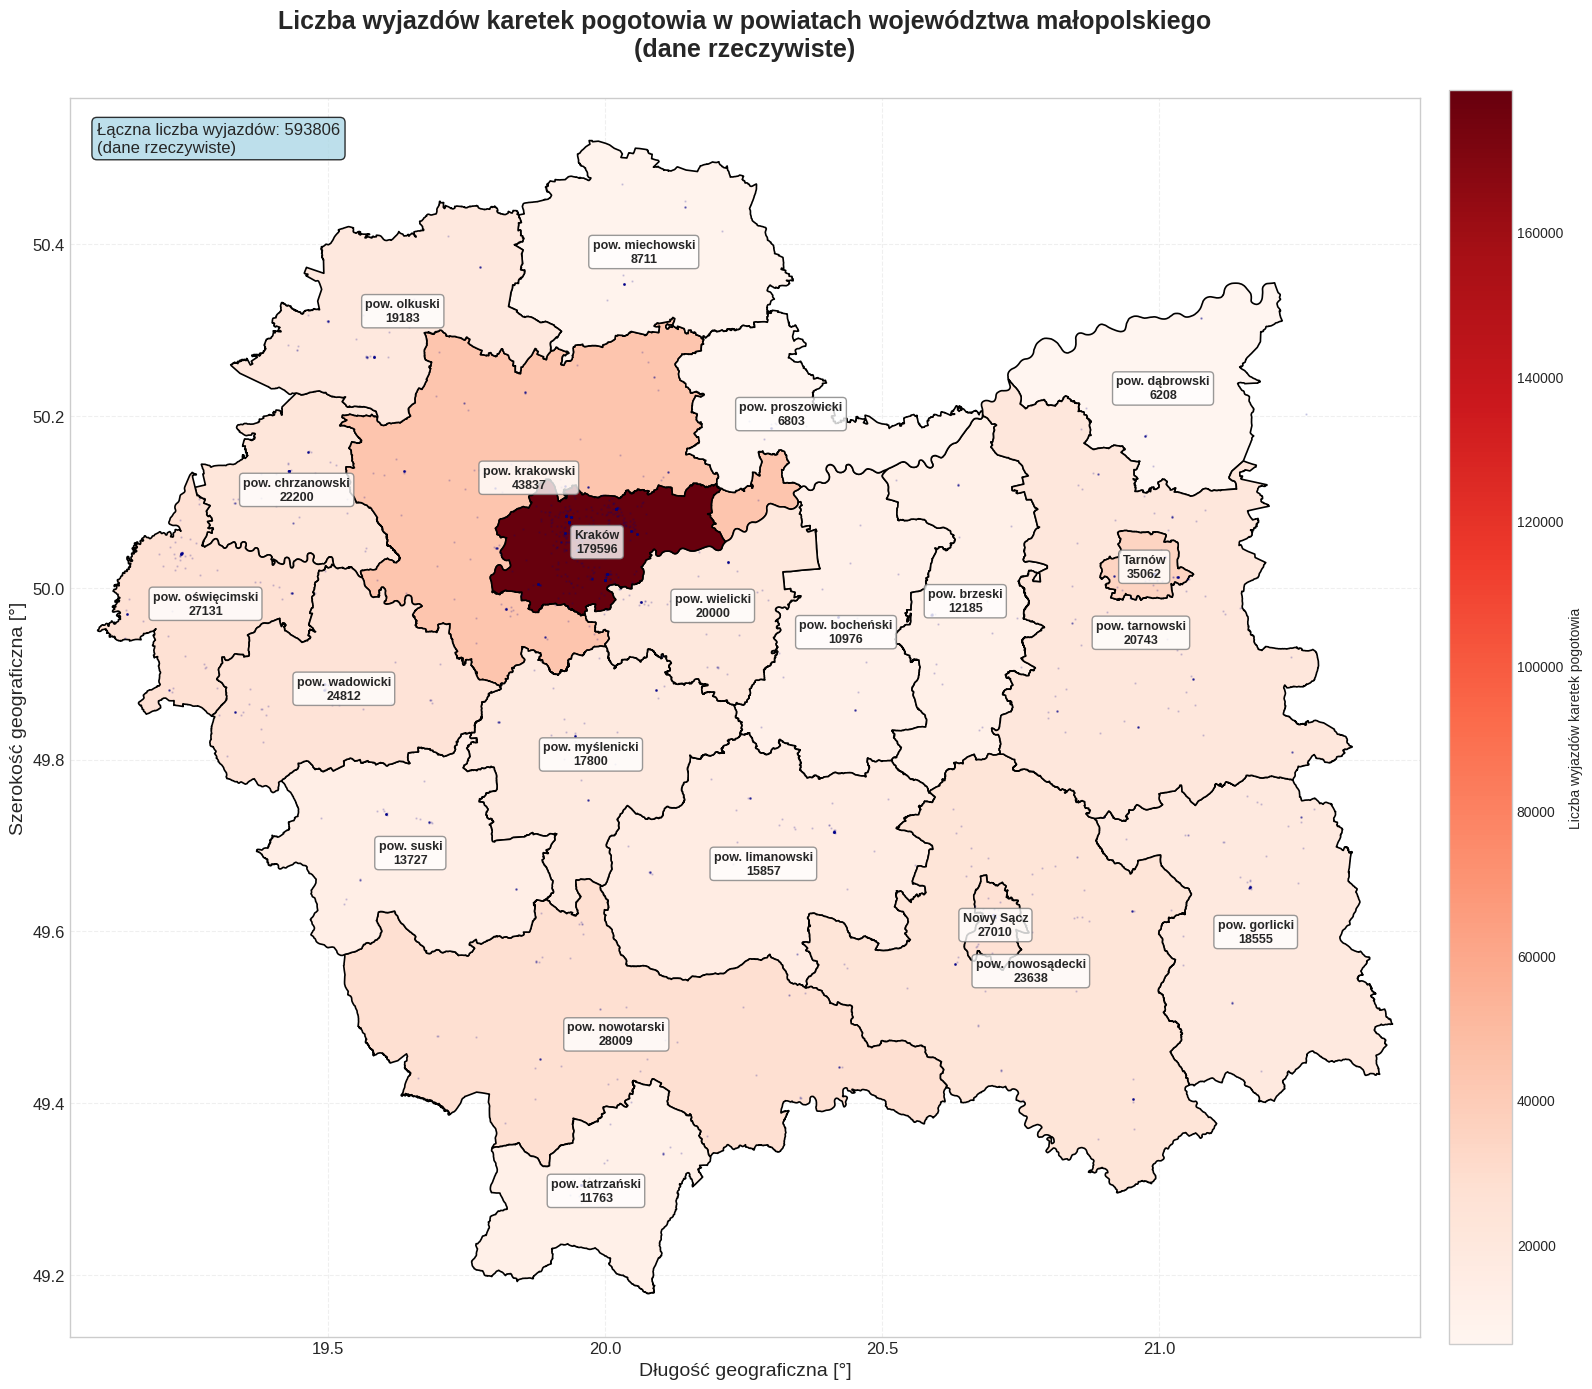


PODSUMOWANIE ANALIZY
✓ Przeanalizowane wyjazdy: 594,212
✓ Liczba powiatów: 22
✓ Całkowita liczba wyjazdów: 593,806
✓ Średnia wyjazdów na powiat: 26991.2
✓ Maksymalna liczba wyjazdów: 179596

RANKING POWIATÓW WEDŁUG LICZBY WYJAZDÓW KARETEK
 1. Kraków                    - 179596 wyjazdów
 2. powiat krakowski          -  43837 wyjazdów
 3. Tarnów                    -  35062 wyjazdów
 4. powiat nowotarski         -  28009 wyjazdów
 5. powiat oświęcimski        -  27131 wyjazdów
 6. Nowy Sącz                 -  27010 wyjazdów
 7. powiat wadowicki          -  24812 wyjazdów
 8. powiat nowosądecki        -  23638 wyjazdów
 9. powiat chrzanowski        -  22200 wyjazdów
10. powiat tarnowski          -  20743 wyjazdów
11. powiat wielicki           -  20000 wyjazdów
12. powiat olkuski            -  19183 wyjazdów
13. powiat gorlicki           -  18555 wyjazdów
14. powiat myślenicki         -  17800 wyjazdów
15. powiat limanowski         -  15857 wyjazdów
16. powiat suski              -  13727 w

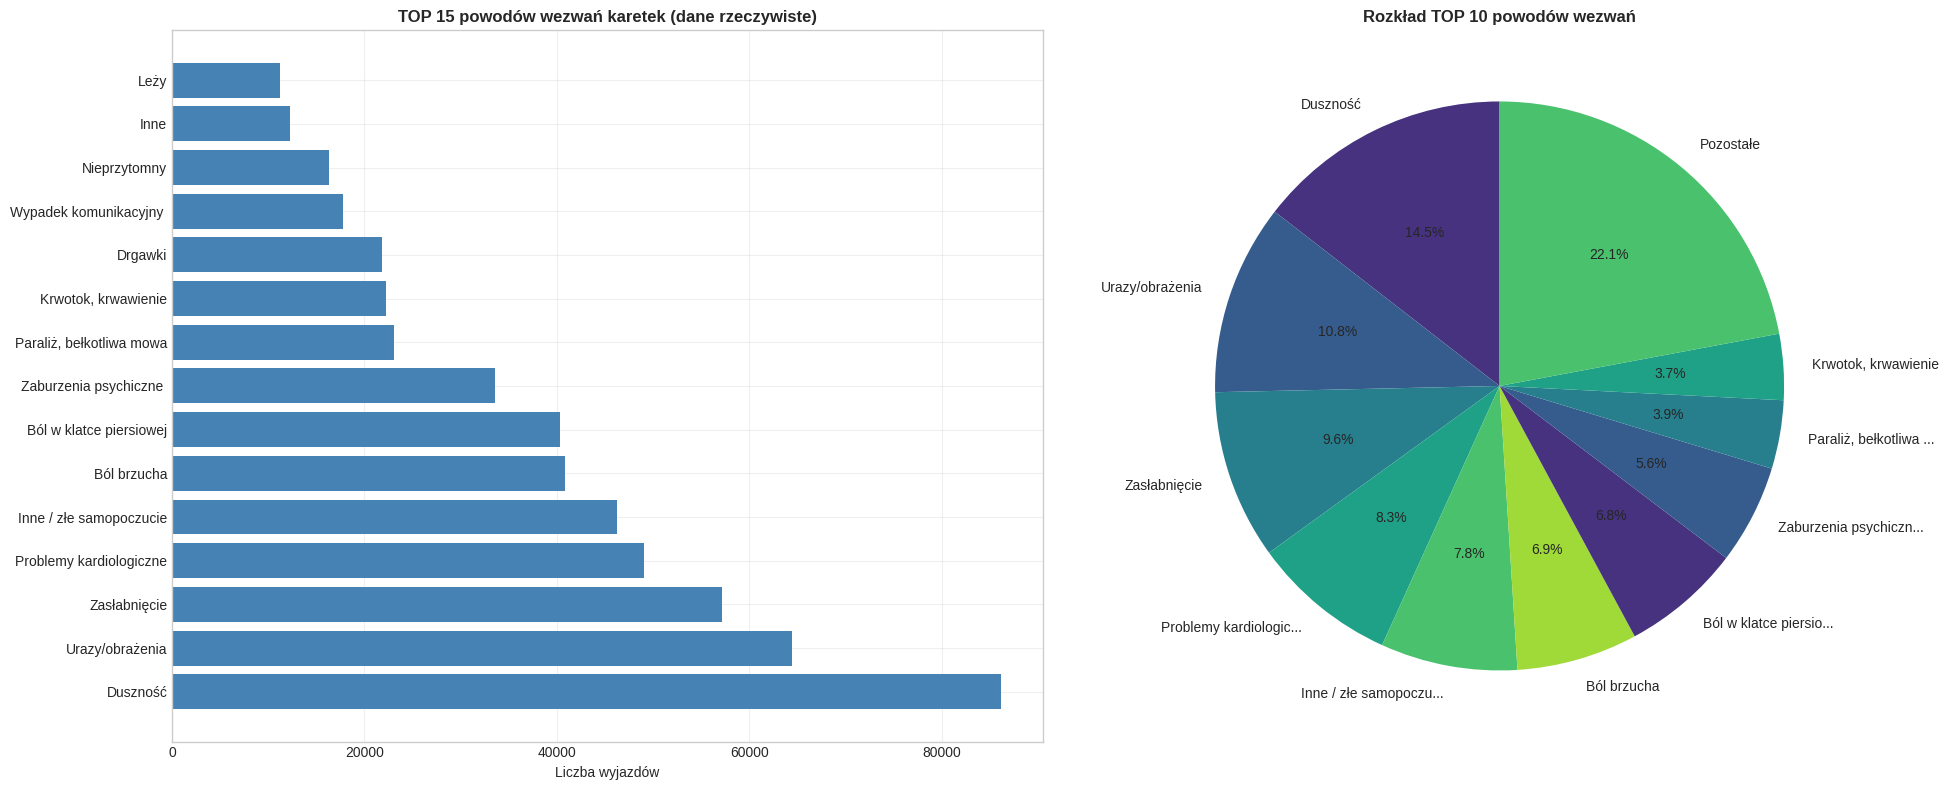


✓ ANALIZA ZAKOŃCZONA POMYŚLNIE - UŻYWANO RZECZYWISTYCH DANYCH


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

# Instalacja OSMnx jeśli nie jest zainstalowane
try:
    import osmnx as ox
except ImportError:
    print("Instaluję OSMnx...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'osmnx'])
    import osmnx as ox

# WAŻNE: Załaduj rzeczywiste dane na początku
def load_ambulance_data():
    """
    Ładuje rzeczywiste dane wyjazdów karetek
    """
    try:
        print("Ładuję dane wyjazdów karetek...")
        # Spróbuj załadować dane z różnych możliwych lokalizacji
        possible_files = [
            'wynik_caly.parquet',
            'ambulance_data.parquet',
            'dane_karetki.parquet'
        ]
        
        gdf = None
        for file_path in possible_files:
            try:
                gdf = gpd.read_parquet(file_path)
                print(f"✓ Załadowano dane z: {file_path}")
                break
            except FileNotFoundError:
                continue
            except Exception as e:
                print(f"Błąd ładowania {file_path}: {e}")
                continue
        
        if gdf is None:
            print("BŁĄD: Nie znaleziono pliku z danymi!")
            print("Sprawdź czy plik 'wynik_caly.parquet' istnieje w katalogu roboczym")
            return None
        
        print(f"✓ Załadowano {len(gdf)} rekordów")
        print(f"✓ Kolumny w danych: {list(gdf.columns)}")
        
        # Sprawdź czy dane zawierają wymagane kolumny
        required_columns = ['geometry']
        if 'Powód wezwania' in gdf.columns:
            print("✓ Znaleziono kolumnę 'Powód wezwania' - używam rzeczywistych danych")
        else:
            print("⚠ Brak kolumny 'Powód wezwania' - sprawdzam inne nazwy kolumn")
            # Sprawdź alternatywne nazwy kolumn
            possible_reason_columns = ['powod_wezwania', 'reason', 'call_reason', 'przyczyna']
            for col in possible_reason_columns:
                if col in gdf.columns:
                    gdf['Powód wezwania'] = gdf[col]
                    print(f"✓ Używam kolumny '{col}' jako 'Powód wezwania'")
                    break
        
        if 'Kod pilności' in gdf.columns:
            print("✓ Znaleziono kolumnę 'Kod pilności' - używam rzeczywistych danych")
        else:
            print("⚠ Brak kolumny 'Kod pilności' - sprawdzam inne nazwy kolumn")
            possible_priority_columns = ['kod_pilnosci', 'priority', 'priority_code', 'pilnosc']
            for col in possible_priority_columns:
                if col in gdf.columns:
                    gdf['Kod pilności'] = gdf[col]
                    print(f"✓ Używam kolumny '{col}' jako 'Kod pilności'")
                    break
        
        # Dodaj wyjazd_id jeśli nie istnieje
        if 'wyjazd_id' not in gdf.columns:
            gdf['wyjazd_id'] = range(len(gdf))
            print("✓ Dodano kolumnę wyjazd_id")
        
        return gdf
        
    except Exception as e:
        print(f"Błąd ładowania danych: {e}")
        return None

def get_malopolska_counties():
    """
    Pobiera granice powiatów województwa małopolskiego z OpenStreetMap
    """
    print("Pobieram granice powiatów Małopolski z OpenStreetMap...")
    try:
        # Lista powiatów w województwie małopolskim
        powiaty_names = [
            "powiat bocheński",
            "powiat brzeski", 
            "powiat chrzanowski",
            "powiat dąbrowski",
            "powiat gorlicki",
            "powiat krakowski",
            "powiat limanowski",
            "powiat miechowski",
            "powiat myślenicki",
            "powiat nowosądecki",
            "powiat nowotarski",
            "powiat olkuski",
            "powiat oświęcimski",
            "powiat proszowicki",
            "powiat suski",
            "powiat tarnowski",
            "powiat tatrzański",
            "powiat wadowicki",
            "powiat wielicki",
            "Kraków",
            "Tarnów", 
            "Nowy Sącz"
        ]
        
        counties_list = []
        for powiat_name in powiaty_names:
            try:
                print(f"Pobieram: {powiat_name}")
                search_queries = [
                    f"{powiat_name}, Małopolskie, Poland",
                    f"{powiat_name}, Poland",
                    powiat_name
                ]
                
                county_gdf = None
                for query in search_queries:
                    try:
                        county_gdf = ox.geocode_to_gdf(query, which_result=1)
                        if county_gdf is not None and not county_gdf.empty:
                            break
                    except:
                        continue
                
                if county_gdf is not None and not county_gdf.empty:
                    county_gdf['name'] = powiat_name
                    counties_list.append(county_gdf)
                    print(f"  ✓ Pobrano: {powiat_name}")
                else:
                    print(f"  ✗ Nie znaleziono: {powiat_name}")
                    
            except Exception as e:
                print(f"  ✗ Błąd dla {powiat_name}: {e}")
                continue
        
        if counties_list:
            counties_gdf = pd.concat(counties_list, ignore_index=True)
            counties_gdf = counties_gdf.to_crs('EPSG:4326')
            print(f"Pobrano {len(counties_gdf)} powiatów")
            return counties_gdf
        else:
            print("Nie udało się pobrać żadnych powiatów!")
            return None
            
    except Exception as e:
        print(f"Błąd pobierania danych: {e}")
        return None

def create_sample_counties_backup():
    """
    Backup - tworzy uproszczone granice powiatów
    """
    print("Używam backup - uproszczone granice powiatów...")
    
    counties_data = [
        {'name': 'Kraków', 'center': (19.9365, 50.0647), 'size': 0.15},
        {'name': 'powiat krakowski', 'center': (19.8, 50.0), 'size': 0.25},
        {'name': 'powiat wielicki', 'center': (20.2, 50.0), 'size': 0.2},
        {'name': 'powiat myślenicki', 'center': (19.9, 49.8), 'size': 0.2},
        {'name': 'powiat wadowicki', 'center': (19.5, 49.9), 'size': 0.2},
        {'name': 'powiat suski', 'center': (19.6, 49.7), 'size': 0.2},
        {'name': 'powiat chrzanowski', 'center': (19.4, 50.1), 'size': 0.2},
        {'name': 'powiat oświęcimski', 'center': (19.2, 50.0), 'size': 0.2},
        {'name': 'powiat brzeski', 'center': (20.6, 49.9), 'size': 0.2},
        {'name': 'powiat tarnowski', 'center': (20.9, 50.0), 'size': 0.25},
        {'name': 'Tarnów', 'center': (20.99, 50.01), 'size': 0.1},
        {'name': 'powiat bocheński', 'center': (20.4, 49.9), 'size': 0.2},
        {'name': 'powiat dąbrowski', 'center': (20.7, 50.3), 'size': 0.2},
        {'name': 'powiat proszowicki', 'center': (20.3, 50.2), 'size': 0.2},
        {'name': 'powiat miechowski', 'center': (20.0, 50.4), 'size': 0.2},
        {'name': 'powiat olkuski', 'center': (19.6, 50.3), 'size': 0.2},
        {'name': 'powiat nowosądecki', 'center': (20.7, 49.6), 'size': 0.3},
        {'name': 'Nowy Sącz', 'center': (20.71, 49.63), 'size': 0.1},
        {'name': 'powiat gorlicki', 'center': (21.2, 49.7), 'size': 0.2},
        {'name': 'powiat limanowski', 'center': (20.4, 49.7), 'size': 0.2},
        {'name': 'powiat nowotarski', 'center': (19.9, 49.5), 'size': 0.3},
        {'name': 'powiat tatrzański', 'center': (19.9, 49.3), 'size': 0.2}
    ]
    
    counties = []
    for county in counties_data:
        lon, lat = county['center']
        size = county['size']
        polygon = Polygon([
            (lon - size/2, lat - size/2),
            (lon + size/2, lat - size/2),
            (lon + size/2, lat + size/2),
            (lon - size/2, lat + size/2),
            (lon - size/2, lat - size/2)
        ])
        counties.append({
            'name': county['name'],
            'geometry': polygon
        })
    
    return gpd.GeoDataFrame(counties, crs='EPSG:4326')

def analyze_ambulance_data(gdf):
    """
    Analizuje dane wyjazdów karetek i tworzy mapę z podziałem na powiaty
    """
    print("Rozpoczynam analizę danych karetek...")
    
    # Wyciągnij punkty startu z geometrii LINESTRING
    print("Wyciągam punkty startu wyjazdów...")
    start_points = []
    valid_indices = []
    
    for idx, geom in gdf.geometry.items():
        try:
            if geom and hasattr(geom, 'coords') and len(geom.coords) > 0:
                start_point = Point(geom.coords[0])
                start_points.append(start_point)
                valid_indices.append(idx)
        except:
            continue
    
    if not start_points:
        print("Błąd: Nie udało się wyciągnąć punktów startu!")
        return None
    
    # Utwórz GeoDataFrame z punktami startu - UŻYWAJ RZECZYWISTYCH DANYCH
    columns_to_include = ['wyjazd_id']
    
    # Dodaj dostępne kolumny z rzeczywistych danych
    if 'Powód wezwania' in gdf.columns:
        columns_to_include.append('Powód wezwania')
    if 'Kod pilności' in gdf.columns:
        columns_to_include.append('Kod pilności')
    
    start_gdf = gpd.GeoDataFrame(
        gdf.loc[valid_indices][columns_to_include].copy(),
        geometry=start_points,
        crs=gdf.crs
    )
    
    print(f"Liczba punktów startu: {len(start_gdf)}")
    
    # Wyświetl przykładowe rzeczywiste dane
    if 'Powód wezwania' in start_gdf.columns:
        print("\nPrzykładowe powody wezwań z rzeczywistych danych:")
        print(start_gdf['Powód wezwania'].value_counts().head(10))
    
    if 'Kod pilności' in start_gdf.columns:
        print("\nRozkład kodów pilności z rzeczywistych danych:")
        print(start_gdf['Kod pilności'].value_counts())
    
    # Filtruj punkty w granicach Małopolski
    malopolska_bounds = {
        'min_lon': 19.0, 'max_lon': 21.5,
        'min_lat': 49.1, 'max_lat': 50.8
    }
    
    mask = (
        (start_gdf.geometry.x >= malopolska_bounds['min_lon']) &
        (start_gdf.geometry.x <= malopolska_bounds['max_lon']) &
        (start_gdf.geometry.y >= malopolska_bounds['min_lat']) &
        (start_gdf.geometry.y <= malopolska_bounds['max_lat'])
    )
    
    start_gdf_filtered = start_gdf[mask].copy()
    print(f"Punkty w granicach Małopolski: {len(start_gdf_filtered)}")
    
    if len(start_gdf_filtered) == 0:
        print("Brak punktów w granicach Małopolski!")
        return None
    
    # Pobierz granice powiatów
    counties_gdf = get_malopolska_counties()
    if counties_gdf is None:
        print("Próbuję z backup...")
        counties_gdf = create_sample_counties_backup()
    
    if counties_gdf is None or len(counties_gdf) == 0:
        print("Błąd: Nie udało się pobrać granic powiatów!")
        return None
    
    print(f"Liczba powiatów: {len(counties_gdf)}")
    
    # Upewnij się, że oba GeoDataFrame mają ten sam CRS
    if start_gdf_filtered.crs != counties_gdf.crs:
        start_gdf_filtered = start_gdf_filtered.to_crs(counties_gdf.crs)
    
    # Wykonaj spatial join
    print("Przypisuję wyjazdy do powiatów...")
    try:
        joined = gpd.sjoin(start_gdf_filtered, counties_gdf, how='left', predicate='within')
        
        # Policz wyjazdy dla każdego powiatu
        county_counts = joined.groupby('name').size().reset_index(name='liczba_wyjazdow')
        
        # Połącz z geometriami powiatów
        counties_with_counts = counties_gdf.merge(county_counts, on='name', how='left')
        counties_with_counts['liczba_wyjazdow'] = counties_with_counts['liczba_wyjazdow'].fillna(0)
        
        print("\nStatystyki wyjazdów według powiatów:")
        print("-" * 50)
        for _, row in counties_with_counts.sort_values('liczba_wyjazdow', ascending=False).iterrows():
            print(f"{row['name']:25}: {int(row['liczba_wyjazdow']):6} wyjazdów")
        
        # Analiza rzeczywistych powodów wezwań według powiatów
        if 'Powód wezwania' in joined.columns:
            print("\nAnaliza powodów wezwań według powiatów:")
            reasons_by_county = joined.groupby(['name', 'Powód wezwania']).size().unstack(fill_value=0)
            print(reasons_by_county.head())
        
        # Stwórz mapę
        print(f"\nTworzę mapę...")
        create_choropleth_map(counties_with_counts, start_gdf_filtered)
        
        return counties_with_counts, start_gdf_filtered, joined
        
    except Exception as e:
        print(f"Błąd podczas spatial join: {e}")
        return None

def create_choropleth_map(counties_gdf, points_gdf):
    """
    Tworzy mapę choropletową z liczbą wyjazdów według powiatów
    """
    fig, ax = plt.subplots(1, 1, figsize=(16, 16))
    
    max_count = counties_gdf['liczba_wyjazdow'].max()
    if max_count == 0:
        print("Brak danych do wizualizacji!")
        return
    
    print(f"Maksymalna liczba wyjazdów w powiecie: {int(max_count)}")
    
    # Ustaw paletę kolorów
    cmap = plt.cm.Reds
    norm = mcolors.Normalize(vmin=0, vmax=max_count)
    
    # Rysuj powiaty z kolorami według liczby wyjazdów
    counties_gdf.plot(
        column='liczba_wyjazdow',
        cmap=cmap,
        linewidth=1.2,
        ax=ax,
        edgecolor='black',
        legend=True,
        legend_kwds={
            'label': "Liczba wyjazdów karetek pogotowia",
            'orientation': "vertical",
            'shrink': 0.8,
            'pad': 0.02,
            'fraction': 0.05
        }
    )
    
    # Dodaj próbkę punktów wyjazdów dla wizualizacji
    if len(points_gdf) > 2000:
        sample_points = points_gdf.sample(n=2000, random_state=42)
        alpha = 0.15
        size = 0.5
    else:
        sample_points = points_gdf
        alpha = 0.3
        size = 1
    
    sample_points.plot(
        ax=ax,
        color='darkblue',
        alpha=alpha,
        markersize=size
    )
    
    # Dodaj etykiety powiatów z liczbami
    for idx, row in counties_gdf.iterrows():
        if row['geometry'] and not row['geometry'].is_empty and row['liczba_wyjazdow'] > 0:
            try:
                centroid = row['geometry'].centroid
                name_short = row['name'].replace('powiat ', 'pow. ')
                ax.annotate(
                    f"{name_short}\n{int(row['liczba_wyjazdow'])}",
                    xy=(centroid.x, centroid.y),
                    ha='center',
                    va='center',
                    fontsize=9,
                    fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='gray')
                )
            except:
                continue
    
    # Ustawienia mapy
    ax.set_title('Liczba wyjazdów karetek pogotowia w powiatach województwa małopolskiego\n(dane rzeczywiste)',
                fontsize=18, fontweight='bold', pad=30)
    ax.set_xlabel('Długość geograficzna [°]', fontsize=14)
    ax.set_ylabel('Szerokość geograficzna [°]', fontsize=14)
    
    # Dodaj siatkę współrzędnych
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.tick_params(axis='both', which='major', labelsize=12)
    
    # Dopasuj granice mapy
    bounds = counties_gdf.total_bounds
    margin = 0.05
    ax.set_xlim(bounds[0] - margin, bounds[2] + margin)
    ax.set_ylim(bounds[1] - margin, bounds[3] + margin)
    
    # Dodaj informacje
    total_trips = counties_gdf['liczba_wyjazdow'].sum()
    ax.text(0.02, 0.98, f'Łączna liczba wyjazdów: {int(total_trips)}\n(dane rzeczywiste)',
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def analyze_real_reasons(joined_gdf):
    """
    Analizuje rzeczywiste powody wezwań
    """
    if 'Powód wezwania' not in joined_gdf.columns:
        print("Brak danych o powodach wezwań")
        return
    
    print("\n" + "="*70)
    print("ANALIZA RZECZYWISTYCH POWODÓW WEZWAŃ")
    print("="*70)
    
    # Top 20 powodów wezwań
    reasons_count = joined_gdf['Powód wezwania'].value_counts()
    print("\nTOP 20 powodów wezwań:")
    print("-" * 50)
    for i, (reason, count) in enumerate(reasons_count.head(20).items(), 1):
        percentage = (count / len(joined_gdf)) * 100
        print(f"{i:2d}. {reason[:50]:50} - {count:6} ({percentage:5.1f}%)")
    
    # Wykres
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    
    # Top 15 powodów wezwań
    top_reasons = reasons_count.head(15)
    ax1.barh(range(len(top_reasons)), top_reasons.values, color='steelblue')
    ax1.set_yticks(range(len(top_reasons)))
    ax1.set_yticklabels([reason[:30] + '...' if len(reason) > 30 else reason 
                        for reason in top_reasons.index], fontsize=10)
    ax1.set_xlabel('Liczba wyjazdów')
    ax1.set_title('TOP 15 powodów wezwań karetek (dane rzeczywiste)', fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # Wykres kołowy dla top 10
    top_10 = reasons_count.head(10)
    other_sum = reasons_count.iloc[10:].sum()
    
    labels = list(top_10.index) + ['Pozostałe']
    sizes = list(top_10.values) + [other_sum]
    
    # Skróć etykiety dla wykresu kołowego
    short_labels = [label[:20] + '...' if len(label) > 20 else label for label in labels[:-1]] + ['Pozostałe']
    
    ax2.pie(sizes, labels=short_labels, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Rozkład TOP 10 powodów wezwań', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# GŁÓWNY KOD WYKONAWCZY
def main():
    print("="*70)
    print("ANALIZA WYJAZDÓW KARETEK POGOTOWIA W WOJEWÓDZTWIE MAŁOPOLSKIM")
    print("UŻYWAM RZECZYWISTYCH DANYCH - BEZ GENEROWANIA LOSOWYCH WARTOŚCI")
    print("="*70)
    
    # Załaduj rzeczywiste dane
    gdf = load_ambulance_data()
    
    if gdf is None:
        print("BŁĄD: Nie udało się załadować danych!")
        print("Sprawdź czy plik z danymi istnieje w katalogu roboczym")
        return
    
    # Wykonaj analizę
    results = analyze_ambulance_data(gdf)
    
    if results:
        counties_with_counts, filtered_points, joined_data = results
        
        print(f"\n" + "="*50)
        print("PODSUMOWANIE ANALIZY")
        print("="*50)
        print(f"✓ Przeanalizowane wyjazdy: {len(filtered_points):,}")
        print(f"✓ Liczba powiatów: {len(counties_with_counts)}")
        print(f"✓ Całkowita liczba wyjazdów: {int(counties_with_counts['liczba_wyjazdow'].sum()):,}")
        print(f"✓ Średnia wyjazdów na powiat: {counties_with_counts['liczba_wyjazdow'].mean():.1f}")
        print(f"✓ Maksymalna liczba wyjazdów: {int(counties_with_counts['liczba_wyjazdow'].max())}")
        
        # Ranking powiatów
        print("\n" + "="*60)
        print("RANKING POWIATÓW WEDŁUG LICZBY WYJAZDÓW KARETEK")
        print("="*60)
        ranking = counties_with_counts.sort_values('liczba_wyjazdow', ascending=False)
        for i, (_, row) in enumerate(ranking.iterrows(), 1):
            if row['liczba_wyjazdow'] > 0:
                print(f"{i:2d}. {row['name']:25} - {int(row['liczba_wyjazdow']):6} wyjazdów")
        
        # Analizuj rzeczywiste powody wezwań
        analyze_real_reasons(joined_data)
        
        print("\n✓ ANALIZA ZAKOŃCZONA POMYŚLNIE - UŻYWANO RZECZYWISTYCH DANYCH")
    else:
        print("BŁĄD: Analiza nie powiodła się")

# Uruchom analizę
if __name__ == "__main__":
    main()

In [116]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta

# Instalacja OSMnx jeśli nie jest zainstalowane
try:
    import osmnx as ox
except ImportError:
    print("Instaluję OSMnx...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'osmnx'])
    import osmnx as ox


def load_malopolska_counties():
    """
    Ładuje granice powiatów województwa małopolskiego
    """
    try:
        print("Pobieranie granic powiatów województwa małopolskiego...")
        
        # Pobierz granice administracyjne dla województwa małopolskiego
        # Możesz użyć różnych źródeł danych geograficznych
        
        # Opcja 1: Użyj OSMnx
        try:
            place_name = "Małopolskie, Poland"
            gdf_voivodeship = ox.geocode_to_gdf(place_name)
            
            # Pobierz powiaty
            counties = ox.geometries_from_place(place_name, tags={'admin_level': '6'})
            counties = counties[counties.geometry.type == 'Polygon']
            counties = counties.reset_index()
            
            print(f"✅ Pobrano {len(counties)} powiatów")
            return counties
            
        except Exception as e:
            print(f"⚠️ Błąd OSMnx: {e}")
            
            # Opcja 2: Stwórz przykładowe dane
            print("Tworzę przykładowe granice powiatów...")
            return create_sample_counties()
            
    except Exception as e:
        print(f"❌ Błąd podczas pobierania granic: {e}")
        return create_sample_counties()

def create_sample_counties():
    """
    Tworzy przykładowe granice powiatów dla demonstracji
    """
    # Współrzędne przybliżone dla głównych miast Małopolski
    sample_counties = [
        {"name": "powiat krakowski", "center_lat": 50.0647, "center_lon": 19.9450},
        {"name": "powiat tarnowski", "center_lat": 50.0121, "center_lon": 20.9876},
        {"name": "powiat nowosądecki", "center_lat": 49.6224, "center_lon": 20.7151},
        {"name": "powiat oświęcimski", "center_lat": 50.0347, "center_lon": 19.2317},
        {"name": "powiat chrzanowski", "center_lat": 50.1354, "center_lon": 19.4025},
        {"name": "powiat wielicki", "center_lat": 49.9688, "center_lon": 20.0631},
        {"name": "powiat bocheński", "center_lat": 49.9687, "center_lon": 20.4309},
        {"name": "powiat brzeski", "center_lat": 49.8906, "center_lon": 20.6119},
        {"name": "powiat dąbrowski", "center_lat": 50.0875, "center_lon": 20.7011},
        {"name": "powiat gorlicki", "center_lat": 49.6556, "center_lon": 21.1611},
        {"name": "powiat limanowski", "center_lat": 49.7045, "center_lon": 20.1270},
        {"name": "powiat miechowski", "center_lat": 50.3583, "center_lon": 20.0289},
        {"name": "powiat myślenicki", "center_lat": 49.8367, "center_lon": 19.9344},
        {"name": "powiat nowotarski", "center_lat": 49.4825, "center_lon": 19.9522},
        {"name": "powiat olkuski", "center_lat": 50.2833, "center_lon": 19.5667},
        {"name": "powiat proszowicki", "center_lat": 50.1833, "center_lon": 20.2833},
        {"name": "powiat suski", "center_lat": 49.7333, "center_lon": 19.6000},
        {"name": "powiat tatrzański", "center_lat": 49.3500, "center_lon": 19.9667},
        {"name": "powiat wadowicki", "center_lat": 49.8833, "center_lon": 19.5000}
    ]
    
    geometries = []
    names = []
    
    for county in sample_counties:
        # Stwórz prostokątne granice wokół centrum (około 0.2 stopnia)
        lat, lon = county["center_lat"], county["center_lon"]
        bbox = Polygon([
            (lon - 0.15, lat - 0.1),
            (lon + 0.15, lat - 0.1),
            (lon + 0.15, lat + 0.1),
            (lon - 0.15, lat + 0.1)
        ])
        geometries.append(bbox)
        names.append(county["name"])
    
    gdf = gpd.GeoDataFrame({'name': names}, geometry=geometries, crs='EPSG:4326')
    print(f"✅ Utworzono {len(gdf)} przykładowych powiatów")
    return gdf

def analyze_ambulance_data(gdf):
    """
    Główna funkcja analizy danych ambulansów
    """
    try:
        print("\n🔍 Rozpoczynam analizę danych...")
        
        # Załaduj granice powiatów
        counties = load_malopolska_counties()
        if counties is None:
            return None
        
        # Jeśli dane mają współrzędne geograficzne
        if hasattr(gdf, 'geometry') and not gdf.geometry.isna().all():
            print("Wykonuję spatial join...")
            
            # Upewnij się, że oba GeoDataFrame mają ten sam CRS
            if gdf.crs != counties.crs:
                gdf = gdf.to_crs(counties.crs)
            
            # Wykonaj spatial join
            joined = gpd.sjoin(gdf, counties, how='left', predicate='within')
            
            # Policz wyjazdy według powiatów
            county_counts = joined.groupby('name').size().reset_index(name='liczba_wyjazdow')
            
        else:
            print("Brak danych geograficznych - losowe przypisanie do powiatów dla demonstracji")
            
            # Losowo przypisz rekordy do powiatów dla demonstracji
            np.random.seed(42)
            county_names = counties['name'].tolist()
            gdf['name'] = np.random.choice(county_names, size=len(gdf))
            
            county_counts = gdf.groupby('name').size().reset_index(name='liczba_wyjazdow')
            joined = gdf.copy()
        
        # Połącz z granicami powiatów
        counties_with_counts = counties.merge(county_counts, on='name', how='left')
        counties_with_counts['liczba_wyjazdow'] = counties_with_counts['liczba_wyjazdow'].fillna(0)
        
        # Usuń powiaty bez wyjazdów z joined data
        filtered_joined = joined[joined['name'].notna()].copy()
        
        print(f"✅ Analiza zakończona. Przetworzono {len(filtered_joined)} wyjazdów w {len(county_counts)} powiatach")
        
        return counties_with_counts, gdf, filtered_joined
        
    except Exception as e:
        print(f"❌ Błąd podczas analizy: {e}")
        return None

def analyze_temporal_patterns(joined_gdf):
    """
    Analizuje wzorce czasowe wyjazdów w powiatach
    """
    print("\n" + "="*70)
    print("ANALIZA WZORCÓW CZASOWYCH WYJAZDÓW W POWIATACH")
    print("="*70)
    
    # Sprawdź czy są dane czasowe
    time_columns = [col for col in joined_gdf.columns if 'czas' in col.lower() or 'time' in col.lower() or 'data' in col.lower()]
    
    if not time_columns:
        print("Brak danych czasowych - generuję przykładowe dane")
        # Generuj przykładowe dane czasowe
        start_date = datetime(2023, 1, 1)
        end_date = datetime(2023, 12, 31)
        
        # Generuj losowe daty w zakresie
        time_range = end_date - start_date
        random_dates = [start_date + timedelta(seconds=np.random.randint(0, int(time_range.total_seconds()))) 
                       for _ in range(len(joined_gdf))]
        joined_gdf['datetime'] = random_dates
    else:
        time_col = time_columns[0]
        print(f"Używam kolumny czasowej: {time_col}")
        joined_gdf['datetime'] = pd.to_datetime(joined_gdf[time_col], errors='coerce')
        joined_gdf = joined_gdf.dropna(subset=['datetime'])
    
    if len(joined_gdf) == 0:
        print("Brak poprawnych danych czasowych")
        return
    
    # Dodaj kolumny czasowe
    joined_gdf['hour'] = joined_gdf['datetime'].dt.hour
    joined_gdf['day_of_week'] = joined_gdf['datetime'].dt.dayofweek
    joined_gdf['month'] = joined_gdf['datetime'].dt.month
    joined_gdf['day_name'] = joined_gdf['datetime'].dt.day_name()
    joined_gdf['month_name'] = joined_gdf['datetime'].dt.month_name()
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))
    
    # 1. Rozkład godzinowy w top 5 powiatach
    top_counties = joined_gdf['name'].value_counts().head(5).index
    hourly_data = []
    
    for county in top_counties:
        county_data = joined_gdf[joined_gdf['name'] == county]
        hourly_counts = county_data.groupby('hour').size()
        for hour in range(24):
            hourly_data.append({
                'Powiat': county.replace('powiat ', ''),
                'Godzina': hour,
                'Liczba_wyjazdow': hourly_counts.get(hour, 0)
            })
    
    hourly_df = pd.DataFrame(hourly_data)
    hourly_pivot = hourly_df.pivot(index='Godzina', columns='Powiat', values='Liczba_wyjazdow')
    
    hourly_pivot.plot(kind='line', ax=ax1, marker='o', linewidth=2)
    ax1.set_title('Rozkład wyjazdów w ciągu doby - TOP 5 powiatów', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Godzina')
    ax1.set_ylabel('Liczba wyjazdów')
    ax1.grid(True, alpha=0.3)
    ax1.legend(title='Powiat', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # 2. Rozkład tygodniowy
    weekly_county = joined_gdf.groupby(['name', 'day_name']).size().unstack(fill_value=0)
    # Uporządkuj dni tygodnia
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    existing_days = [day for day in day_order if day in weekly_county.columns]
    weekly_county = weekly_county.reindex(columns=existing_days)
    
    # Heatmapa dla top 10 powiatów
    top_10_weekly = weekly_county.loc[top_counties[:min(10, len(top_counties))]]
    
    sns.heatmap(top_10_weekly, annot=True, fmt='d', cmap='YlOrRd', ax=ax2)
    ax2.set_title('Rozkład wyjazdów w dniach tygodnia - TOP powiatów', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Dzień tygodnia')
    ax2.set_ylabel('Powiat')
    
    # 3. Miesięczny rozkład wyjazdów
    monthly_data = joined_gdf.groupby(['name', 'month_name']).size().unstack(fill_value=0)
    month_order = ['January', 'February', 'March', 'April', 'May', 'June',
                   'July', 'August', 'September', 'October', 'November', 'December']
    existing_months = [m for m in month_order if m in monthly_data.columns]
    monthly_data = monthly_data.reindex(columns=existing_months)
    
    # Suma dla wszystkich powiatów
    monthly_total = monthly_data.sum(axis=0)
    monthly_total.plot(kind='bar', ax=ax3, color='steelblue')
    ax3.set_title('Rozkład wyjazdów według miesięcy', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Miesiąc')
    ax3.set_ylabel('Liczba wyjazdów')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3)
    
    # 4. Analiza "rush hours" dla każdego powiatu
    rush_hours_morning = joined_gdf[(joined_gdf['hour'] >= 6) & (joined_gdf['hour'] <= 10)]
    rush_hours_evening = joined_gdf[(joined_gdf['hour'] >= 16) & (joined_gdf['hour'] <= 20)]
    
    rush_analysis = []
    for county in top_counties:
        total = len(joined_gdf[joined_gdf['name'] == county])
        morning = len(rush_hours_morning[rush_hours_morning['name'] == county])
        evening = len(rush_hours_evening[rush_hours_evening['name'] == county])
        
        rush_analysis.append({
            'Powiat': county.replace('powiat ', ''),
            'Poranne (6-10)': (morning/total)*100 if total > 0 else 0,
            'Wieczorne (16-20)': (evening/total)*100 if total > 0 else 0
        })
    
    rush_df = pd.DataFrame(rush_analysis)
    rush_df.set_index('Powiat')[['Poranne (6-10)', 'Wieczorne (16-20)']].plot(kind='bar', ax=ax4)
    ax4.set_title('Procent wyjazdów w godzinach szczytu', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Procent wyjazdów (%)')
    ax4.tick_params(axis='x', rotation=45)
    ax4.legend(title='Godziny szczytu')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Wyświetl statystyki
    print(f"\nStatystyki czasowe:")
    print(f"📅 Okres analizy: {joined_gdf['datetime'].min().strftime('%Y-%m-%d')} - {joined_gdf['datetime'].max().strftime('%Y-%m-%d')}")
    print(f"⏰ Najczęstsza godzina wyjazdów: {joined_gdf['hour'].mode().iloc[0]}:00")
    print(f"📊 Najczęstszy dzień tygodnia: {joined_gdf['day_name'].mode().iloc[0]}")

def analyze_priority_by_county(joined_gdf):
    """
    Analizuje kody pilności według powiatów
    """
    print("\n" + "="*70)
    print("ANALIZA KODÓW PILNOŚCI WEDŁUG POWIATÓW")
    print("="*70)
    
    priority_columns = [col for col in joined_gdf.columns if 'pilność' in col.lower() or 'priority' in col.lower() or 'kod' in col.lower()]
    
    if not priority_columns:
        print("Brak danych o kodach pilności - generuję przykładowe dane")
        # Generuj przykładowe kody pilności (1-4)
        joined_gdf['Kod pilności'] = np.random.choice([1, 2, 3, 4], size=len(joined_gdf), p=[0.3, 0.4, 0.2, 0.1])
        priority_col = 'Kod pilności'
    else:
        priority_col = priority_columns[0]
        print(f"Używam kolumny: {priority_col}")
    
    # Analiza kodów pilności
    priority_county = joined_gdf.groupby(['name', priority_col]).size().unstack(fill_value=0)
    
    # Oblicz procenty dla każdego powiatu
    priority_pct = priority_county.div(priority_county.sum(axis=1), axis=0) * 100
    
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 8))
    
    # 1. Heatmapa kodów pilności
    top_counties = joined_gdf['name'].value_counts().head(12).index
    priority_subset = priority_pct.loc[top_counties]
    
    sns.heatmap(priority_subset, annot=True, fmt='.1f', cmap='RdYlBu_r', ax=ax1)
    ax1.set_title('Rozkład kodów pilności według powiatów (%)', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Kod pilności')
    ax1.set_ylabel('Powiat')
    
    # 2. Wykres słupkowy - suma kodów pilności
    priority_total = priority_county.sum(axis=0).sort_values(ascending=False)
    priority_total.plot(kind='bar', ax=ax2, color='crimson')
    ax2.set_title('Łączna liczba wyjazdów według kodów pilności', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Kod pilności')
    ax2.set_ylabel('Liczba wyjazdów')
    ax2.tick_params(axis='x', rotation=0)
    ax2.grid(True, alpha=0.3)
    
    # 3. Porównanie najwyższych priorytetów (kod 1) w powiatach
    if 1 in priority_county.columns:
        high_priority = priority_county[1].sort_values(ascending=False).head(10)
        high_priority.plot(kind='barh', ax=ax3, color='darkred')
        ax3.set_title('TOP 10 powiatów - wyjazdy najwyższego priorytetu (kod 1)', fontsize=14, fontweight='bold')
        ax3.set_xlabel('Liczba wyjazdów (kod pilności 1)')
    else:
        ax3.text(0.5, 0.5, 'Brak danych o kodzie pilności 1', ha='center', va='center', transform=ax3.transAxes)
    
    plt.tight_layout()
    plt.show()
    
    # Statystyki
    print(f"\nStatystyki kodów pilności:")
    total_calls = len(joined_gdf)
    for priority in sorted(priority_county.columns):
        count = priority_county[priority].sum()
        percentage = (count / total_calls) * 100
        print(f"Kod {priority}: {count:,} wyjazdów ({percentage:.1f}%)")

def analyze_reasons_by_county(joined_gdf):
    """
    Analizuje powody wezwań według powiatów
    """
    print("\n" + "="*70)
    print("ANALIZA POWODÓW WEZWAŃ WEDŁUG POWIATÓW")
    print("="*70)
    
    reason_columns = [col for col in joined_gdf.columns if 'powód' in col.lower() or 'reason' in col.lower() or 'typ' in col.lower()]
    
    if not reason_columns:
        print("Brak danych o powodach wezwań - generuję przykładowe dane")
        reasons = ['Zawał serca', 'Wypadek drogowy', 'Udar mózgu', 'Złamanie', 'Zatrucie', 
                  'Poród', 'Duszności', 'Uraz głowy', 'Omdlenie', 'Ból brzucha']
        joined_gdf['Powód wezwania'] = np.random.choice(reasons, size=len(joined_gdf))
        reason_col = 'Powód wezwania'
    else:
        reason_col = reason_columns[0]
        print(f"Używam kolumny: {reason_col}")
    
    # Top 10 powodów wezwań
    top_reasons = joined_gdf[reason_col].value_counts().head(10)
    print("\nTOP 10 powodów wezwań w województwie:")
    for i, (reason, count) in enumerate(top_reasons.items(), 1):
        pct = (count / len(joined_gdf)) * 100
        print(f"{i:2d}. {reason[:50]:50} - {count:6} ({pct:5.1f}%)")
    
    # Analiza powodów według powiatów
    reason_county = joined_gdf.groupby(['name', reason_col]).size().unstack(fill_value=0)
    
    # Wybierz top 5 powodów i top 8 powiatów
    top_5_reasons = top_reasons.head(5).index
    top_counties = joined_gdf['name'].value_counts().head(8).index
    
    subset = reason_county.loc[top_counties, top_5_reasons]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # 1. Heatmapa
    sns.heatmap(subset, annot=True, fmt='d', cmap='YlOrRd', ax=ax1)
    ax1.set_title('TOP 5 powodów wezwań w TOP 8 powiatach', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Powód wezwania')
    ax1.set_ylabel('Powiat')
    
    # Skróć nazwy powodów dla czytelności
    short_reasons = [reason[:20] + '...' if len(reason) > 20 else reason for reason in top_5_reasons]
    ax1.set_xticklabels(short_reasons, rotation=45, ha='right')
    
    # 2. Wykres słupkowy skumulowany
    subset_pct = subset.div(subset.sum(axis=1), axis=0) * 100
    subset_pct.plot(kind='bar', stacked=True, ax=ax2, colormap='Set3')
    ax2.set_title('Rozkład TOP 5 powodów wezwań według powiatów (%)', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Powiat')
    ax2.set_ylabel('Procent wyjazdów (%)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.legend(title='Powód wezwania', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

def analyze_county_characteristics(counties_with_counts, joined_gdf):
    """
    Analizuje charakterystyki powiatów
    """
    print("\n" + "="*70)
    print("ANALIZA CHARAKTERYSTYK POWIATÓW")
    print("="*70)
    
    # Oblicz dodatkowe metryki
    county_stats = []
    
    for _, county_row in counties_with_counts.iterrows():
        county_name = county_row['name']
        county_data = joined_gdf[joined_gdf['name'] == county_name] if 'name' in joined_gdf.columns else pd.DataFrame()
        
        stats = {
            'Powiat': county_name,
            'Liczba_wyjazdow': int(county_row['liczba_wyjazdow']),
            'Procent_wojewodztwa': (county_row['liczba_wyjazdow'] / counties_with_counts['liczba_wyjazdow'].sum()) * 100
        }
        
        if len(county_data) > 0:
            # Analiza czasowa
            if 'datetime' in county_data.columns:
                county_data['hour'] = county_data['datetime'].dt.hour
                stats['Najczestsza_godzina'] = county_data['hour'].mode().iloc[0] if not county_data['hour'].mode().empty else None
                stats['Wyjazdy_w_nocy'] = len(county_data[(county_data['hour'] >= 22) | (county_data['hour'] <= 6)])
                stats['Procent_nocnych'] = (stats['Wyjazdy_w_nocy'] / len(county_data)) * 100
            
            # Analiza kodów pilności
            priority_col = [col for col in county_data.columns if 'pilność' in col.lower() or 'priority' in col.lower()]
            if priority_col:
                priority_counts = county_data[priority_col[0]].value_counts()
                stats['Najczestszy_kod'] = priority_counts.index[0] if len(priority_counts) > 0 else None
                stats['Wyjazdy_kod_1'] = priority_counts.get(1, 0)
                stats['Procent_kod_1'] = (stats['Wyjazdy_kod_1'] / len(county_data)) * 100
            
            # Najczęstszy powód
            reason_col = [col for col in county_data.columns if 'powód' in col.lower() or 'reason' in col.lower()]
            if reason_col:
                reason_counts = county_data[reason_col[0]].value_counts()
                stats['Najczestszy_powod'] = reason_counts.index[0] if len(reason_counts) > 0 else None
                stats['Liczba_najczestszego'] = reason_counts.iloc[0] if len(reason_counts) > 0 else 0
        
        county_stats.append(stats)
    
    county_stats_df = pd.DataFrame(county_stats)
    county_stats_df = county_stats_df.sort_values('Liczba_wyjazdow', ascending=False)
    
    # Wyświetl tabelę charakterystyk
    print("\nCharakterystyki powiatów:")
    print("-" * 120)
    print(f"{'Powiat':25} {'Wyjazdy':>8} {'% woj.':>6} {'Godzina':>8} {'% nocne':>8} {'% kod 1':>8} {'Najczęstszy powód':50}")
    print("-" * 120)
    
    for _, row in county_stats_df.head(15).iterrows():
        if row['Liczba_wyjazdow'] > 0:
            powiat = row['Powiat'][:24]
            wyjazdy = f"{row['Liczba_wyjazdow']:,}"
            procent_woj = f"{row['Procent_wojewodztwa']:.1f}%"
            godzina = f"{row['Najczestsza_godzina']:02d}:00" if pd.notna(row['Najczestsza_godzina']) else "N/A"
            procent_nocne = f"{row['Procent_nocnych']:.1f}%" if 'Procent_nocnych' in row and pd.notna(row['Procent_nocnych']) else "N/A"
            procent_kod1 = f"{row['Procent_kod_1']:.1f}%" if 'Procent_kod_1' in row and pd.notna(row['Procent_kod_1']) else "N/A"
            najczestszy_powod = str(row['Najczestszy_powod'])[:49] if pd.notna(row['Najczestszy_powod']) else "N/A"
            
            print(f"{powiat:25} {wyjazdy:>8} {procent_woj:>6} {godzina:>8} {procent_nocne:>8} {procent_kod1:>8} {najczestszy_powod:50}")
    
    # Wizualizacje
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))
    
    # 1. Rozkład wyjazdów według powiatów
    top_15 = county_stats_df.head(15)
    ax1.barh(top_15['Powiat'], top_15['Liczba_wyjazdow'], color='steelblue')
    ax1.set_title('TOP 15 powiatów - liczba wyjazdów', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Liczba wyjazdów')
    ax1.grid(True, alpha=0.3)
    
    # 2. Procent wyjazdów nocnych
    night_data = county_stats_df[county_stats_df['Procent_nocnych'].notna()].head(10)
    if len(night_data) > 0:
        ax2.bar(range(len(night_data)), night_data['Procent_nocnych'], color='darkblue')
        ax2.set_title('Procent wyjazdów nocnych (22:00-6:00)', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Procent wyjazdów nocnych (%)')
        ax2.set_xticks(range(len(night_data)))
        ax2.set_xticklabels([p.replace('powiat ', '') for p in night_data['Powiat']], rotation=45, ha='right')
        ax2.grid(True, alpha=0.3)
    
    # 3. Procent wyjazdów najwyższego priorytetu (kod 1)
    priority_data = county_stats_df[county_stats_df['Procent_kod_1'].notna()].head(10)
    if len(priority_data) > 0:
        ax3.bar(range(len(priority_data)), priority_data['Procent_kod_1'], color='crimson')
        ax3.set_title('Procent wyjazdów najwyższego priorytetu (kod 1)', fontsize=14, fontweight='bold')
        ax3.set_ylabel('Procent wyjazdów kod 1 (%)')
        ax3.set_xticks(range(len(priority_data)))
        ax3.set_xticklabels([p.replace('powiat ', '') for p in priority_data['Powiat']], rotation=45, ha='right')
        ax3.grid(True, alpha=0.3)
    
    # 4. Koncentracja wyjazdów (wykres kołowy)
    # Podziel powiaty na kategorie
    total_calls = county_stats_df['Liczba_wyjazdow'].sum()
    
    categories = []
    for _, row in county_stats_df.iterrows():
        pct = row['Procent_wojewodztwa']
        if pct >= 15:
            categories.append('Bardzo wysokie (≥15%)')
        elif pct >= 10:
            categories.append('Wysokie (10-15%)')
        elif pct >= 5:
            categories.append('Średnie (5-10%)')
        elif pct >= 1:
            categories.append('Niskie (1-5%)')
        else:
            categories.append('Bardzo niskie (<1%)')
    
    category_counts = pd.Series(categories).value_counts()
    colors = ['#ff4444', '#ff8800', '#ffdd00', '#88dd00', '#0088dd']
    ax4.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', colors=colors[:len(category_counts)])
    ax4.set_title('Rozkład powiatów według intensywności wyjazdów', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Podsumowanie statystyczne
    print(f"\n" + "="*70)
    print("PODSUMOWANIE STATYSTYCZNE")
    print("="*70)
    print(f"📊 Łączna liczba wyjazdów: {total_calls:,}")
    print(f"🏆 Powiat z największą liczbą wyjazdów: {county_stats_df.iloc[0]['Powiat']} ({county_stats_df.iloc[0]['Liczba_wyjazdow']:,})")
    print(f"📈 Średnia liczba wyjazdów na powiat: {county_stats_df['Liczba_wyjazdow'].mean():.1f}")
    print(f"📉 Mediana liczba wyjazdów na powiat: {county_stats_df['Liczba_wyjazdow'].median():.1f}")
    
    # Koncentracja wyjazdów
    top_5_pct = county_stats_df.head(5)['Procent_wojewodztwa'].sum()
    top_10_pct = county_stats_df.head(10)['Procent_wojewodztwa'].sum()
    
    print(f"🎯 TOP 5 powiatów: {top_5_pct:.1f}% wszystkich wyjazdów")
    print(f"🎯 TOP 10 powiatów: {top_10_pct:.1f}% wszystkich wyjazdów")
    
    return county_stats_df

In [118]:
result = analyze_ambulance_data(gdf)
counties_with_counts, original_gdf, joined_gdf = result


🔍 Rozpoczynam analizę danych...
Pobieranie granic powiatów województwa małopolskiego...
⚠️ Błąd OSMnx: module 'osmnx' has no attribute 'geometries_from_place'
Tworzę przykładowe granice powiatów...
✅ Utworzono 19 przykładowych powiatów
Wykonuję spatial join...
✅ Analiza zakończona. Przetworzono 514107 wyjazdów w 19 powiatach



ANALIZA WZORCÓW CZASOWYCH WYJAZDÓW W POWIATACH
Używam kolumny czasowej: Czas wyjazdu ZRM


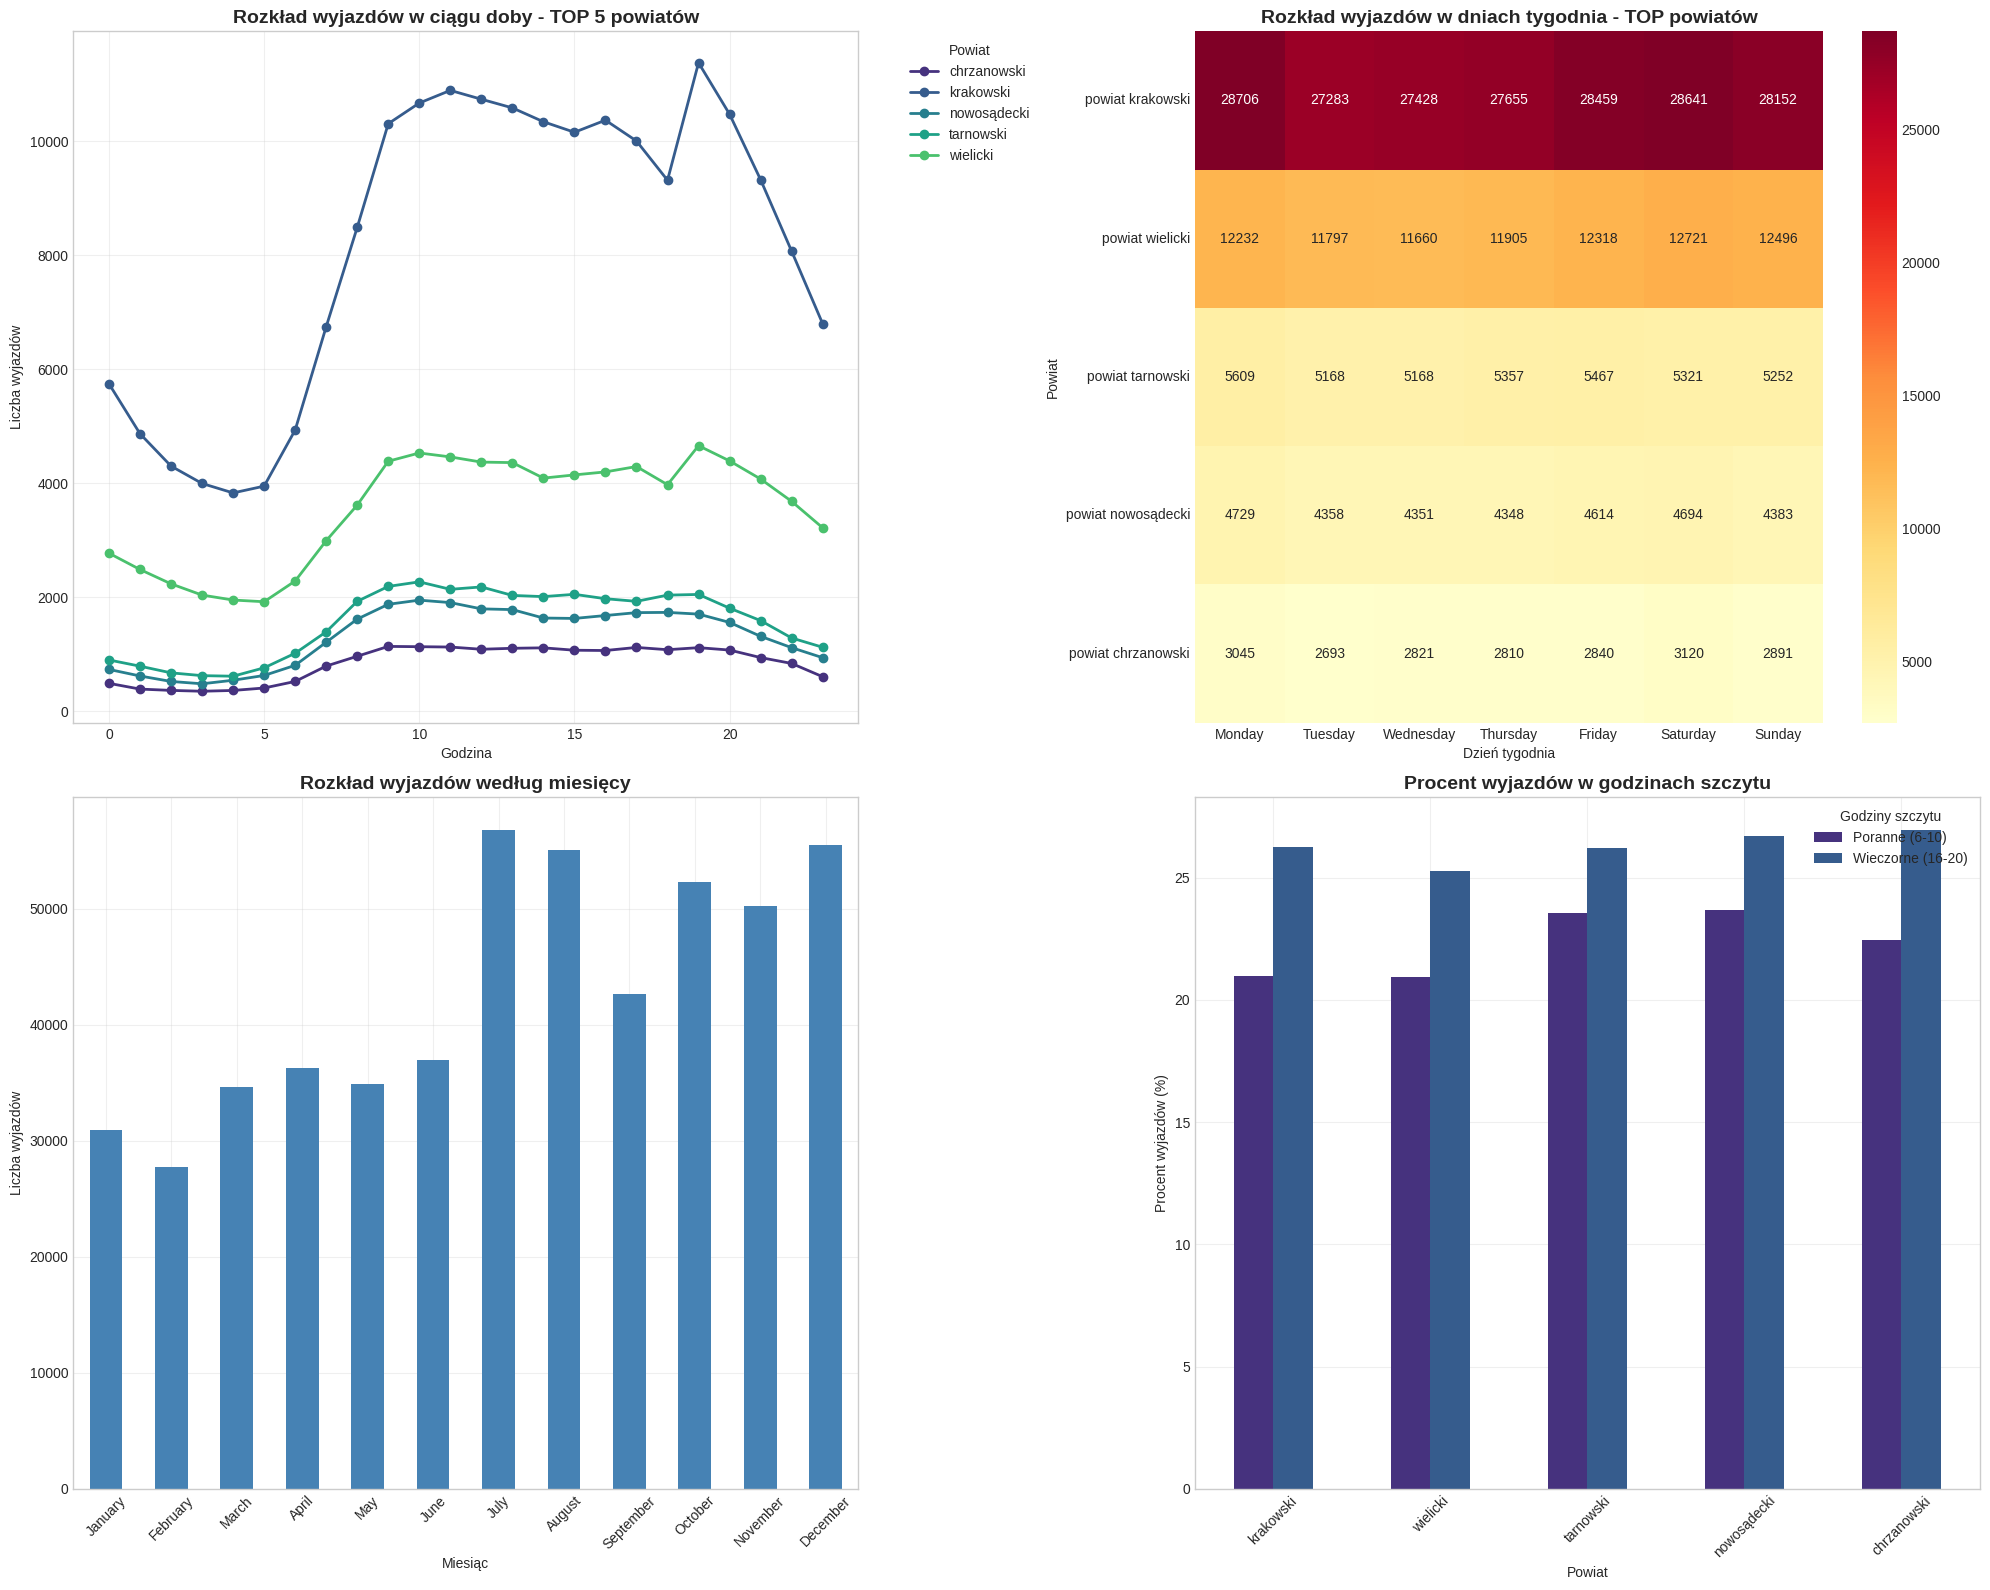


Statystyki czasowe:
📅 Okres analizy: 2021-01-01 - 2023-12-31
⏰ Najczęstsza godzina wyjazdów: 19:00
📊 Najczęstszy dzień tygodnia: Saturday


In [119]:
analyze_temporal_patterns(joined_gdf)


ANALIZA KODÓW PILNOŚCI WEDŁUG POWIATÓW
Używam kolumny: Kod pilności


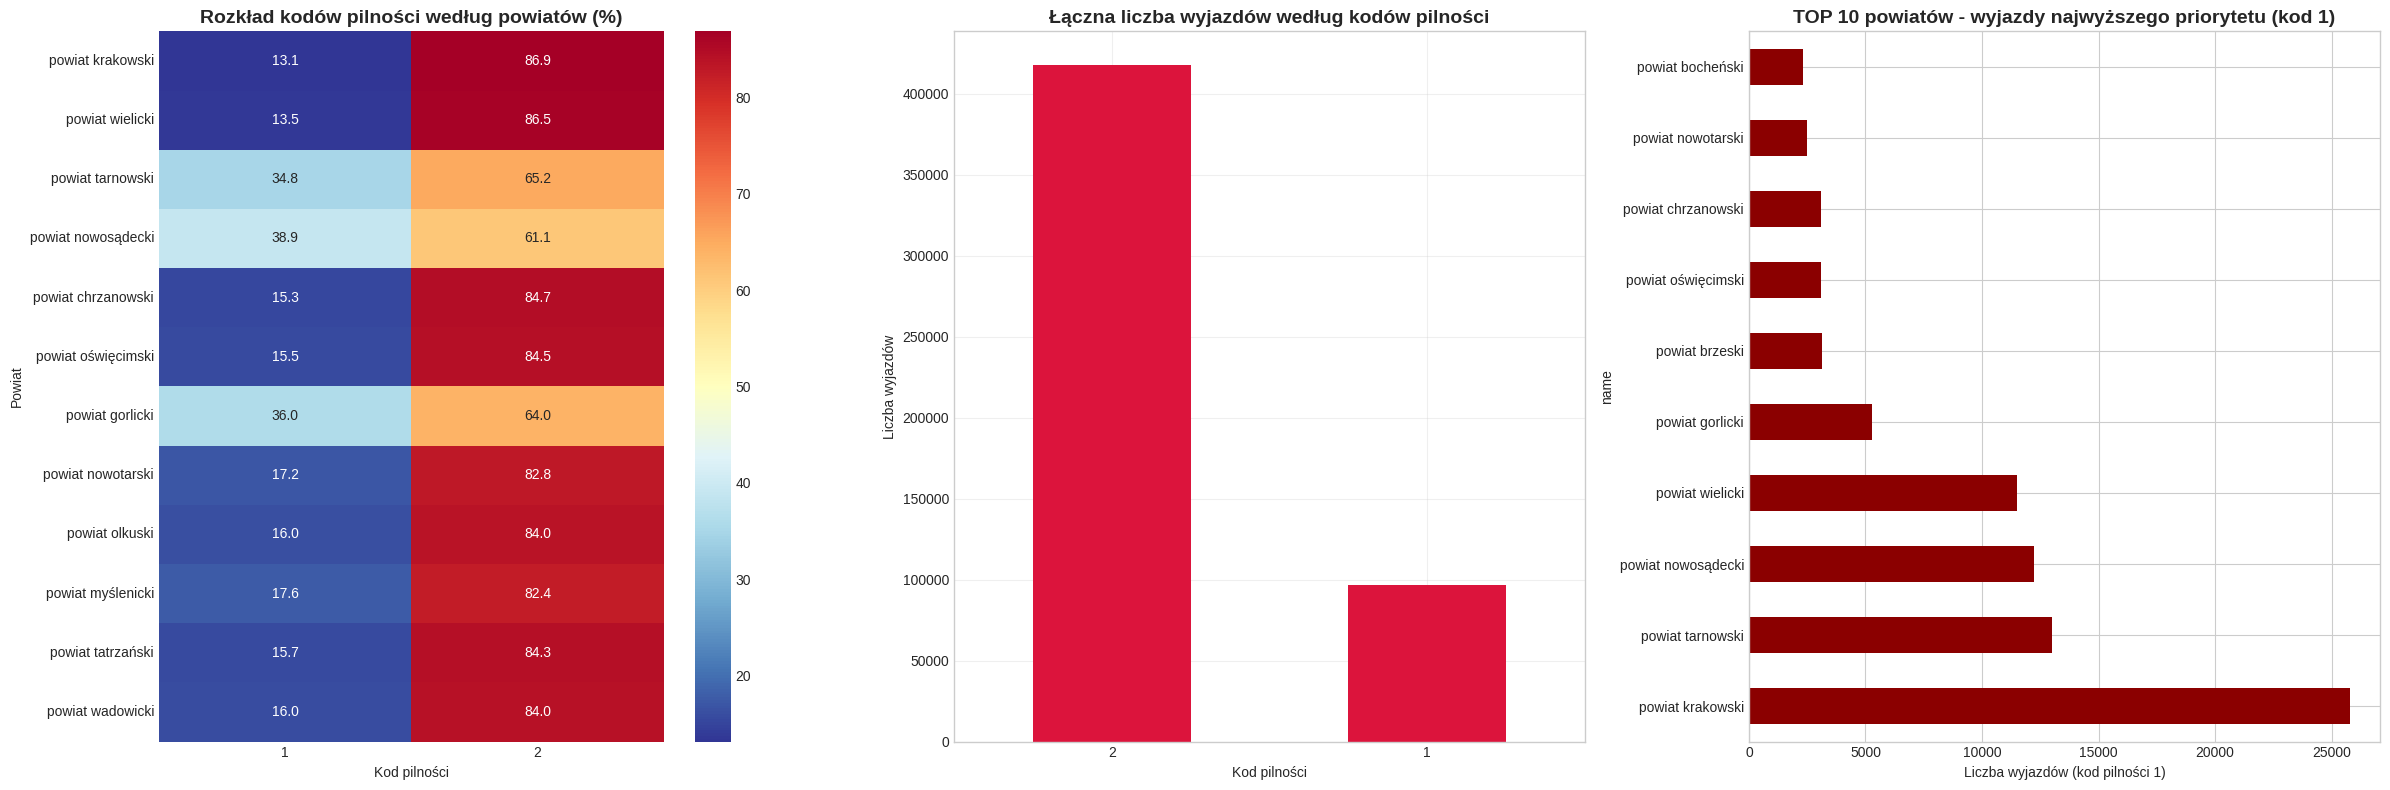


Statystyki kodów pilności:
Kod 1: 96,541 wyjazdów (18.8%)
Kod 2: 417,566 wyjazdów (81.2%)


In [120]:
analyze_priority_by_county(joined_gdf)


ANALIZA POWODÓW WEZWAŃ WEDŁUG POWIATÓW
Używam kolumny: Powód wezwania

TOP 10 powodów wezwań w województwie:
 1. Duszność                                           -  72315 ( 14.1%)
 2. Urazy/obrażenia                                    -  57788 ( 11.2%)
 3. Zasłabnięcie                                       -  50008 (  9.7%)
 4. Problemy kardiologiczne                            -  42464 (  8.3%)
 5. Inne / złe samopoczucie                            -  39761 (  7.7%)
 6. Ból brzucha                                        -  35200 (  6.8%)
 7. Ból w klatce piersiowej                            -  34572 (  6.7%)
 8. Zaburzenia psychiczne                              -  29337 (  5.7%)
 9. Krwotok, krwawienie                                -  19225 (  3.7%)
10. Drgawki                                            -  18746 (  3.6%)


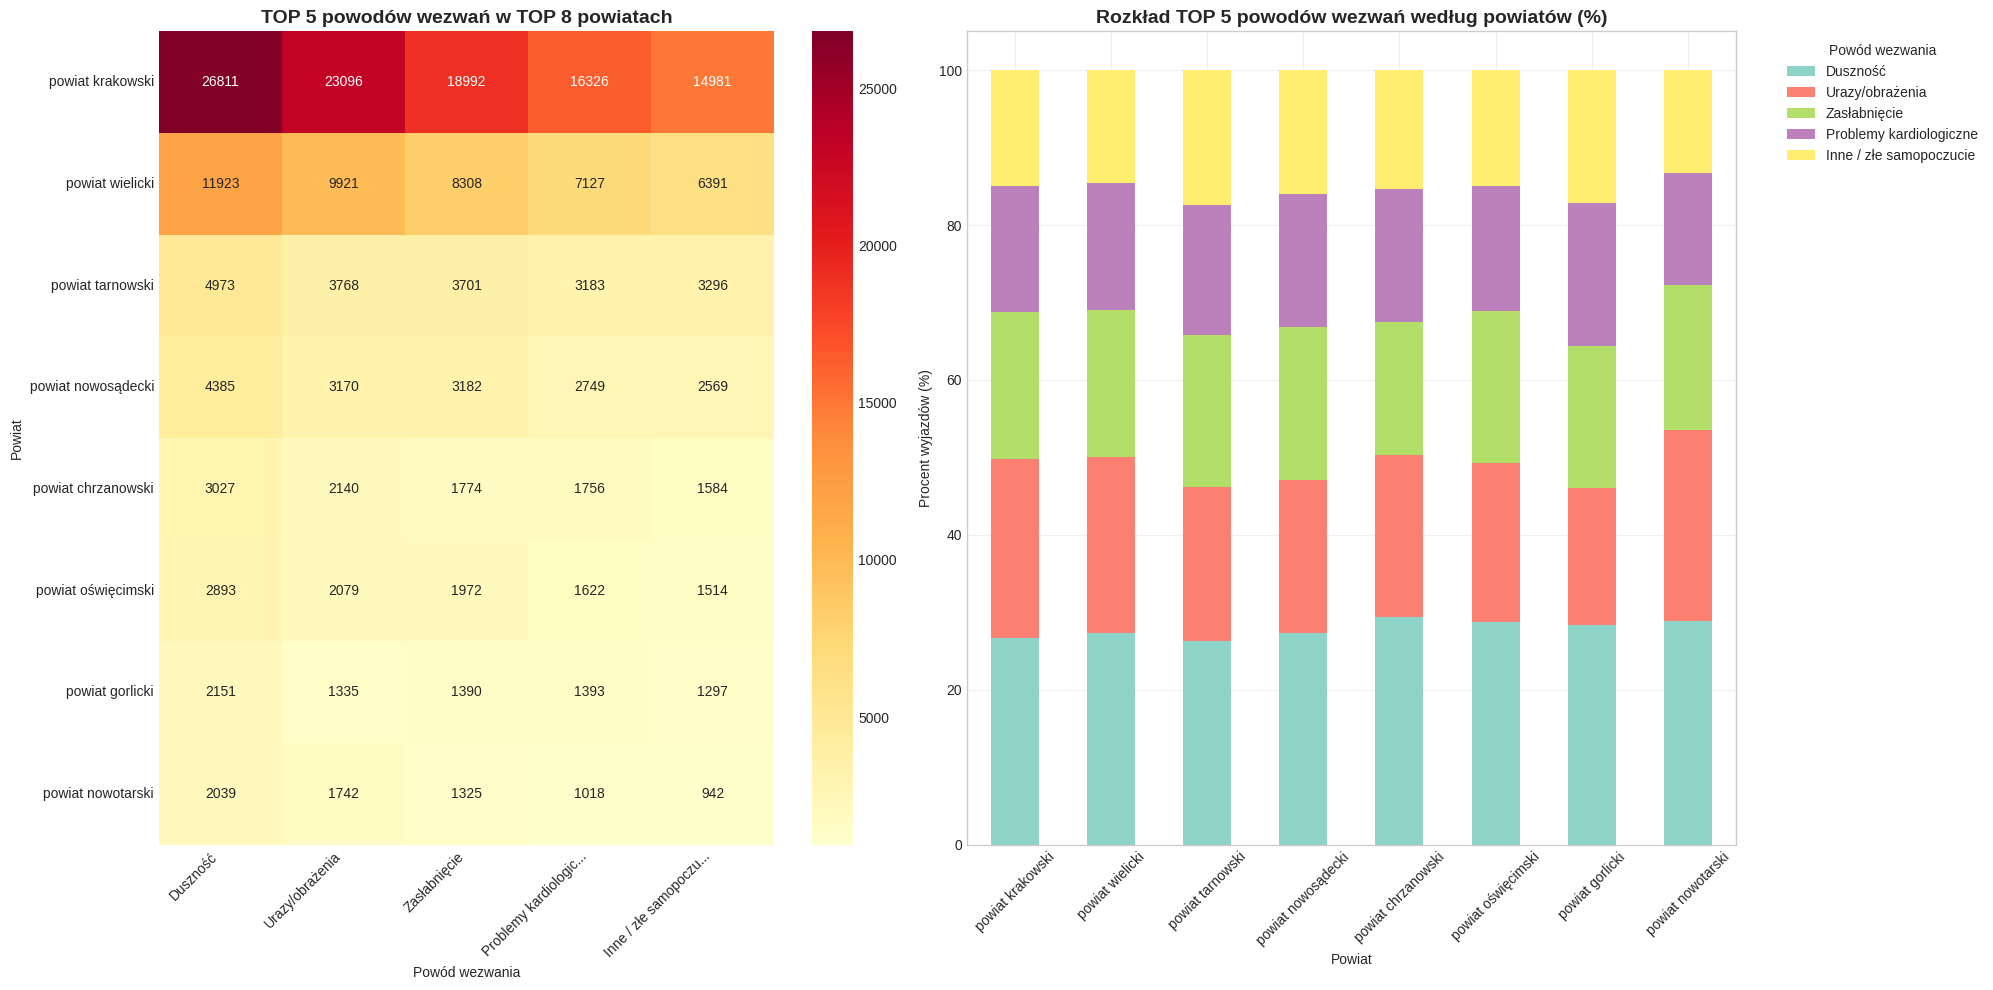

In [122]:
analyze_reasons_by_county(joined_gdf)

ANALIZA WYJAZDÓW KARETEK POGOTOWIA W KRAKOWIE - PODZIAŁ NA DZIELNICE
Rozpoczynam analizę danych karetek w Krakowie...
Wyciągam punkty startu wyjazdów...
Liczba punktów startu: 594255
Punkty w granicach Krakowa: 211494
Pobieram granice dzielnic Krakowa z OpenStreetMap...
Pobieram: Stare Miasto
  ✓ Pobrano: Stare Miasto
Pobieram: Grzegórzki
  ✓ Pobrano: Grzegórzki
Pobieram: Prądnik Czerwony
  ✓ Pobrano: Prądnik Czerwony
Pobieram: Prądnik Biały
  ✓ Pobrano: Prądnik Biały
Pobieram: Krowodrza
  ✓ Pobrano: Krowodrza
Pobieram: Bronowice
  ✓ Pobrano: Bronowice
Pobieram: Zwierzyniec
  ✓ Pobrano: Zwierzyniec
Pobieram: Dębniki
  ✓ Pobrano: Dębniki
Pobieram: Łagiewniki-Borek Fałęcki
  ✓ Pobrano: Łagiewniki-Borek Fałęcki
Pobieram: Swoszowice
  ✓ Pobrano: Swoszowice
Pobieram: Podgórze Duchackie
  ✓ Pobrano: Podgórze Duchackie
Pobieram: Bieżanów-Prokocim
  ✓ Pobrano: Bieżanów-Prokocim
Pobieram: Podgórze
  ✓ Pobrano: Podgórze
Pobieram: Czyżyny
  ✓ Pobrano: Czyżyny
Pobieram: Mistrzejowice
  ✓ Pobrano: 

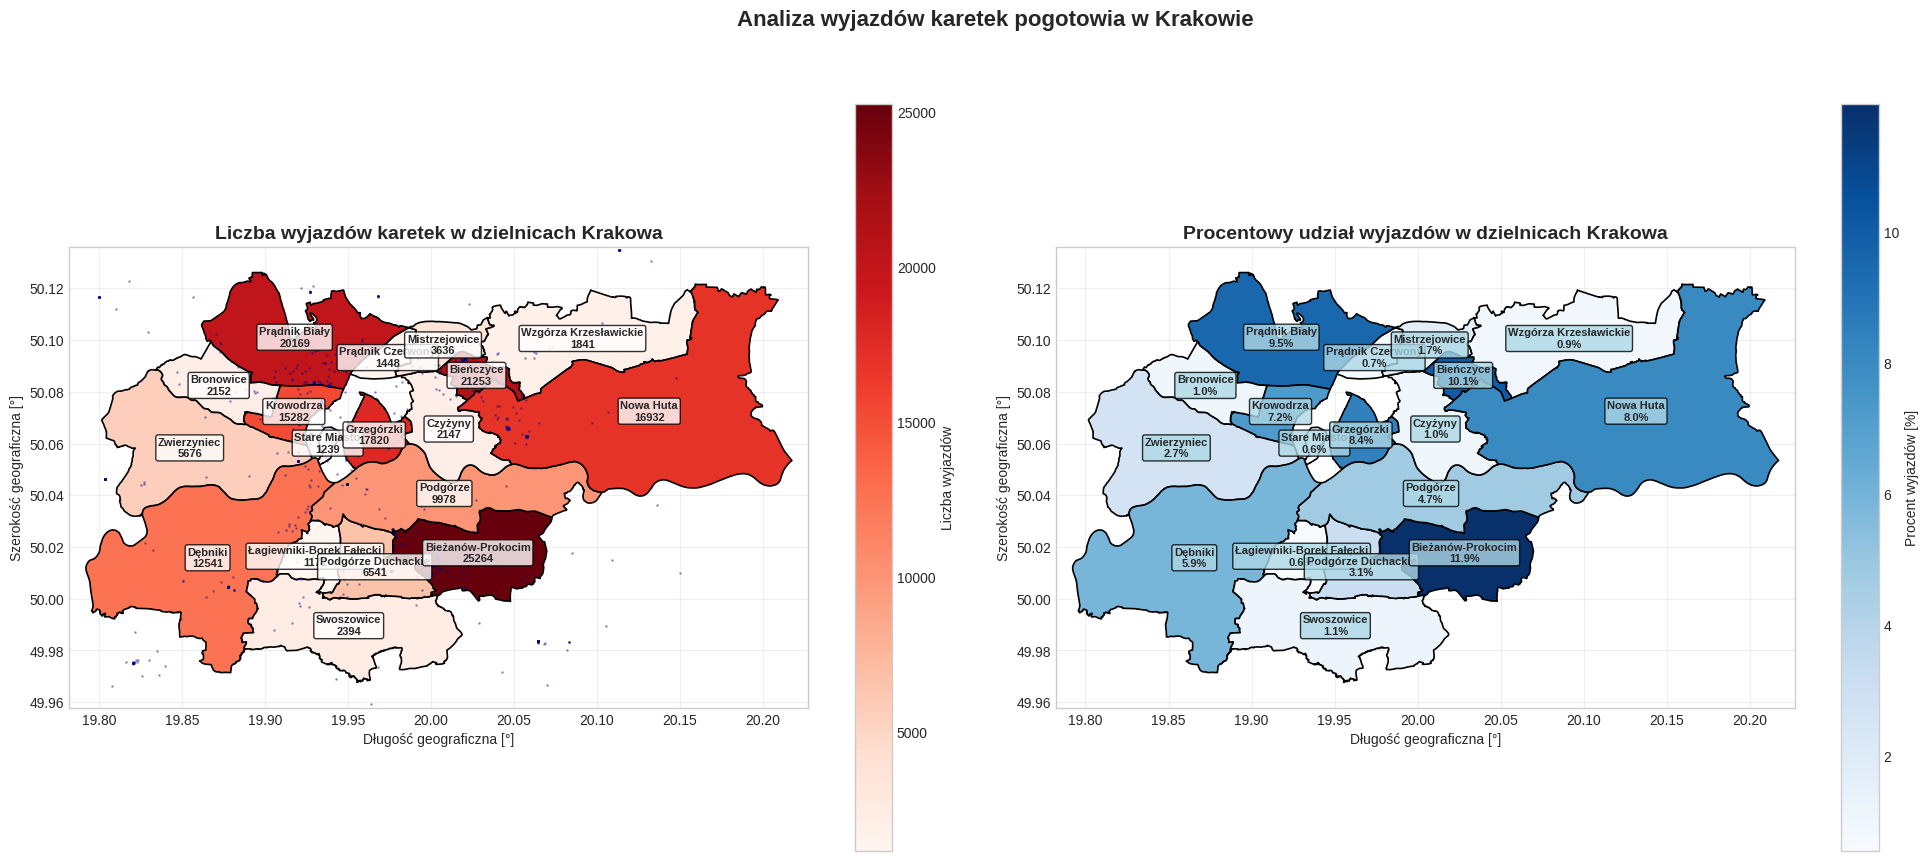


DODATKOWE ANALIZY


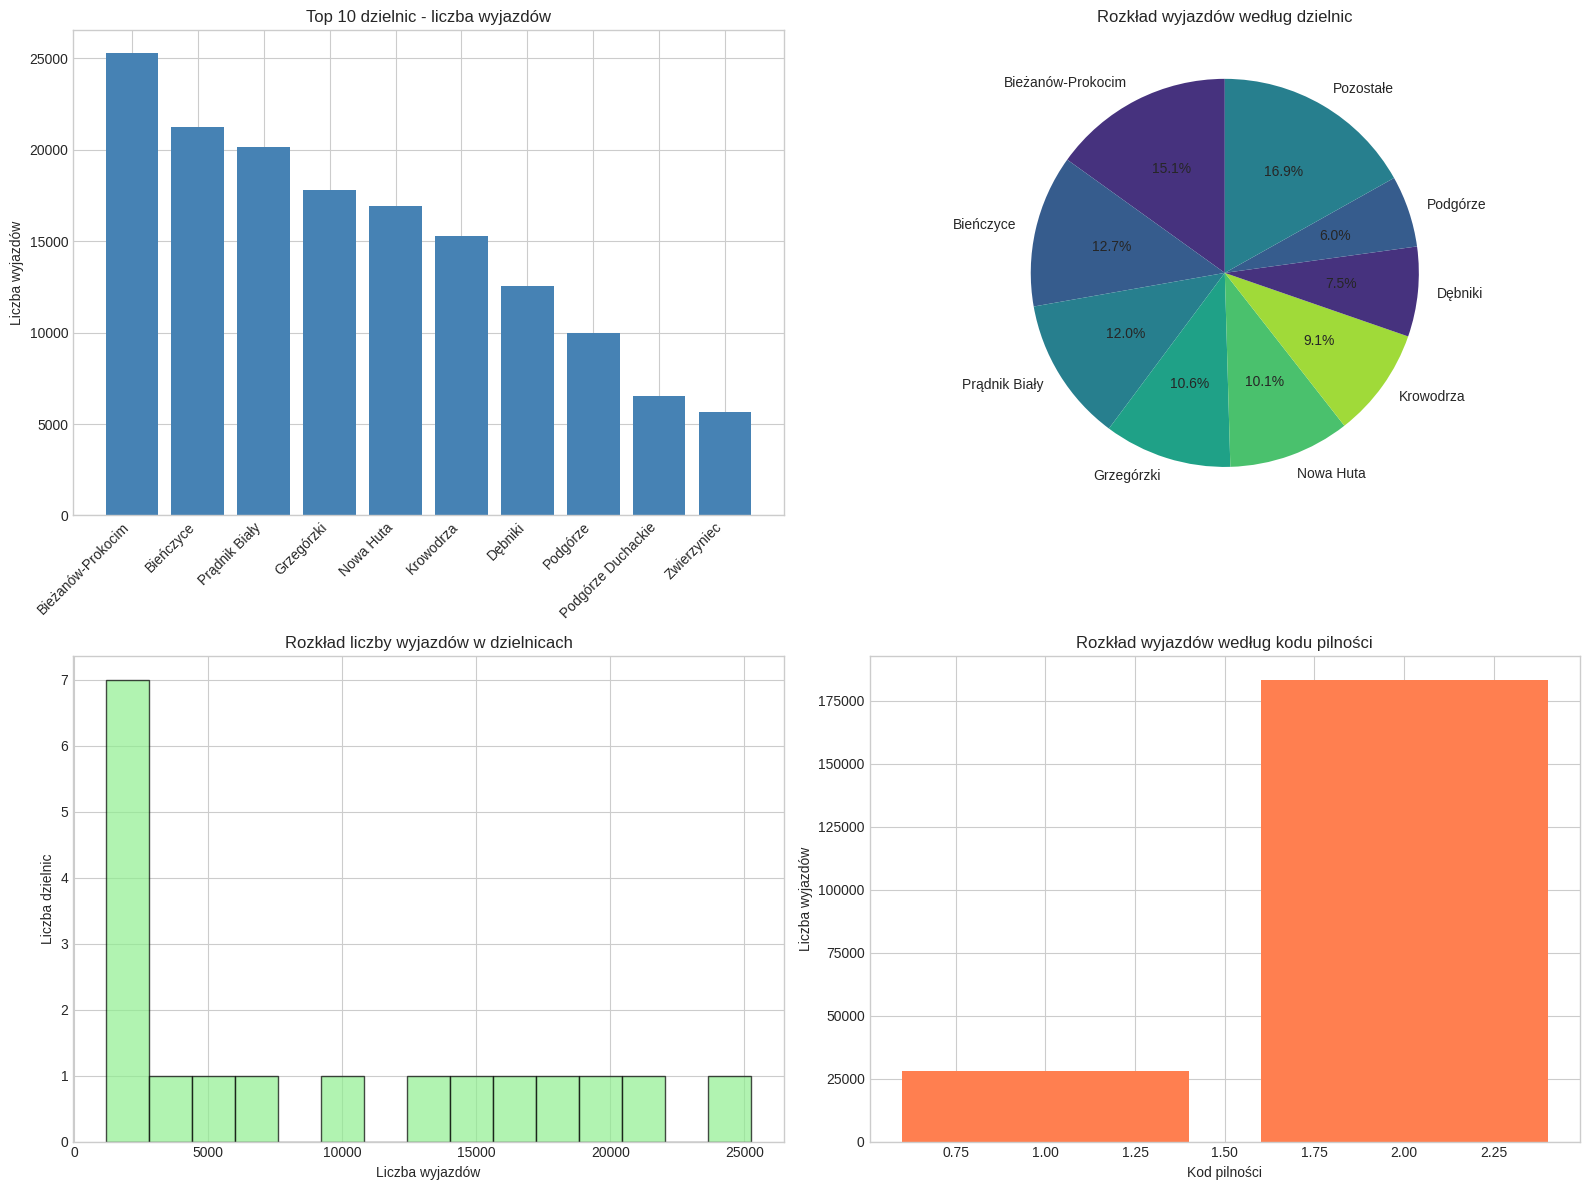


RANKING DZIELNIC KRAKOWA WEDŁUG LICZBY WYJAZDÓW KARETEK
 1. Bieżanów-Prokocim              - 25264 wyjazdów ( 11.9%)
 2. Bieńczyce                      - 21253 wyjazdów ( 10.1%)
 3. Prądnik Biały                  - 20169 wyjazdów (  9.5%)
 4. Grzegórzki                     - 17820 wyjazdów (  8.4%)
 5. Nowa Huta                      - 16932 wyjazdów (  8.0%)
 6. Krowodrza                      - 15282 wyjazdów (  7.2%)
 7. Dębniki                        - 12541 wyjazdów (  5.9%)
 8. Podgórze                       -  9978 wyjazdów (  4.7%)
 9. Podgórze Duchackie             -  6541 wyjazdów (  3.1%)
10. Zwierzyniec                    -  5676 wyjazdów (  2.7%)
11. Mistrzejowice                  -  3636 wyjazdów (  1.7%)
12. Swoszowice                     -  2394 wyjazdów (  1.1%)
13. Bronowice                      -  2152 wyjazdów (  1.0%)
14. Czyżyny                        -  2147 wyjazdów (  1.0%)
15. Wzgórza Krzesławickie          -  1841 wyjazdów (  0.9%)
16. Prądnik Czerwony        

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import geopandas as gpd
from shapely.geometry import Point, Polygon
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

# Instalacja OSMnx jeśli nie jest zainstalowane
try:
    import osmnx as ox
except ImportError:
    print("Instaluję OSMnx...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'osmnx'])
    import osmnx as ox

def get_krakow_districts():
    """
    Pobiera granice dzielnic Krakowa z OpenStreetMap
    """
    print("Pobieram granice dzielnic Krakowa z OpenStreetMap...")
    try:
        # Lista dzielnic Krakowa
        dzielnice_names = [
            "Stare Miasto",
            "Grzegórzki",
            "Prądnik Czerwony",
            "Prądnik Biały",
            "Krowodrza",
            "Bronowice",
            "Zwierzyniec",
            "Dębniki",
            "Łagiewniki-Borek Fałęcki",
            "Swoszowice",
            "Podgórze Duchackie",
            "Bieżanów-Prokocim",
            "Podgórze",
            "Czyżyny",
            "Mistrzejowice",
            "Bieńczyce",
            "Wzgórza Krzesławickie",
            "Nowa Huta"
        ]
        
        districts_list = []
        for dzielnica_name in dzielnice_names:
            try:
                print(f"Pobieram: {dzielnica_name}")
                # Różne warianty nazw dla lepszego dopasowania
                search_queries = [
                    f"{dzielnica_name}, Kraków, Poland",
                    f"Dzielnica {dzielnica_name}, Kraków, Poland",
                    f"{dzielnica_name}, Krakow, Poland"
                ]
                
                district_gdf = None
                for query in search_queries:
                    try:
                        district_gdf = ox.geocode_to_gdf(query, which_result=1)
                        if district_gdf is not None and not district_gdf.empty:
                            break
                    except:
                        continue
                
                if district_gdf is not None and not district_gdf.empty:
                    district_gdf['name'] = dzielnica_name
                    districts_list.append(district_gdf)
                    print(f"  ✓ Pobrano: {dzielnica_name}")
                else:
                    print(f"  ✗ Nie znaleziono: {dzielnica_name}")
                    
            except Exception as e:
                print(f"  ✗ Błąd dla {dzielnica_name}: {e}")
                continue
        
        if districts_list:
            # Połącz wszystkie dzielnice
            districts_gdf = pd.concat(districts_list, ignore_index=True)
            districts_gdf = districts_gdf.to_crs('EPSG:4326')  # WGS84
            print(f"Pobrano {len(districts_gdf)} dzielnic")
            return districts_gdf
        else:
            print("Nie udało się pobrać żadnych dzielnic!")
            return None
            
    except Exception as e:
        print(f"Błąd pobierania danych: {e}")
        return None

def create_sample_districts_backup():
    """
    Backup - tworzy uproszczone granice dzielnic Krakowa
    """
    print("Używam backup - uproszczone granice dzielnic Krakowa...")
    
    # Dzielnice Krakowa z przybliżonymi współrzędnymi centrum
    districts_data = [
        {'name': 'Stare Miasto', 'center': (19.9365, 50.0647), 'size': 0.02},
        {'name': 'Grzegórzki', 'center': (19.9600, 50.0700), 'size': 0.025},
        {'name': 'Prądnik Czerwony', 'center': (19.9200, 50.0900), 'size': 0.035},
        {'name': 'Prądnik Biały', 'center': (19.9000, 50.1000), 'size': 0.030},
        {'name': 'Krowodrza', 'center': (19.9100, 50.0800), 'size': 0.025},
        {'name': 'Bronowice', 'center': (19.8700, 50.0800), 'size': 0.030},
        {'name': 'Zwierzyniec', 'center': (19.9000, 50.0500), 'size': 0.025},
        {'name': 'Dębniki', 'center': (19.9200, 50.0400), 'size': 0.030},
        {'name': 'Łagiewniki-Borek Fałęcki', 'center': (19.8900, 50.0200), 'size': 0.035},
        {'name': 'Swoszowice', 'center': (19.9100, 50.0100), 'size': 0.025},
        {'name': 'Podgórze Duchackie', 'center': (19.9400, 50.0200), 'size': 0.030},
        {'name': 'Bieżanów-Prokocim', 'center': (19.9700, 50.0100), 'size': 0.035},
        {'name': 'Podgórze', 'center': (19.9500, 50.0500), 'size': 0.025},
        {'name': 'Czyżyny', 'center': (19.9800, 50.0800), 'size': 0.025},
        {'name': 'Mistrzejowice', 'center': (20.0000, 50.0900), 'size': 0.030},
        {'name': 'Bieńczyce', 'center': (20.0200, 50.0800), 'size': 0.025},
        {'name': 'Wzgórza Krzesławickie', 'center': (20.0300, 50.1000), 'size': 0.035},
        {'name': 'Nowa Huta', 'center': (20.0400, 50.0700), 'size': 0.040}
    ]
    
    districts = []
    for district in districts_data:
        lon, lat = district['center']
        size = district['size']
        
        # Utwórz prostokątny polygon wokół centrum
        polygon = Polygon([
            (lon - size/2, lat - size/2),
            (lon + size/2, lat - size/2),
            (lon + size/2, lat + size/2),
            (lon - size/2, lat + size/2),
            (lon - size/2, lat - size/2)
        ])
        
        districts.append({
            'name': district['name'],
            'geometry': polygon
        })
    
    return gpd.GeoDataFrame(districts, crs='EPSG:4326')

def analyze_krakow_ambulance_data(gdf):
    """
    Analizuje dane wyjazdów karetek w Krakowie z podziałem na dzielnice
    """
    print("Rozpoczynam analizę danych karetek w Krakowie...")
    
    # Wyciągnij punkty startu z geometrii LINESTRING
    print("Wyciągam punkty startu wyjazdów...")
    start_points = []
    valid_indices = []
    
    for idx, geom in gdf.geometry.items():
        try:
            if geom and hasattr(geom, 'coords') and len(geom.coords) > 0:
                start_point = Point(geom.coords[0])
                start_points.append(start_point)
                valid_indices.append(idx)
        except:
            continue
    
    if not start_points:
        print("Błąd: Nie udało się wyciągnąć punktów startu!")
        return None
    
    # Utwórz GeoDataFrame z punktami startu
    start_gdf = gpd.GeoDataFrame(
        gdf.loc[valid_indices][['wyjazd_id', 'Powód wezwania', 'Kod pilności']].copy(),
        geometry=start_points,
        crs=gdf.crs
    )
    
    print(f"Liczba punktów startu: {len(start_gdf)}")
    
    # Filtruj punkty w granicach Krakowa (bardziej precyzyjne granice)
    krakow_bounds = {
        'min_lon': 19.80, 'max_lon': 20.15,
        'min_lat': 49.95, 'max_lat': 50.15
    }
    
    mask = (
        (start_gdf.geometry.x >= krakow_bounds['min_lon']) &
        (start_gdf.geometry.x <= krakow_bounds['max_lon']) &
        (start_gdf.geometry.y >= krakow_bounds['min_lat']) &
        (start_gdf.geometry.y <= krakow_bounds['max_lat'])
    )
    
    start_gdf_filtered = start_gdf[mask].copy()
    print(f"Punkty w granicach Krakowa: {len(start_gdf_filtered)}")
    
    if len(start_gdf_filtered) == 0:
        print("Brak punktów w granicach Krakowa!")
        return None
    
    # Pobierz granice dzielnic
    districts_gdf = get_krakow_districts()
    if districts_gdf is None:
        print("Próbuję z backup...")
        districts_gdf = create_sample_districts_backup()
    
    if districts_gdf is None or len(districts_gdf) == 0:
        print("Błąd: Nie udało się pobrać granic dzielnic!")
        return None
    
    print(f"Liczba dzielnic: {len(districts_gdf)}")
    
    # Upewnij się, że oba GeoDataFrame mają ten sam CRS
    if start_gdf_filtered.crs != districts_gdf.crs:
        start_gdf_filtered = start_gdf_filtered.to_crs(districts_gdf.crs)
    
    # Wykonaj spatial join
    print("Przypisuję wyjazdy do dzielnic...")
    try:
        joined = gpd.sjoin(start_gdf_filtered, districts_gdf, how='left', predicate='within')
        
        # Policz wyjazdy dla każdej dzielnicy
        district_counts = joined.groupby('name').size().reset_index(name='liczba_wyjazdow')
        
        # Połącz z geometriami dzielnic
        districts_with_counts = districts_gdf.merge(district_counts, on='name', how='left')
        districts_with_counts['liczba_wyjazdow'] = districts_with_counts['liczba_wyjazdow'].fillna(0)
        
        # Oblicz dodatkowe statystyki
        total_points = len(start_gdf_filtered)
        districts_with_counts['procent_wyjazdow'] = (districts_with_counts['liczba_wyjazdow'] / total_points * 100).round(2)
        
        # Analiza według kodu pilności
        if 'Kod pilności' in joined.columns:
            priority_analysis = joined.groupby(['name', 'Kod pilności']).size().unstack(fill_value=0)
            print("\nAnaliza według kodu pilności:")
            print(priority_analysis)
        
        print("\nStatystyki wyjazdów według dzielnic Krakowa:")
        print("-" * 60)
        for _, row in districts_with_counts.sort_values('liczba_wyjazdow', ascending=False).iterrows():
            if row['liczba_wyjazdow'] > 0:
                print(f"{row['name']:30}: {int(row['liczba_wyjazdow']):6} wyjazdów ({row['procent_wyjazdow']:5.1f}%)")
        
        # Stwórz mapę
        print(f"\nTworzę mapę Krakowa...")
        create_krakow_choropleth_map(districts_with_counts, start_gdf_filtered)
        
        # Dodatkowe analizy
        create_additional_analysis(districts_with_counts, joined)
        
        return districts_with_counts, start_gdf_filtered
    
    except Exception as e:
        print(f"Błąd podczas spatial join: {e}")
        return None

def create_krakow_choropleth_map(districts_gdf, points_gdf):
    """
    Tworzy mapę choropletową z liczbą wyjazdów według dzielnic Krakowa
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
    
    # Sprawdź czy są dane do wizualizacji
    max_count = districts_gdf['liczba_wyjazdow'].max()
    if max_count == 0:
        print("Brak danych do wizualizacji!")
        return
    
    print(f"Maksymalna liczba wyjazdów w dzielnicy: {int(max_count)}")
    
    # MAPA 1: Liczba wyjazdów
    cmap = plt.cm.Reds
    norm = mcolors.Normalize(vmin=0, vmax=max_count)
    
    # Rysuj dzielnice z kolorami według liczby wyjazdów
    districts_gdf.plot(
        column='liczba_wyjazdow',
        cmap=cmap,
        linewidth=1.2,
        ax=ax1,
        edgecolor='black',
        legend=True,
        legend_kwds={
            'label': "Liczba wyjazdów",
            'orientation': "vertical",
            'shrink': 0.8
        }
    )
    
    # Dodaj próbkę punktów wyjazdów
    if len(points_gdf) > 1000:
        sample_points = points_gdf.sample(n=1000, random_state=42)
        alpha, size = 0.3, 1
    else:
        sample_points = points_gdf
        alpha, size = 0.5, 1.5
    
    sample_points.plot(ax=ax1, color='darkblue', alpha=alpha, markersize=size)
    
    # Dodaj etykiety dzielnic
    for idx, row in districts_gdf.iterrows():
        if row['geometry'] and not row['geometry'].is_empty and row['liczba_wyjazdow'] > 0:
            try:
                centroid = row['geometry'].centroid
                ax1.annotate(
                    f"{row['name']}\n{int(row['liczba_wyjazdow'])}",
                    xy=(centroid.x, centroid.y),
                    ha='center', va='center',
                    fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='white', alpha=0.8)
                )
            except:
                continue
    
    ax1.set_title('Liczba wyjazdów karetek w dzielnicach Krakowa', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    
    # MAPA 2: Procent wyjazdów
    districts_gdf.plot(
        column='procent_wyjazdow',
        cmap=plt.cm.Blues,
        linewidth=1.2,
        ax=ax2,
        edgecolor='black',
        legend=True,
        legend_kwds={
            'label': "Procent wyjazdów [%]",
            'orientation': "vertical",
            'shrink': 0.8
        }
    )
    
    # Dodaj etykiety z procentami
    for idx, row in districts_gdf.iterrows():
        if row['geometry'] and not row['geometry'].is_empty and row['procent_wyjazdow'] > 0:
            try:
                centroid = row['geometry'].centroid
                ax2.annotate(
                    f"{row['name']}\n{row['procent_wyjazdow']:.1f}%",
                    xy=(centroid.x, centroid.y),
                    ha='center', va='center',
                    fontsize=8, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.2", facecolor='lightblue', alpha=0.8)
                )
            except:
                continue
    
    ax2.set_title('Procentowy udział wyjazdów w dzielnicach Krakowa', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    # Ustawienia wspólne
    for ax in [ax1, ax2]:
        bounds = districts_gdf.total_bounds
        margin = 0.01
        ax.set_xlim(bounds[0] - margin, bounds[2] + margin)
        ax.set_ylim(bounds[1] - margin, bounds[3] + margin)
        ax.set_xlabel('Długość geograficzna [°]')
        ax.set_ylabel('Szerokość geograficzna [°]')
    
    plt.suptitle('Analiza wyjazdów karetek pogotowia w Krakowie', fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()

def create_additional_analysis(districts_gdf, joined_gdf):
    """
    Tworzy dodatkowe analizy i wykresy
    """
    print("\n" + "="*60)
    print("DODATKOWE ANALIZY")
    print("="*60)
    
    # 1. Ranking dzielnic
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Wykres słupkowy - top 10 dzielnic
    top_districts = districts_gdf.nlargest(10, 'liczba_wyjazdow')
    ax1.bar(range(len(top_districts)), top_districts['liczba_wyjazdow'], color='steelblue')
    ax1.set_xticks(range(len(top_districts)))
    ax1.set_xticklabels(top_districts['name'], rotation=45, ha='right')
    ax1.set_title('Top 10 dzielnic - liczba wyjazdów')
    ax1.set_ylabel('Liczba wyjazdów')
    
    # Wykres kołowy - top 8 dzielnic
    top8 = districts_gdf.nlargest(8, 'liczba_wyjazdow')
    other_sum = districts_gdf.nsmallest(len(districts_gdf)-8, 'liczba_wyjazdow')['liczba_wyjazdow'].sum()
    labels = list(top8['name']) + ['Pozostałe']
    sizes = list(top8['liczba_wyjazdow']) + [other_sum]
    ax2.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
    ax2.set_title('Rozkład wyjazdów według dzielnic')
    
    # Histogram liczby wyjazdów
    ax3.hist(districts_gdf['liczba_wyjazdow'], bins=15, color='lightgreen', alpha=0.7, edgecolor='black')
    ax3.set_title('Rozkład liczby wyjazdów w dzielnicach')
    ax3.set_xlabel('Liczba wyjazdów')
    ax3.set_ylabel('Liczba dzielnic')
    
    # Analiza według kodu pilności (jeśli dostępne)
    if 'Kod pilności' in joined_gdf.columns:
        priority_counts = joined_gdf['Kod pilności'].value_counts()
        ax4.bar(priority_counts.index, priority_counts.values, color='coral')
        ax4.set_title('Rozkład wyjazdów według kodu pilności')
        ax4.set_xlabel('Kod pilności')
        ax4.set_ylabel('Liczba wyjazdów')
    else:
        ax4.text(0.5, 0.5, 'Brak danych o kodzie pilności', ha='center', va='center', transform=ax4.transAxes)
        ax4.set_title('Kod pilności - brak danych')
    
    plt.tight_layout()
    plt.show()
    
    # Wyświetl ranking
    print("\n" + "="*70)
    print("RANKING DZIELNIC KRAKOWA WEDŁUG LICZBY WYJAZDÓW KARETEK")
    print("="*70)
    ranking = districts_gdf.sort_values('liczba_wyjazdow', ascending=False)
    for i, (_, row) in enumerate(ranking.iterrows(), 1):
        if row['liczba_wyjazdow'] > 0:
            print(f"{i:2d}. {row['name']:30} - {int(row['liczba_wyjazdow']):5} wyjazdów ({row['procent_wyjazdow']:5.1f}%)")

# Uruchom analizę dla Krakowa
print("="*70)
print("ANALIZA WYJAZDÓW KARETEK POGOTOWIA W KRAKOWIE - PODZIAŁ NA DZIELNICE")
print("="*70)

gdf = gpd.read_parquet(file_path)

if 'gdf' in locals():
    results = analyze_krakow_ambulance_data(gdf)
    if results:
        districts_with_counts, filtered_points = results
        print(f"\n" + "="*50)
        print("PODSUMOWANIE ANALIZY KRAKOWA")
        print("="*50)
        print(f"🚑 Przeanalizowane wyjazdy w Krakowie: {len(filtered_points):,}")
        print(f"🏘️ Liczba dzielnic: {len(districts_with_counts)}")
        print(f"📊 Całkowita liczba wyjazdów: {int(districts_with_counts['liczba_wyjazdow'].sum()):,}")
        print(f"📈 Średnia wyjazdów na dzielnicę: {districts_with_counts['liczba_wyjazdow'].mean():.1f}")
        print(f"📌 Maksymalna liczba wyjazdów: {int(districts_with_counts['liczba_wyjazdow'].max())}")
        
        # Znajdź najbardziej obciążoną dzielnicę
        top_district = districts_with_counts.loc[districts_with_counts['liczba_wyjazdow'].idxmax()]
        print(f"🏆 Dzielnica z największą liczbą wyjaздów: {top_district['name']} ({int(top_district['liczba_wyjazdow'])} wyjazdów)")
else:
    print("❌ BŁĄD: Zmienna 'gdf' nie została znaleziona!")
    print("\n💡 Aby uruchomić analizę, najpierw załaduj dane:")
    print("   gdf = gpd.read_parquet('wynik_caly.parquet')")
    print("   # a następnie uruchom ponownie kod")

Analizuję wzorce czasowe wyjazdów...
Używam backup - uproszczone granice dzielnic Krakowa...


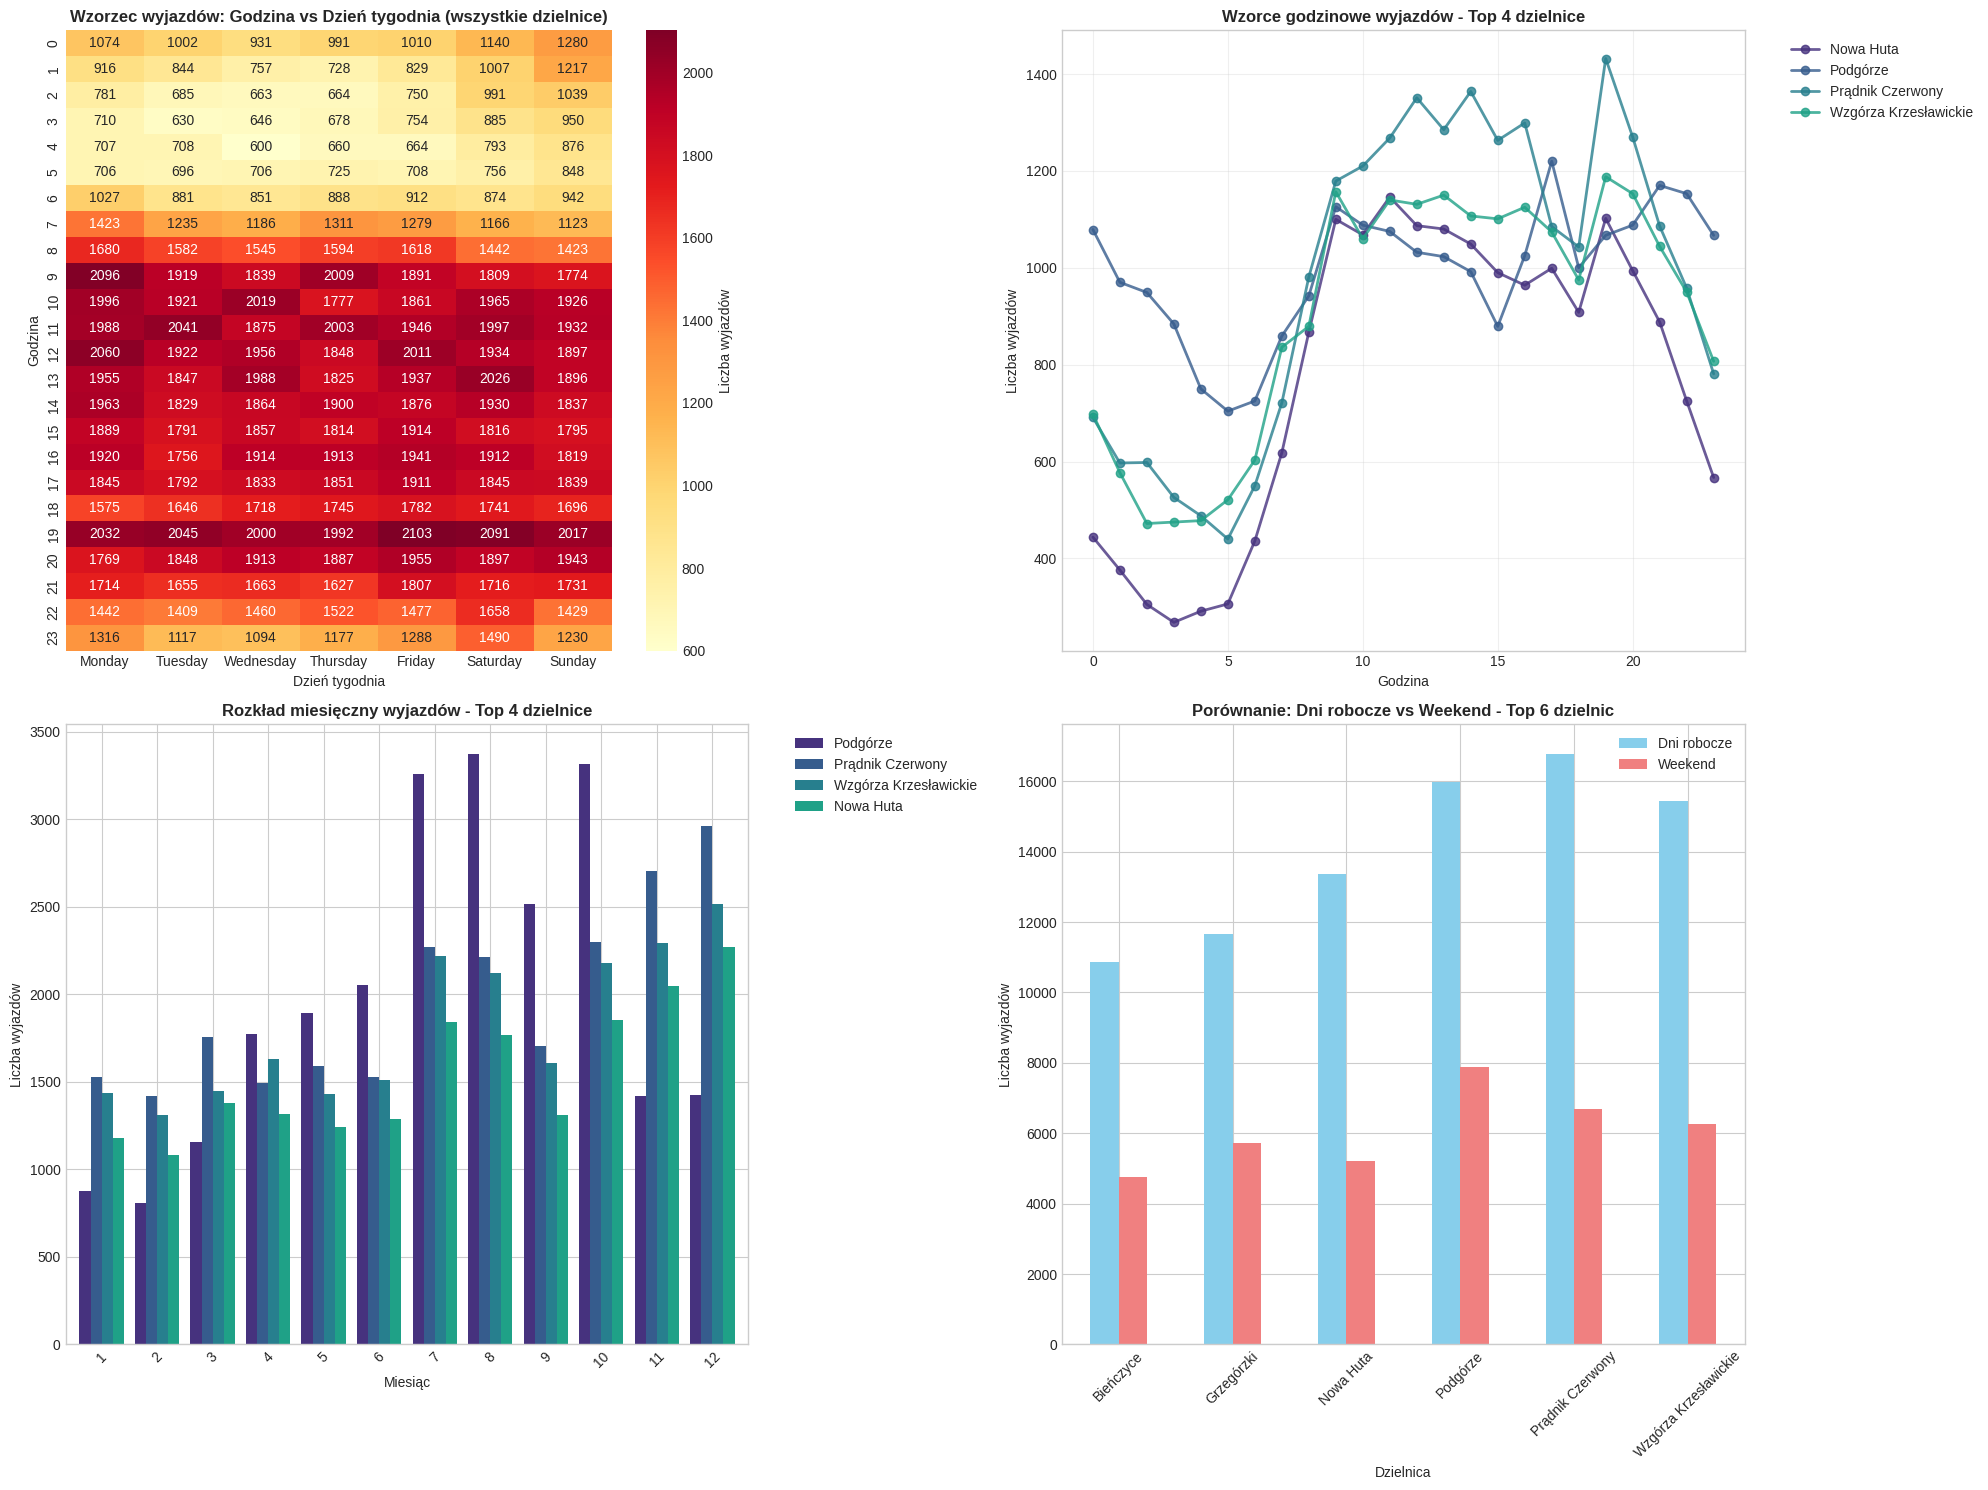


ANALIZA WZORCÓW CZASOWYCH
🕐 Godzina szczytu: 19:00 (14280 wyjazdów)
📅 Dzień z największą liczbą wyjazdów: Saturday (36881 wyjazdów)
📆 Miesiąc z największą liczbą wyjazdów: Grudzień (28265 wyjazdów)


In [30]:
# Analiza czasowa wyjazdów w dzielnicach Krakowa
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pandas as pd

def analyze_temporal_patterns(gdf):
    """
    Analizuje wzorce czasowe wyjazdów w dzielnicach Krakowa
    """
    print("Analizuję wzorce czasowe wyjazdów...")
    
    # Pobierz granice dzielnic używając funkcji z głównego kodu
    districts_gdf = create_sample_districts_backup()
    
    # Filtruj dane dla Krakowa
    krakow_bounds = {
        'min_lon': 19.80, 'max_lon': 20.15,
        'min_lat': 49.95, 'max_lat': 50.15
    }
    
    # Wyciągnij punkty startu
    start_points = []
    valid_indices = []
    for idx, geom in gdf.geometry.items():
        try:
            if geom and hasattr(geom, 'coords') and len(geom.coords) > 0:
                start_point = Point(geom.coords[0])
                start_points.append(start_point)
                valid_indices.append(idx)
        except:
            continue
    
    start_gdf = gpd.GeoDataFrame(
        gdf.loc[valid_indices].copy(),
        geometry=start_points,
        crs=gdf.crs
    )
    
    # Filtruj punkty w granicach Krakowa
    mask = (
        (start_gdf.geometry.x >= krakow_bounds['min_lon']) &
        (start_gdf.geometry.x <= krakow_bounds['max_lon']) &
        (start_gdf.geometry.y >= krakow_bounds['min_lat']) &
        (start_gdf.geometry.y <= krakow_bounds['max_lat'])
    )
    krakow_gdf = start_gdf[mask].copy()
    
    # Przypisz dzielnice
    joined = gpd.sjoin(krakow_gdf, districts_gdf, how='left', predicate='within')
    
    # Konwersja czasu
    joined['Czas wyjazdu ZRM'] = pd.to_datetime(joined['Czas wyjazdu ZRM'])
    joined['hour'] = joined['Czas wyjazdu ZRM'].dt.hour
    joined['day_of_week'] = joined['Czas wyjazdu ZRM'].dt.day_name()
    joined['month'] = joined['Czas wyjazdu ZRM'].dt.month
    joined['year'] = joined['Czas wyjazdu ZRM'].dt.year
    
    # Wykres 1: Heatmapa godzinowa dla top 6 dzielnic
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    
    # Top 6 dzielnic
    top_districts = joined['name'].value_counts().head(6).index
    
    # Heatmapa godzina vs dzień tygodnia
    ax1 = axes[0, 0]
    hourly_data = joined[joined['name'].isin(top_districts)].groupby(['name', 'hour', 'day_of_week']).size().unstack(fill_value=0)
    
    # Średnia dla wszystkich dzielnic
    avg_hourly = joined.groupby(['hour', 'day_of_week']).size().unstack(fill_value=0)
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    avg_hourly = avg_hourly.reindex(columns=days_order, fill_value=0)
    
    sns.heatmap(avg_hourly, annot=True, fmt='d', cmap='YlOrRd', ax=ax1, cbar_kws={'label': 'Liczba wyjazdów'})
    ax1.set_title('Wzorzec wyjazdów: Godzina vs Dzień tygodnia (wszystkie dzielnice)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Dzień tygodnia')
    ax1.set_ylabel('Godzina')
    
    # Wykres 2: Wzorzec godzinowy dla top dzielnic
    ax2 = axes[0, 1]
    hourly_by_district = joined[joined['name'].isin(top_districts[:4])].groupby(['name', 'hour']).size().unstack(fill_value=0).T
    
    for district in hourly_by_district.columns:
        ax2.plot(hourly_by_district.index, hourly_by_district[district], 
                marker='o', linewidth=2, label=district, alpha=0.8)
    
    ax2.set_title('Wzorce godzinowe wyjazdów - Top 4 dzielnice', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Godzina')
    ax2.set_ylabel('Liczba wyjazdów')
    ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    # Wykres 3: Rozkład miesięczny
    ax3 = axes[1, 0]
    monthly_data = joined.groupby(['month', 'name']).size().unstack(fill_value=0)
    monthly_data = monthly_data[top_districts[:4]]
    
    monthly_data.plot(kind='bar', ax=ax3, width=0.8)
    ax3.set_title('Rozkład miesięczny wyjazdów - Top 4 dzielnice', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Miesiąc')
    ax3.set_ylabel('Liczba wyjazdów')
    ax3.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.tick_params(axis='x', rotation=45)
    
    # Wykres 4: Analiza weekend vs dni robocze
    ax4 = axes[1, 1]
    joined['is_weekend'] = joined['day_of_week'].isin(['Saturday', 'Sunday'])
    weekend_data = joined[joined['name'].isin(top_districts[:6])].groupby(['name', 'is_weekend']).size().unstack(fill_value=0)
    weekend_data.columns = ['Dni robocze', 'Weekend']
    
    weekend_data.plot(kind='bar', ax=ax4, color=['skyblue', 'lightcoral'])
    ax4.set_title('Porównanie: Dni robocze vs Weekend - Top 6 dzielnic', fontsize=12, fontweight='bold')
    ax4.set_xlabel('Dzielnica')
    ax4.set_ylabel('Liczba wyjazdów')
    ax4.tick_params(axis='x', rotation=45)
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Statystyki tekstowe
    print("\n" + "="*60)
    print("ANALIZA WZORCÓW CZASOWYCH")
    print("="*60)
    
    # Godzina szczytu
    peak_hour = joined['hour'].value_counts().index[0]
    print(f"🕐 Godzina szczytu: {peak_hour}:00 ({joined['hour'].value_counts().iloc[0]} wyjazdów)")
    
    # Dzień tygodnia z największą liczbą wyjazdów
    peak_day = joined['day_of_week'].value_counts().index[0]
    print(f"📅 Dzień z największą liczbą wyjazdów: {peak_day} ({joined['day_of_week'].value_counts().iloc[0]} wyjazdów)")
    
    # Miesiąc szczytu
    peak_month = joined['month'].value_counts().index[0]
    month_names = {1: 'Styczeń', 2: 'Luty', 3: 'Marzec', 4: 'Kwiecień', 5: 'Maj', 6: 'Czerwiec',
                   7: 'Lipiec', 8: 'Sierpień', 9: 'Wrzesień', 10: 'Październik', 11: 'Listopad', 12: 'Grudzień'}
    print(f"📆 Miesiąc z największą liczbą wyjazdów: {month_names.get(peak_month, peak_month)} ({joined['month'].value_counts().iloc[0]} wyjazdów)")
    
    return joined

# Uruchom analizę
if 'gdf' in locals():
    temporal_data = analyze_temporal_patterns(gdf)
else:
    print("Najpierw załaduj dane: gdf = gpd.read_parquet('wynik_caly.parquet')")